# Classical vs Quantum Plays Nim

**COMP47950 Quantum Machine Learning — Implementation Notebook & Report**

**(1)** Classical ML baselines; **(2)** simulated quantum models (VQC and QSVM as two simulated families); **(3)** inference-only evaluation on IBM Quantum hardware for the selected winners. We compare pipelines on performance, cost, speed, and interpretability.

## 1. Introduction

This project compares **classical** and **quantum** machine learning approaches on the game of **Nim** (normal play, $k = 3$ heaps, max heap size $M = 7$). The ML task is **state $\to$ win/loss classification**: predict whether a board position is **winning or losing** based on the Nim-sum, then use the prediction to select moves via one-step lookahead.

**Workflow:** We compare classical baselines with two simulated quantum model families, then carry selected quantum winners to device inference.

1. Classical ML baselines: SVM, Random Forest, and Logistic Regression on raw and parity-informed features, with no/augmented/canonical symmetry handling.
2. Simulated VQC: variational classifiers over angle, amplitude, and binary feature encodings, sweeping ansatz, depth, CZ strategy, Nim-sum inclusion, and noise robustness.
3. Simulated QSVM: quantum-kernel SVMs over the same encoding family, sweeping kernel settings, symmetry handling, finite-shot estimation, and SVC regularisation.
4. Quantum selection and device inference: select one winner per quantum family using balanced accuracy versus cost, validate readiness, then run inference-only IBM Quantum jobs where feasible.

**Experiment:** Out-of-distribution protocol and training-size ladder are defined in **Section 2.5** (train heaps $M \leq 5$, test with at least one heap $> 5$); we report balanced accuracy, MCC, and win rate vs training size.

**Comparison metrics:** Balanced accuracy and MCC for classification, win rate vs a random policy for game-level utility, learning curves over training size, training and inference cost, shot and circuit budgets, simulated-vs-device deltas, and interpretability. The first code cell sets sweep flags and caching; MLflow stores hyperparameters and run ids.

In [ ]:
from __future__ import annotations

# Standard library
import os
import sys
from pathlib import Path
from typing import Any, cast


# Repository paths
def _resolve_project_src() -> Path:
    """Locate ``src/`` whether the kernel cwd is the repo root or ``notebooks/``."""
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "qml_project").is_dir():
        return cwd / "src"
    if cwd.name == "notebooks" and (cwd.parent / "src" / "qml_project").is_dir():
        return cwd.parent / "src"
    for anchor in cwd.parents:
        if (anchor / "src" / "qml_project").is_dir():
            return anchor / "src"
    raise RuntimeError(
        "Cannot find src/qml_project; run the notebook from the repository "
        "or set the kernel cwd to the repo root or notebooks/."
    )


sys.path.insert(0, str(_resolve_project_src()))

# Numerics, tables, plotting
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

# Section 2: Nim game and data
from qml_project.nim import (
    NimState,
    nim_sum,
    is_winning,
    legal_moves,
    apply_move,
    optimal_move,
    random_policy,
    optimal_policy,
    play_many,
    class_balance_table,
    majority_baseline_accuracy,
    normalise_states,
    all_heap_permutations,
    angle_parameters,
    amplitude_vector,
    augment_s3,
    binary_bits,
    build_encoding_circuit,
    canonical_order,
    count_canonical_states,
    enumerate_states,
    augmentation_stats,
    prepare_experiment_data,
)

# Section 3: classical ML baselines (scikit-learn)
from sklearn.decomposition import PCA

from qml_project import (
    # MLflow experiment name resolution
    resolve_experiment,
    set_mlflow_tracking_uri,
    # Section 3: classical ML baselines
    FeatureSet,
    classical_feature_names,
    classical_posthoc_coefficients_or_importances,
    format_classical_sweep_summary_display,
    format_kernel_aligned_baseline_display,
    learning_curve_mean_std_by_train_size,
    parity_ablation_summary_display,
    plot_classical_sample_efficiency_curves,
    plot_kernel_aligned_baseline_curves,
    plot_parity_feature_ablation_balanced_accuracy,
    prepare_features,
    refit_classical_raw_best_predict_test,
    run_classical_sweep,
    run_parity_feature_ablation_sweep,
    # Section 4: design-space analysis
    plot_architecture_diagnostics_triptych,
    run_architecture_diagnostics_dataframes,
    # Section 5: VQC
    VQC_ENCODINGS,
    build_circuit,
    build_vqc_profile_summary_rows,
    build_vqc_tuning_config_grid,
    plot_vqc_robustness_balanced_accuracy_vs_noise,
    plot_vqc_tuning_curves_by_encoding,
    run_vqc_robustness_snapshot_dataframe,
    run_vqc_tuning_workflow_dataframe,
    vqc_config_grid_preview_dataframe,
    # Section 6: QSVM
    filter_qsvm_summary_exact_statevector,
    plot_qsvm_faceted_metric_curves,
    plot_qsvm_full_train_balanced_accuracy_bars,
    plot_qsvm_train_and_kernel_time_curves,
    qsvm_balanced_accuracy_mean_pivot,
    run_qsvm_tuning_workflow_dataframe,
    summarize_qsvm_workflow_dataframe,
    # Section 7: quantum selection
    add_cost_metric_contract_columns,
    build_pareto_quantum_selection,
    build_quantum_winner_artifacts,
    log_quantum_selection_winners_to_mlflow,
    plot_quantum_selection_pareto,
    plot_quantum_vs_classical_balanced_accuracy_overlay,
    plot_quantum_winner_two_metric_panels,
    # Section 8: pre-device validation
    build_device_cost_estimates_dataframe,
    build_device_readiness_bundle,
    run_device_refit_sweep_and_cache,
    shots_to_target_balanced_accuracy,
    # Section 9: simulated deep-dive
    power_law_fit_from_learning_curve_dataframe,
    # Section 10: device inference
    run_device_inference_result_sweep,
    sum_device_cost_circuits_by_pipeline,
    # Section 11: final comparison
    build_final_three_way_comparison,
    build_paired_heap_only_quantum_workflow_rows,
    select_classical_winner_rows,
    hypothesis_verdict_balanced_accuracy_tables,
    plot_final_comparison_balanced_accuracy,
    summarize_cost_performance,
    # Section 12: interpretability
    quantum_winners_test_predictions_interpretability,
    summarize_interpretability_disagreements,
    # Nim demo app: parquet exports
    export_nim_demo_classical_df,
    export_nim_demo_qsvm_workflow_df,
    export_nim_demo_quantum_selection_parquets,
    export_nim_demo_vqc_workflow_df,
)

# Point MLflow at the project tracking URI once imports are loaded.
set_mlflow_tracking_uri()

SWEEP_WORKERS = min(8, (os.cpu_count() or 1))
USE_CACHE = True

## 2. Nim Game and Data

### 2.1 Game rules

**Nim** (normal play) is a two-player combinatorial game.  The state is a tuple of $k$ heap sizes $(h_1, h_2, \ldots, h_k)$ with $0 \leq h_i \leq M$.  On each turn the current player chooses one non-empty heap $i$ and removes between 1 and $h_i$ stones from it.  The game ends when all heaps are empty; under **normal play** the player who takes the last stone **wins**.

The game is completely solved by the **Nim-sum** — the bitwise XOR of all heap sizes:

$$n = h_1 \oplus h_2 \oplus \cdots \oplus h_k$$

| Nim-sum | Position | Meaning |
|---------|----------|---------|
| $n \neq 0$ | **Winning** | Current player can always force a win by moving to a state with $n = 0$ |
| $n = 0$ | **Losing** | Every legal move leaves $n \neq 0$, giving the opponent a winning position |

**Primary configuration:** $k = 3$ heaps, maximum heap size $M = 7$.  This yields $(M+1)^k - 1 = 511$ non-terminal states — small enough for exhaustive enumeration yet rich enough for meaningful ML experiments.

The game logic is implemented in `qml_project.nim.game` and supports arbitrary $k$ and $M$.

### 2.2 ML task

The ML task is **state $\to$ win/loss classification**: given a board position $(h_1, h_2, h_3)$, predict whether the current player is in a winning or losing position.  At play time, a winning prediction triggers the Nim-sum optimal move; a losing prediction triggers a random legal move.

We use **binary win/loss** labels rather than **full move prediction** (learning a policy that picks one of many legal moves). Move prediction would mean a **state-dependent action space**, heavy **class imbalance** among move indices, and (with heaps canonically sorted) extra bookkeeping to relate predicted heap indices to the original tuple. Win/loss is a single bit tied directly to the Nim-sum structure we want models to recover, and the reported **one-ply lookahead** policy already turns predictions into concrete moves without a multi-class move head. Section 12.5 records that richer move-supervised heads are **out of scope** for this project.

In [ ]:
rng = np.random.default_rng(42)

state: NimState = (3, 5, 2)
print(f"State:       {state}")
print(f"Nim-sum:     {nim_sum(state)}  (= {state[0]} ⊕ {state[1]} ⊕ {state[2]})")
print(f"Winning:     {is_winning(state)}")
print(f"Legal moves: {len(legal_moves(state))}  (sum of heap sizes)")

move = optimal_move(state, rng)
new_state = apply_move(state, move)
print(f"\nOptimal move: remove {move[1]} from heap {move[0]}")
print(f"New state:   {new_state}  →  Nim-sum = {nim_sum(new_state)}")

losing = (3, 5, 6)
print(f"\nLosing state: {losing}  →  Nim-sum = {nim_sum(losing)}, Winning = {is_winning(losing)}")

State:       (3, 5, 2)
Nim-sum:     4  (= 3 ⊕ 5 ⊕ 2)
Winning:     True
Legal moves: 10  (sum of heap sizes)

Optimal move: remove 4 from heap 1
New state:   (3, 1, 2)  →  Nim-sum = 0

Losing state: (3, 5, 6)  →  Nim-sum = 0, Winning = False


### 2.3 Playing Nim

`play_game` runs a full game between two policies; `play_many` aggregates win statistics over many games.  Below, the optimal (Nim-sum) policy plays 500 games against a random policy from the starting position $(7, 7, 7)$.  Since $7 \oplus 7 \oplus 7 = 7 \neq 0$, the first player (optimal) is in a winning position and should win every game.

In [ ]:
stats = play_many(optimal_policy, random_policy, n_games=500, seed=42)
print(f"Optimal (player A) vs Random (player B)  —  500 games from (7,7,7)")
print(f"  Player A wins: {stats['wins_a']}  ({stats['win_rate_a']:.0%})")
print(f"  Player B wins: {stats['wins_b']}  ({stats['win_rate_b']:.0%})")

rec = stats["games"][0]
print(f"\nExample game ({len(rec)} moves):")
for i, (s, m) in enumerate(zip(rec.states[:-1], rec.moves)):
    player = "A" if i % 2 == 0 else "B"
    print(f"  {s}  →  Player {player} removes {m[1]} from heap {m[0]}")
print(f"  {rec.states[-1]}  →  Player {'A' if rec.winner == 0 else 'B'} wins")

Optimal (player A) vs Random (player B)  —  500 games from (7,7,7)
  Player A wins: 500  (100%)
  Player B wins: 0  (0%)

Example game (7 moves):
  (7, 7, 7)  →  Player A removes 7 from heap 0
  (0, 7, 7)  →  Player B removes 4 from heap 2
  (0, 7, 3)  →  Player A removes 4 from heap 1
  (0, 3, 3)  →  Player B removes 1 from heap 2
  (0, 3, 2)  →  Player A removes 1 from heap 1
  (0, 2, 2)  →  Player B removes 2 from heap 1
  (0, 0, 2)  →  Player A removes 2 from heap 2
  (0, 0, 0)  →  Player A wins


### 2.4 Data generation and class balance

We exhaustively enumerate all non-terminal states for $k = 3$ heaps, $M = 7$, yielding $(M+1)^k - 1 = 511$ states.  Each state is labelled with a **win/loss** target: winning ($\text{Nim-sum} \neq 0$) or losing ($\text{Nim-sum} = 0$).

Data generation is implemented in `qml_project.nim.data`.

#### Class imbalance analysis

For $k = 3$ heaps the number of losing positions (Nim-sum $= 0$) is exactly $(M+1)^2 - 1$.  Each losing position is determined by choosing $h_1$ and $h_2$ freely, then setting $h_3 = h_1 \oplus h_2$ (the unique value that zeros the Nim-sum); the $-1$ excludes the terminal state $(0, 0, 0)$.  At $M = 7$ this gives **63 losing vs 448 winning states (12.3% minority class)**.

A naive classifier that always predicts "winning" achieves **87.7% raw accuracy** — a misleadingly high number.  This majority-class baseline makes raw accuracy unsuitable as the primary evaluation metric.

The bar chart (Figure 1) below shows how the imbalance varies with $M$. The minority fraction decreases as $M$ grows because winning states scale as $(M+1)^3 - (M+1)^2$, while losing states scale only as $(M+1)^2 - 1$.

In [ ]:

exp = prepare_experiment_data(
    k=3, M=7, M_train=5,
    subset_sizes=(25, 50, 100, 150),
    random_state=42,
)
split = exp.split
dataset = exp.dataset
subsets = exp.subsets
print(f"Experiment data: train {len(split.X_train)}, test {len(split.X_test)}, subsets: {list(subsets.keys())}")

Experiment data: train 215, test 296, subsets: [25, 50, 100, 150, 'full']


Total non-terminal states: 511
  Winning: 448  Losing: 63

Majority-class (always predict 'winning') baseline accuracy: 87.7%


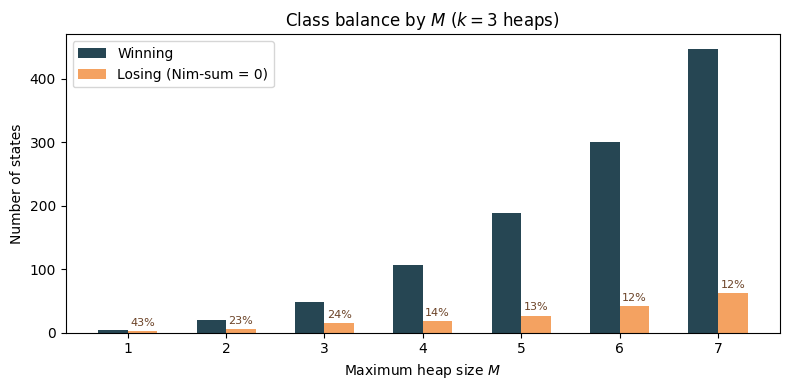

In [ ]:
print(f"Total non-terminal states: {len(dataset)}")
print(f"  Winning: {dataset.is_winning.sum()}  Losing: {(1 - dataset.is_winning).sum()}")

maj_acc = majority_baseline_accuracy(dataset.is_winning)
print(f"\nMajority-class (always predict 'winning') baseline accuracy: {maj_acc:.1%}")

balance = class_balance_table(M_values=range(1, 8), k=3)

fig, ax = plt.subplots(figsize=(8, 4))
x = balance["M"]
ax.bar(x - 0.15, balance["winning"], width=0.3, label="Winning", color="#264653")
ax.bar(x + 0.15, balance["losing"], width=0.3, label="Losing (Nim-sum = 0)", color="#f4a261")
for i, row in balance.iterrows():
    ax.text(row["M"] + 0.15, row["losing"] + 5, f"{row['pct_losing']:.0f}%",
            ha="center", va="bottom", fontsize=8, color="#6b4226")
ax.set_xlabel("Maximum heap size $M$")
ax.set_ylabel("Number of states")
ax.set_title("Class balance by $M$ ($k = 3$ heaps)")
ax.legend()
ax.set_xticks(range(1, 8))
plt.tight_layout()
plt.show()

**Figure 1:** Class balance of winning vs losing (Nim-sum $=0$) positions vs maximum heap size $M$ ($k=3$ heaps).


The heatmaps below show the win/loss pattern in the $(h_1, h_2)$ plane for each $h_3$ from 0 to 7. Losing positions (Nim-sum $= 0$, orange) satisfy $h_1 \oplus h_2 \oplus h_3 = 0$, i.e. $h_1 \oplus h_2 = h_3$. The boundary shape depends on $h_3$: at $h_3 = 0$ it is the **main diagonal** ($h_1 = h_2$); at $h_3 = 7$ the **anti-diagonal** ($h_2 = 7 - h_1$); for other values (e.g. $h_3 = 3$) the losing set is **scattered**. The XOR decision boundary is non-smooth and varies with $h_3$, which is what makes this problem hard for classical models on raw features.

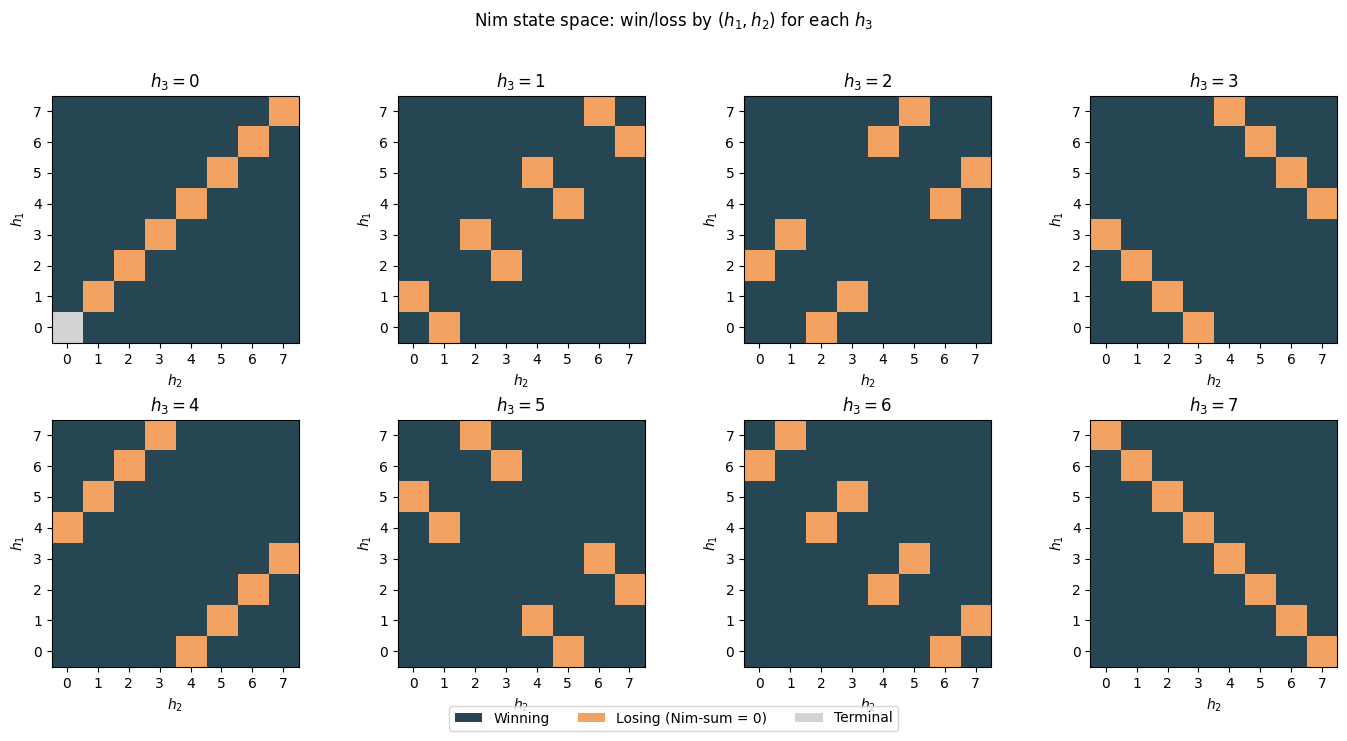

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
cmap = plt.cm.colors.ListedColormap(["lightgrey", "#f4a261", "#264653"])
for ax, h3 in zip(axes.flat, range(8)):
    grid = np.zeros((8, 8), dtype=int)
    for h1 in range(8):
        for h2 in range(8):
            if (h1, h2, h3) == (0, 0, 0) and h3 == 0:
                grid[h1, h2] = -1
            else:
                grid[h1, h2] = 1 if (h1 ^ h2 ^ h3) != 0 else 0
    ax.imshow(grid, origin="lower", cmap=cmap, vmin=-1, vmax=1)
    ax.set_xlabel("$h_2$")
    ax.set_ylabel("$h_1$")
    ax.set_title(f"$h_3 = {h3}$")
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))

legend_elements = [Patch(facecolor="#264653", label="Winning"),
                   Patch(facecolor="#f4a261", label="Losing (Nim-sum = 0)"),
                   Patch(facecolor="lightgrey", label="Terminal")]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Nim state space: win/loss by $(h_1, h_2)$ for each $h_3$", y=1.02)
plt.tight_layout()
plt.show()



**Figure 2:** Win/loss pattern in the $(h_1,h_2)$ plane for each fixed $h_3$; losing states satisfy $h_1 \oplus h_2 = h_3$ (terminal cell grey).


### 2.5 Train/test split and training-size subsets

We use `prepare_experiment_data(k=3, M=7, M_train=5, subset_sizes=(25, 50, 100, 150), random_state=42)` to obtain the dataset, OOD split (`split`), and training-size subsets (25, 50, 100, 150, full). **Train set:** 215 states (heaps $\leq 5$). **Test set:** 296 states (at least one heap $> 5$, heaps $\leq 7$). Stratification is on the binary win/loss label so every partition preserves the ~88 / 12 class ratio. This design tests whether models learn the Nim-sum rule rather than memorising the training distribution.

**Training-size subsets:** stratified sub-samples at sizes 25, 50, 100, 150, and full (215). Each pipeline is trained on every subset with 10+ seeds and evaluated on the test set. All splits use `random_state=42`.

### 2.6 Feature normalisation

Classical features are the raw heap sizes normalised by a fixed $M_{\max} = 7$: $x_i = h_i / M_{\max} \in [0, 1]$.  This global constant ensures the feature range is consistent between train and test (training on $M \leq 5$ and testing on $M \leq 7$ use the same denominator).

In [ ]:
X_norm = normalise_states(split.X_train, M_max=7)
print(f"Normalised training features: shape {X_norm.shape}, "
      f"range [{X_norm.min():.3f}, {X_norm.max():.3f}]")
print(f"Example: heaps {tuple(int(x) for x in split.X_train[0])} "
      f"→ features {tuple(round(float(x), 3) for x in X_norm[0])}")

Normalised training features: shape (215, 3), range [0.000, 0.714]
Example: heaps (0, 0, 1) → features (0.0, 0.0, 0.143)


### 2.7 Heap permutation symmetry ($S_3$)

Nim with $k = 3$ heaps has **$S_3$ permutation symmetry**: the states $(3, 5, 2)$, $(5, 2, 3)$, $(2, 3, 5)$, and all other permutations are **strategically identical** — the Nim-sum $h_1 \oplus h_2 \oplus h_3$ is invariant under heap reordering, so win/loss status and optimal strategy are unchanged. Any optimal move on one permutation maps to an optimal move on the corresponding heap in another permutation.

This symmetry is directly relevant to the **sample efficiency hypothesis**: if a model must independently learn that $(3, 5, 2)$ and $(5, 2, 3)$ are equivalent, it needs more data than one that exploits this equivalence structurally. In this section we use two approaches:

1. **Data augmentation** — for each training example $(h_1, h_2, h_3)$, add all distinct permutations (up to $6\times$ expansion). Straightforward; applies equally to classical and QML pipelines.
2. **Canonical ordering** — sort heaps ascending ($h_1 \leq h_2 \leq h_3$) before encoding. This collapses equivalent states into a single representative, reducing the effective state space.

In [ ]:
# --- Example: S_3 symmetry of a single state ---
example = np.array([3, 5, 2])
perms = all_heap_permutations(example)
print(f"State {tuple(int(x) for x in example)} has {len(perms)} unique permutations:")
for p in perms:
    print(f"  {p}  Nim-sum = {nim_sum(p)}")

# --- Canonical ordering collapses 511 states → fewer equivalence classes ---
n_canonical = count_canonical_states(k=3, M=7)
print(f"\nCanonical states (k=3, M=7): {n_canonical} "
      f"(collapsed from {len(dataset)} raw states, "
      f"reduction factor {len(dataset)/n_canonical:.1f}×)")

# Show canonical counts across M values
print("\nCanonical state counts by M:")
for M_val in [3, 4, 5, 6, 7]:
    raw = len(enumerate_states(3, M_val))
    canon = count_canonical_states(3, M_val)
    print(f"  M={M_val}: {raw:>4} raw → {canon:>4} canonical "
          f"(reduction {raw/canon:.1f}×)")

State (3, 5, 2) has 6 unique permutations:
  (2, 3, 5)  Nim-sum = 4
  (2, 5, 3)  Nim-sum = 4
  (3, 2, 5)  Nim-sum = 4
  (3, 5, 2)  Nim-sum = 4
  (5, 2, 3)  Nim-sum = 4
  (5, 3, 2)  Nim-sum = 4

Canonical states (k=3, M=7): 119 (collapsed from 511 raw states, reduction factor 4.3×)

Canonical state counts by M:
  M=3:   63 raw →   19 canonical (reduction 3.3×)
  M=4:  124 raw →   34 canonical (reduction 3.6×)
  M=5:  215 raw →   55 canonical (reduction 3.9×)
  M=6:  342 raw →   83 canonical (reduction 4.1×)
  M=7:  511 raw →  119 canonical (reduction 4.3×)


In [ ]:
# --- Data augmentation: expansion at each training size ---
print("Augmentation expansion by training-size subset:\n")
print(f"{'Subset':>8}  {'Original':>8}  {'Augmented':>9}  {'No-dedup':>8}  {'Factor':>7}")
print("-" * 52)

for key in [25, 50, 100, 150, "full"]:
    sub = subsets[key]
    X_aug, y_aug = augment_s3(sub.X, sub.y, deduplicate=True)
    X_aug_nd, _ = augment_s3(sub.X, sub.y, deduplicate=False)
    label = str(key) if isinstance(key, int) else f"full ({sub.size})"
    print(f"{label:>8}  {sub.size:>8}  {len(X_aug):>9}  {X_aug_nd.shape[0]:>8}  "
          f"{len(X_aug)/sub.size:>6.2f}×")

# --- Canonical ordering of the training set ---
X_canon, sort_perms = canonical_order(split.X_train)
n_unique_canon = len(np.unique(X_canon, axis=0))
print(f"\nTraining set (M≤5): {len(split.X_train)} rows → "
      f"{n_unique_canon} unique canonical forms")

Augmentation expansion by training-size subset:

  Subset  Original  Augmented  No-dedup   Factor
----------------------------------------------------
      25        25         99       150    3.96×
      50        50        153       300    3.06×
     100       100        201       600    2.01×
     150       150        214       900    1.43×
full (215)       215        215      1290    1.00×

Training set (M≤5): 215 rows → 55 unique canonical forms


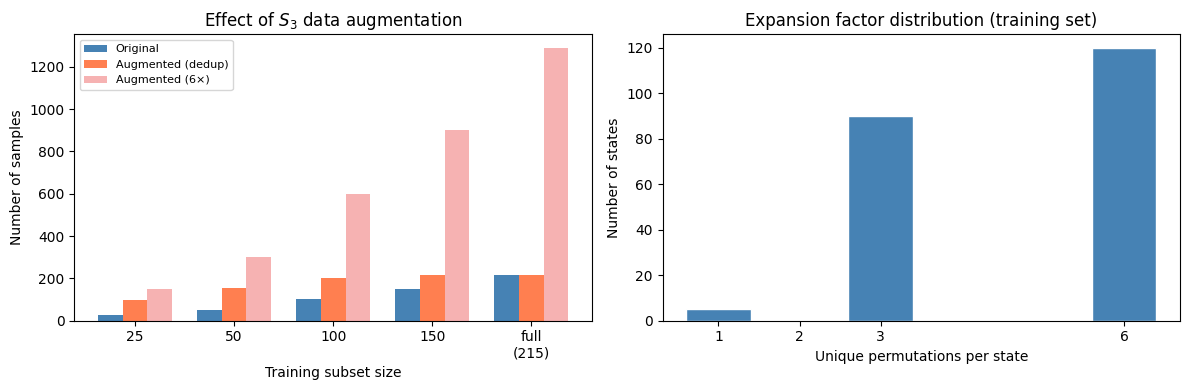

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: augmented size vs original size for each subset
subset_keys = [25, 50, 100, 150, "full"]
orig_sizes, aug_sizes, aug_nd_sizes = [], [], []
for key in subset_keys:
    sub = subsets[key]
    X_a, _ = augment_s3(sub.X, sub.y, deduplicate=True)
    X_and, _ = augment_s3(sub.X, sub.y, deduplicate=False)
    orig_sizes.append(sub.size)
    aug_sizes.append(len(X_a))
    aug_nd_sizes.append(len(X_and))

x_pos = np.arange(len(subset_keys))
w = 0.25
axes[0].bar(x_pos - w, orig_sizes, w, label="Original", color="steelblue")
axes[0].bar(x_pos, aug_sizes, w, label="Augmented (dedup)", color="coral")
axes[0].bar(x_pos + w, aug_nd_sizes, w, label="Augmented (6×)", color="lightcoral", alpha=0.6)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(k) if isinstance(k, int) else f"full\n({subsets[k].size})" for k in subset_keys])
axes[0].set_xlabel("Training subset size")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Effect of $S_3$ data augmentation")
axes[0].legend(fontsize=8)

# Right: per-state expansion factor distribution (full training set)
stats = augmentation_stats(split.X_train)
counts = stats["n_unique_perms"].value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Unique permutations per state")
axes[1].set_ylabel("Number of states")
axes[1].set_title("Expansion factor distribution (training set)")
axes[1].set_xticks([1, 2, 3, 6])

plt.tight_layout()
plt.show()

**Discussion:**

- The 511 non-terminal states collapse to **119 canonical equivalence classes** under $S_3$, a $4.3\times$ reduction. States with all-distinct heaps (expansion factor 6) dominate; states with repeated heaps contribute fewer unique permutations.
- **Data augmentation helps most at smaller sample sizes.** At 50 samples, many generated permutations are genuinely new. At full training size (215), deduplication removes most of that gain because the training set already covers many permutations.
- **Canonical ordering** gives a fixed $4.3\times$ reduction regardless of subset size, but removes heap identity (which physical heap was which). For **win/loss** labels that is harmless because the class is invariant under $S_3$; `canonical_order` still returns the per-row sort indices for reproducibility and any diagnostics that need to relate sorted rows back to the original ordering.

Both approaches will be used as controlled variables in the sample-efficiency experiment, comparing raw vs augmented vs canonical at each training size for both classical and QML pipelines.

## 3. Classical ML Baseline

We train three classifiers — **SVM (RBF kernel)**, **Random Forest**, and **Logistic Regression** — on the win/loss classification task. All models use `class_weight='balanced'` to address the ~88/12 class imbalance (Section 2.4).

**Feature variants:**
- **Raw:** normalised heap sizes $(h_i / M_{\max})$ — 3 features.
- **Parity:** raw features augmented with heap parities ($h_i \bmod 2$), pairwise XOR values ($h_i \oplus h_j$ normalised), and column-wise bit parities (individual bits of the Nim-sum) — 12 features total.

**Symmetry variants:** Each configuration is run with **none**, **$S_3$ data augmentation**, or **canonical** ascending heap order before featurisation (Section 2.7, Section 3.2).

**Sample efficiency:** Each configuration is trained on subsets of size 25, 50, 100, 150, and full (215) with **10 seeds** per configuration. Each seed produces a different stratified subsample, so variance reflects both data sampling and (for Random Forest) model randomness.

**Evaluation:** Balanced accuracy (primary), MCC, F1, and win rate vs random (200 games per configuration).

### 3.1 Feature engineering preview

The examples below show the binary structure parity features expose:

| State $(h_0,h_1,h_2)$ | $h_0$ bits | $h_1$ bits | $h_2$ bits | Nim-sum bits $(h_0 \oplus h_1 \oplus h_2)$ | Class |
|---|---|---|---|---|---|
| $(3,5,2)$ | 011 | 101 | 010 | 100 | winning |
| $(4,4,0)$ | 100 | 100 | 000 | 000 | losing |
| $(7,7,7)$ | 111 | 111 | 111 | 111 | winning |

**Table 3:** Binary feature-engineering preview for three example heap triples. The Nim-sum bits are exactly the column-wise bit parities used by the engineered parity representation.


**Parity and bit parity**

Before visualising the feature spaces, we define what the parity-style features represent and why they matter for Nim.

- **Heap parity:** $h_i \bmod 2$ — odd/even per heap (3 features).
- **Pairwise XOR:** $h_i \oplus h_j$ normalised by $M$ — XOR of each pair of heaps (3 features).
- **Column-wise bit parity:** for each bit position $b$, the XOR of that bit across the three heaps. Formally, bit $b$ is $\bigoplus_i \lfloor h_i / 2^b \rfloor \bmod 2$, i.e. the $b$-th bit of the Nim-sum (3 features for $M = 7$).

**Why it matters:** A position is **losing** if and only if Nim-sum $= 0$, which is equivalent to all bit parities being zero. So the **bit parities are exactly the bits of the Nim-sum**; a linear classifier on those bits can achieve perfect win/loss classification. The next plot shows this geometrically: in 2D PCA, raw features do not separate the classes, whereas parity and bit-parity features do. A more detailed ablation of parity-style feature sets is in Section 3.4.

**Feature space visualization**

We visualise the OOD train set in raw, parity, and bit-parity feature spaces via PCA (2 components). Points are coloured by win/loss. This shows why parity features separate the classes and raw features do not.

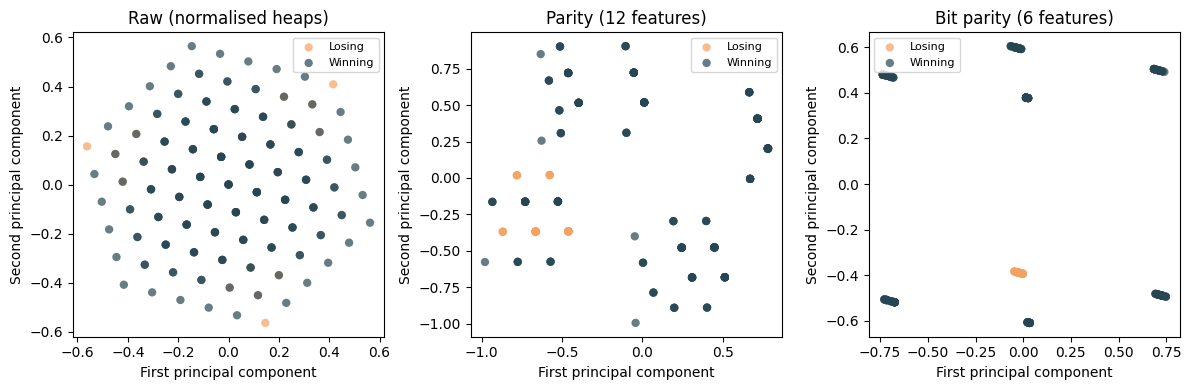

In [ ]:
M = 7
X_train_raw = prepare_features(split.X_train, "raw", M=M)
X_train_parity = prepare_features(split.X_train, "parity", M=M)
X_train_bit = prepare_features(split.X_train, "bit_parity", M=M)
y = split.y_train

pca_raw = PCA(n_components=2).fit(X_train_raw)
pca_parity = PCA(n_components=2).fit(X_train_parity)
pca_bit = PCA(n_components=2).fit(X_train_bit)

Z_raw = pca_raw.transform(X_train_raw)
Z_parity = pca_parity.transform(X_train_parity)
Z_bit = pca_bit.transform(X_train_bit)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ["#f4a261", "#264653"]  # losing, winning
labels = ["Losing", "Winning"]

for ax, Z, title in [
    (axes[0], Z_raw, "Raw (normalised heaps)"),
    (axes[1], Z_parity, "Parity (12 features)"),
    (axes[2], Z_bit, "Bit parity (6 features)"),
]:
    for cls, color, label in [(0, colors[0], labels[0]), (1, colors[1], labels[1])]:
        mask = y == cls
        ax.scatter(Z[mask, 0], Z[mask, 1], c=color, label=label, alpha=0.7, edgecolors="none")
    ax.set_xlabel("First principal component")
    ax.set_ylabel("Second principal component")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
axes[0].set_ylabel("Second principal component")
plt.tight_layout()
plt.show()

**Figure 4:** 2D PCA of raw vs parity feature spaces (OOD train set), coloured by win/loss. Parity and bit-parity features separate the classes; raw (normalised heaps) do not.

### 3.2 Sample-efficiency sweep

We train on $M \leq 5$ (subsets 25, 50, 100, 150, full = 215) and test on $M > 5$ (296 states). 3 models $\times$ 2 feature sets $\times$ 3 symmetry variants (`none`, `augmented`, `canonical`) $\times$ 5 training sizes $\times$ 10 seeds = **900 configurations** with win-rate evaluation (200 games each).

In [ ]:
sweep = run_classical_sweep(
    split.X_train,
    split.y_train,
    split.X_test,
    split.y_test,
    model_names=("SVM (RBF)", "Random Forest", "Logistic Regression"),
    feature_sets=("raw", "parity"),
    symmetry_variants=("none", "augmented", "canonical"),
    train_sizes=(25, 50, 100, 150, "full"),
    seeds=tuple(range(10)),
    M=7,
    compute_win_rate=True,
    n_games_win_rate=200,
    mlflow_experiment=resolve_experiment("classical", "baseline"),
    use_cache=USE_CACHE,
    max_workers=SWEEP_WORKERS,
)

  Loaded 900 runs from MLflow cache.
  Sweep complete: 900/900 runs.


### 3.3 Sample-efficiency curves

For each training budget, we report mean $\pm$ 95% CI over 10 seeds along
two complementary axes:

- **Balanced accuracy on the OOD test set** — per-state classification (win/loss). Averaging per-class recall avoids inflation from the ~88/12 class imbalance (Section 2.4).
- **Win rate vs a random opponent (200 games / seed)** — the same classifier deployed as a one-ply policy: among legal moves, prefer those whose resulting position is predicted *losing* for the opponent, else play randomly.

Figure 5 plots balanced accuracy (top row) and win rate (bottom row) against
training budget, with one column per model. We track MCC in `sweep_summary`
for reference but do not plot it because it follows balanced accuracy closely
on this task.

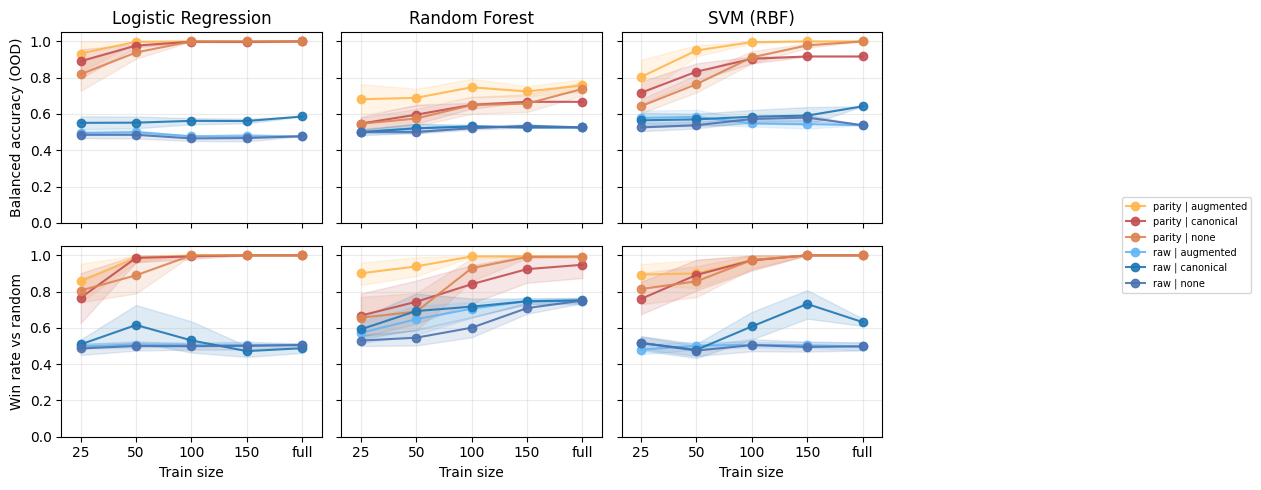

In [ ]:
sweep_df = sweep.to_dataframe()
summary_sorted = format_classical_sweep_summary_display(sweep)
fig, axes = plot_classical_sample_efficiency_curves(
    summary_sorted,
    full_train_n=len(split.X_train),
)
plt.show()

**Figure 5:** Mean ± 95% CI over 10 seeds. Top row: balanced accuracy on the OOD test set ($M > 5$). Bottom row: win rate vs a random opponent (200 games / seed).

**What the curves show.**

- **Features dominate.** For all models and budgets, parity-family
  configurations (warm colours) sit well above raw-feature configurations
  (blue family). Raw balanced accuracy stays near 0.5 (chance), showing that
  normalised heap sizes do not expose the Nim-sum structure.
- **Logistic Regression + parity saturates at $n=50$.** It reaches balanced
  accuracy and win rate near 1.0 from the smallest budget, consistent with
  the fact that column-wise bit parities are exactly the Nim-sum bits
  (Section 3.1, Section 3.4).
- **SVM (RBF) + parity** rises from ~0.85 balanced accuracy at $n=50$ to
  ~1.0 at full, with win rate tracking similarly. It needs more data than LR
  to recover the same structure.
- **Random Forest + parity** is weakest on balanced accuracy, plateauing near
  0.70–0.75 at full size. Its win rate still approaches 1.0, showing that
  classification quality and policy quality can diverge.
- **Raw features + Random Forest** show the same decoupling in the opposite
  direction: balanced accuracy stays near 0.5 while win rate rises to
  ~0.70–0.75.
- **Symmetry variants (`none` / `augmented` / `canonical`) are secondary.**
  Within each feature family the curves overlap heavily and CI bands cross.
  Feature representation is the primary driver.

These patterns motivate the Section 3.4 ablation, then set up Section 4 (encoding choices) and Section 5.5 (quantum-kernel SVM): the classical bar to beat on this task is not raw features (trivial) but parity-feature LR/SVM.

Balanced accuracy and win rate answer different questions: the top row measures whether labels are recovered on unseen heap sums $M > 5$; the bottom row measures how well the same classifier plays when turned into a greedy one-ply policy. The two need not move together — strong i.i.d. classification can still leave gaps in play, and a mediocre classifier can still steer most games if its mistakes fall on moves it never needs to pick.

### 3.4 Feature ablation

To avoid strawman comparisons with QML and understand *which* engineered features drive the leap from ~54% (OOD raw) to ~100% (parity) balanced accuracy, we run an ablation study on SVM (RBF). Each ablation subset adds one feature group to the normalised heap sizes:

| Feature set | Dim | Added features |
|---|---|---|
| `raw` | 3 | Normalised heap sizes only |
| `heap_parity` | 6 | + per-heap parities ($h_i \bmod 2$) |
| `pairwise_xor` | 6 | + pairwise XOR ($h_i \oplus h_j / M$) |
| `bit_parity` | 6 | + column-wise bit parities (individual Nim-sum bits) |
| `parity` | 12 | All of the above |

The **column-wise bit parities** encode the individual bits of the Nim-sum (bit $b$ is $\bigoplus_i \lfloor h_i / 2^b \rfloor \bmod 2$). A linear model can combine them to perfectly classify win/loss, since $\text{Nim-sum} = 0 \iff$ all bit parities are zero. This makes `bit_parity` the most structurally relevant ablation subset for the Nim problem.

The ablation below compares **parity-style feature sets only** (heap_parity, pairwise_xor, bit_parity, parity); the raw-feature baseline is reported in the main sweep and sample-efficiency plot (Section 3.3).

**Note on the plot:** The "All parity features (12)" bars can be *shorter* than the "+ column bit parities (6)" bars — this is expected. At small training sizes the full parity set underperforms bit parities alone because the extra dimensions (heap parities, pairwise XOR) add noise when data is scarce; bit parities already suffice for perfect Nim-sum classification. At full training size both reach 1.0.

  Loaded 200 runs from MLflow cache.
  Sweep complete: 200/200 runs.


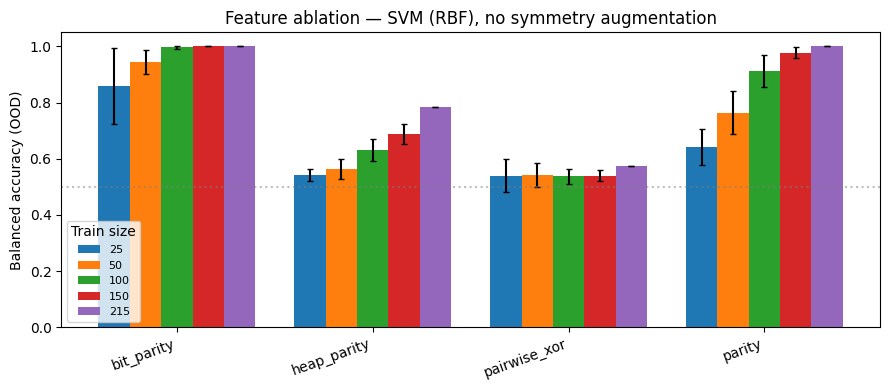

In [ ]:
ablation_sweep = run_parity_feature_ablation_sweep(
    split.X_train,
    split.y_train,
    split.X_test,
    split.y_test,
    mlflow_experiment=resolve_experiment("classical", "ablation"),
    use_cache=USE_CACHE,
    max_workers=SWEEP_WORKERS,
)
abl_display = parity_ablation_summary_display(ablation_sweep)
fig, ax = plot_parity_feature_ablation_balanced_accuracy(abl_display)
plt.tight_layout()
plt.show()

**Figure 7:** Parity-style feature ablation for SVM (RBF): mean $\pm$ std balanced accuracy by feature set and training size.


### 3.5 Strengthened baselines: key findings

Results below use the same sample-efficiency design (train M≤5, test M>5).

**Feature ablation:**
- The **column-wise bit parities** (`bit_parity`) are the most informative
  group because they directly encode the Nim-sum bits. SVM (RBF) with
  bit parities alone reaches 0.995 balanced accuracy at 50 training samples
  and 1.000 at $\geq 100$.
- **Heap parities** ($h_i \bmod 2$) and **pairwise XOR** both improve over
  raw features but remain below bit parities (~0.77 and ~0.79 at full size,
  respectively). Nim-sum classification needs the full bitwise parity signal.
- The full `parity` set (12 features) does **not** outperform `bit_parity`.
  At 50 samples, full parity (0.870) is below bit parity (0.995), likely
  because extra dimensions add noise in the low-data regime. At full
  training size (215), both converge to 1.000.

**Implication for QML:** With strong classical features the task is easy.
The QML question is whether a quantum feature map can recover equivalent
structure (especially bitwise XOR) from raw inputs without explicit feature
engineering, and do so with strong sample efficiency.

### 3.6 Why Nim is a relevant testbed for QML

The classical results reveal a clear structural divide in Nim classification
and motivate the QML experiments.

**The Nim-sum boundary is XOR.** A position $(h_1, h_2, h_3)$ is losing iff
$h_1 \oplus h_2 \oplus h_3 = 0$. This is a parity function over binary
heap encodings. From raw inputs, smooth models struggle to recover this
boundary. Our results reflect that: SVM (RBF) on **raw** heaps reaches about
**0.54** OOD balanced accuracy at full training size (215) with **no**
symmetry handling and about **0.64** with **canonical** ordering; Logistic
Regression on raw remains near chance (~0.47–0.50).

**Parity features make the task easy.** The engineered **parity** vector
(Section 3.4) includes bit parities and related terms. SVM and Logistic
Regression then achieve **near-perfect to perfect** OOD scores (typically
$\geq 0.95$ at 50 samples and 1.000 at full size for most symmetry modes).
The ablation (Section 3.4) shows where this signal comes from: bit parities alone
saturate, while heap parities and pairwise XOR are only partial.

**Sample-efficiency hypothesis.** Quantum feature maps with rotations and
entanglers can encode relationships aligned with parity functions. Angle
encoding maps each heap size to $R_Y(h_i \pi / M)$; binary encoding maps
each heap to 3 bits (9 qubits total) and can entangle corresponding bit
positions across heaps, mirroring bitwise XOR structure. If the quantum map
captures this structure from raw inputs, VQCs should learn with fewer
examples than classical raw-feature baselines.

**What QML needs to beat.** Reference points from the sample-efficiency sweep (means over 10 seeds; train $M\leq 5$, test $M>5$):

| Baseline | Raw features | Parity feature vector (12-D) |
|---|---|---|
| SVM (RBF), full (215), OOD | ~0.54 bal. acc., ~0.50 win rate (**none**); ~0.64 bal. acc., ~0.63 win rate (**canonical**) | 1.000 bal. acc., 1.000 win rate (most symmetry modes) |
| Strong at 50 samples | up to ~0.58 bal. acc. (SVM-RBF raw with augmentation) | typically $\geq 0.95$ bal. acc. (SVM-RBF parity; exact mean depends on symmetry) |

**Generalisation.** This split tests whether models learn the Nim-sum rule
or memorise small boards. With parity features, SVM and Logistic Regression
reach **perfect or near-perfect** OOD classification at full training size.
**Random Forest** on parity peaks around **0.74–0.76** balanced accuracy
(symmetry-dependent), despite often high win rates. On **raw** features,
Logistic Regression stays near chance and SVM improves only modestly unless
**canonical** ordering is used. For QML, the practical target is to beat
raw-feature classical curves, not the parity-engineered ceiling.

**Symmetry as inductive bias.** The sweep compares **none**, **$S_3$
augmentation**, and **canonical** ordering (Section 3.2–Section 3.3). On **raw**
features, augmentation does **not** rescue Random Forest OOD balanced
accuracy (~0.52–0.53 at full size, similar to no augmentation). Canonical
ordering helps **SVM (RBF)** on raw (~0.54 $\to$ ~0.64 at full size in this
run). On **parity** features, augmentation helps Random Forest slightly
(~0.74 $\to$ ~0.76 at full), while canonical ordering **hurts** RF parity
here (~0.67 at full). For QML, the open question is whether equivariant or
learned invariances can capture permutation structure without hand-crafted
parity features.


### 3.7 Kernel-aligned classical baseline (angle vs RBF)

#### Why a third classical baseline

The sweep in Section 3.2 and ablation in Section 3.4 compare classical models on two
feature representations (raw vs parity). A third comparison is still needed
before we trust any later QSVM result: we have to rule out the possibility
that a future "QSVM beats classical" claim is really "angle kernel beats RBF
kernel" — i.e. an artifact of kernel choice rather than anything quantum.
This section introduces that **kernel-aligned** classical baseline so Sections 6, 7, and 11 can make an apples-to-apples comparison.

#### What the angle kernel is

Section 6's QSVM will use **angle encoding** as one of its feature maps,
mapping each raw heap to an
$R_Y$ rotation on its own qubit,

$$|\psi(\mathbf{x})\rangle = \bigotimes_{i=1}^{3} R_Y(h_i\pi/M)|0\rangle,$$

and the quantum kernel it induces is the state-overlap
$|\langle\psi(\mathbf{x})|\psi(\mathbf{x}')\rangle|^2$. For this specific
product-state encoding that overlap has a closed form:

$$K_{\text{angle}}(\mathbf{x}, \mathbf{x}') =
  \prod_{i=1}^{3} \cos^{2}\!\left(\frac{(x_i - x'_i)\,\pi}{2}\right),$$

with $x_i = h_i / M$. So we can compute *exactly* the same kernel the QSVM
will use — classically, in NumPy — and plug it straight into a standard
`sklearn` SVM via a custom kernel callable
(`qml_project.baselines.kernels.angle_encoding_kernel`).

That gives us a classical SVM whose feature map matches the quantum one.
Any remaining gap between this baseline and the QSVM in Section 6 is then
attributable to stochastic shot estimation, hardware noise, or training
differences — **not** to a different similarity measure. And any gap
between SVM (RBF) and SVM (Angle Kernel) here tells us how much of an
eventual "quantum win" is already inside the kernel choice itself.

#### Protocol

Same raw inputs, same OOD split, same seeds and train sizes as Section 3.2.
Symmetry is fixed to `none` to match Section 6's angle-encoding QSVM which
runs on raw unsorted heaps; adding $S_3$ augmentation here would bias the
baseline in directions the QSVM cannot exploit by construction.

In [ ]:
kernel_baseline_sweep = run_classical_sweep(
    split.X_train,
    split.y_train,
    split.X_test,
    split.y_test,
    model_names=("SVM (RBF)", "SVM (Angle Kernel)"),
    feature_sets=("raw",),
    symmetry_variants=("none",),
    train_sizes=(25, 50, 100, 150, "full"),
    seeds=tuple(range(10)),
    M=7,
    compute_win_rate=True,
    n_games_win_rate=200,
    mlflow_experiment=resolve_experiment("classical", "kernel_aligned"),
    use_cache=USE_CACHE,
    max_workers=SWEEP_WORKERS,
)
kernel_baseline_df = kernel_baseline_sweep.to_dataframe()

  Loaded 100 runs from MLflow cache.
  Sweep complete: 100/100 runs.


#### Results: angle vs RBF on raw heaps

Summary below groups by kernel and training budget (symmetry fixed to
`none`, raw features). We report balanced accuracy and win rate (mean ±
std over 10 seeds) because those are the metrics Section 6's QSVM will
report against.

In [ ]:
kernel_baseline_summary = kernel_baseline_sweep.summary(
    group_cols=("model", "train_size"),
)
kernel_baseline_display = format_kernel_aligned_baseline_display(kernel_baseline_summary)
display(kernel_baseline_display.sort_values(["model", "train_size"]))

,model,train_size,balanced_accuracy_mean,balanced_accuracy_std,win_rate_mean,win_rate_std,n_runs
0,SVM (Angle Kernel),25,0.508,0.021,0.508,0.050,10
1,SVM (Angle Kernel),50,0.516,0.046,0.488,0.071,10
2,SVM (Angle Kernel),100,0.551,0.026,0.484,0.052,10
3,SVM (Angle Kernel),150,0.565,0.018,0.502,0.053,10
4,SVM (Angle Kernel),215,0.574,0.000,0.495,0.042,10
5,SVM (RBF),25,0.526,0.039,0.518,0.056,10
6,SVM (RBF),50,0.538,0.031,0.475,0.046,10
7,SVM (RBF),100,0.572,0.021,0.505,0.051,10
8,SVM (RBF),150,0.580,0.028,0.495,0.043,10
9,SVM (RBF),215,0.538,0.000,0.498,0.036,10


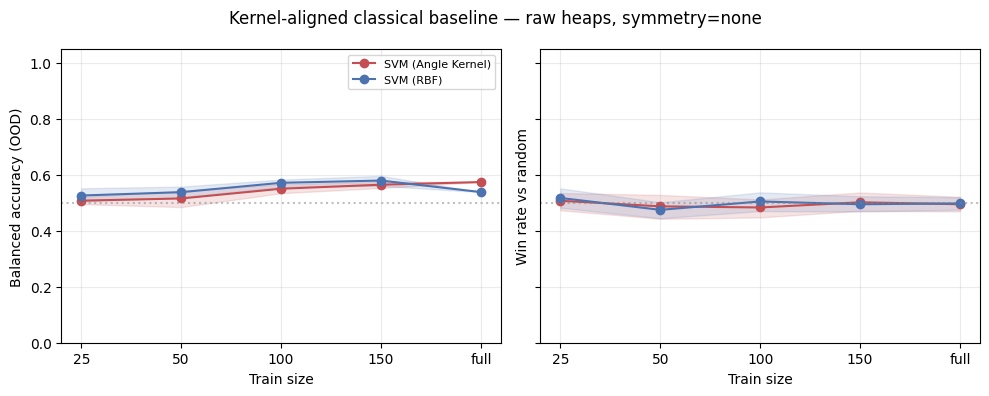

In [ ]:
fig, axes = plot_kernel_aligned_baseline_curves(
    kernel_baseline_summary,
    full_train_n=len(split.X_train),
)
plt.show()

**Figure 8:** SVM with RBF kernel vs SVM with the classical angle kernel
(the closed-form overlap of angle-encoded product states), both on raw
normalised heaps with no symmetry handling. Shaded band is mean ± 95 % CI
over 10 seeds.

**What the results show — "angle ≈ RBF, and both fail on raw heaps".**
Balanced accuracy sits in [0.52, 0.57] across all budgets for both
kernels, and win rate hovers around 0.48–0.51 (chance). The gap between
angle and RBF is within ≈0.02–0.04 balanced accuracy at every training
size and essentially zero on win rate. Concretely:

- At n=50 and n=100, RBF is marginally ahead on balanced accuracy
  (0.538 vs 0.516, 0.572 vs 0.551), within one seed-std.
- At n=215 the sample-variance collapses (there is only one stratified
  full-training subset, and SVM is deterministic on it), and **angle**
  edges ahead: 0.574 vs 0.538.
- Win rates for both kernels stay indistinguishable from a random
  opponent at every budget.

**Implication for Section 6.** Kernel choice alone is not the hidden
confounder in any future QSVM-vs-RBF comparison — on the same raw
inputs, the *classical* angle kernel does not meaningfully beat RBF, and
neither kernel cracks Nim-sum structure from raw heaps. So when Section 6
reports QSVM results on angle-encoded raw inputs:

- A QSVM score close to 0.55 balanced accuracy would reproduce this
  classical ceiling, not exceed it.
- A QSVM score meaningfully above it would have to come from something
  the classical analytic kernel does not capture (e.g. entanglement in
  a richer feature map or a trainable kernel), not from "angle being a
  better similarity measure than RBF".

This also sharpens the Section 3.2 conclusion: the structural bottleneck on
this task is the **feature representation** (raw vs parity), not the
kernel acting on those features.

### 3.8 Canonical `classical_df` artifact

**Section 9.3** uses the `sub_study == "main"` slice of `classical_df` and the same
``classical_raw_best`` row selection as **Section 11** (raw heaps, best model×symmetry)
for the classical learning curve on the quantum overlay. **Section 11** uses
the same in-memory `classical_df` for the full classical × simulated-quantum ×
device comparison (including ``classical_pool`` and heap-only quantum slices).

We concatenate the main sweep, feature ablation (SVM-only), and the
kernel-aligned comparison into one long-format frame tagged with a
`sub_study` column so each contribution is traceable.

In [ ]:
def _tag(df: "pd.DataFrame", sub_study: str) -> "pd.DataFrame":
    out = df.copy()
    out["pipeline"] = "classical"
    out["sub_study"] = sub_study
    return out


classical_df = pd.concat(
    [
        _tag(sweep_df, "main"),
        _tag(ablation_sweep.to_dataframe(), "ablation"),
        _tag(kernel_baseline_df, "kernel_aligned"),
    ],
    ignore_index=True,
    sort=False,
)

print(
    f"classical_df: {len(classical_df)} rows, "
    f"{classical_df['sub_study'].value_counts().to_dict()}"
)
_nim_demo_p = export_nim_demo_classical_df(classical_df)
print(f"nim_demo: wrote `{_nim_demo_p.name}` under notebooks/.workflow_cache/")

classical_df: 1200 rows, {'main': 900, 'ablation': 200, 'kernel_aligned': 100}
nim_demo: wrote `classical_df.parquet` under notebooks/.workflow_cache/


/tmp/ipykernel_200039/2883401635.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  classical_df = pd.concat(


## 4. Design-Space Analysis: Encodings, Ansatze, and Sweep Axes

Section 3 fixed classical ceilings on raw and parity features; this chapter is the **design-space primer** for the quantum pipelines. It
lays out swept axes for **Section 5 (VQC)** and **Section 6 (QSVM)**: trainable
ansätze and CZ entangler strategies are **VQC-only**; QSVM sweeps encodings and
kernel / SVM knobs inside fixed **variants**—and reports architecture-level
diagnostics (VQC `build_circuit` ansätze) that set expectations for what those
sweeps should find. No performance runs happen here — pilot
sweeps and full hyperparameter grids both live downstream, so the evidence
that ultimately selects a winner is all produced on a single, consistent
protocol.

Concretely this section covers:

- **Encoding inventory:** angle, amplitude, and binary feature maps. Circuit
  construction, qubit/depth resources, and why each is a candidate.
- **Ansatz inventory (VQC):** `basic_block` and `ry_rz`. Circuit construction and
  per-qubit structure, drawn on a representative `(n_qubits, n_features)`.
- **Architecture diagnostics (VQC):** expressibility (KL divergence from Haar),
  entangling capability (Meyer–Wallach), and a barren-plateau gradient
  variance screen. Run for both ansätze at each encoding's qubit count so
  the readings reflect the actual VQC widths that will be trained.
- **Other sweep axes:** Section 5 varies depth, CZ strategy, loss / observable
  pairing, shots (inference + robustness ladder), and noise / mitigation; the
  main VQC tuning grid fixes `symmetry="none"`. Section 6 varies encoding,
  Nim-sum, $C$, symmetry, and estimator mode **across declared variants** (see
  Section 6.1). Each axis is motivated before the corresponding sweep cells.
- **Expectations:** what the diagnostics tell us to anticipate for VQC and
  QSVM performance.

**References:** [13] (barren plateaus), [19] (expressibility, entangling
capability), [18] (quantum feature spaces / kernels), [20] (noisy shallow
gate-based circuit design).

### 4.1 Encoding inventory

We evaluate three encoding strategies that trade off qubit count, depth,
and the implicit similarity metric they induce:

1. **Angle encoding.** For heap vector $(h_1,h_2,h_3)$ and $M_{\max}=7$,
   $\theta_i = h_i\pi/M_{\max}$, then $U_{\text{angle}}(s)=\prod_i R_Y(\theta_i)$.
   When ``include_nim_sum`` is true (QSVM default), append
   $R_Y(\mathrm{Nim\text{-}sum}(s)\,\pi/M_{\max})$ on a **fourth** qubit so the
   optional Nim-sum channel matches amplitude/binary; with false, **3 qubits**
   (heap-only).
2. **Amplitude encoding.** Form
   $v(s)=[h_1/M,\,h_2/M,\,h_3/M,\,\mathrm{Nim\text{-}sum}(s)/M]$ when the Nim-sum
   coordinate is on, L2-normalise to $\tilde v$, and initialise
   $|\psi(s)\rangle=\sum_j \tilde v_j |j\rangle$. Uses **2 qubits** (length-4
   vector). Compact, but similarity collapses to a cosine measure.
3. **Binary encoding.** Each heap is written as 3 little-endian bits
   $h_i \mapsto (b_{i,0},b_{i,1},b_{i,2})$. Set $X$ on qubits whose bit is 1
   and add CZ links among equal bit positions across heaps to reflect
   Nim-sum XOR structure. A **fixed-width Nim-sum register** (3 qubits) follows
   the heap block; when ``include_nim_sum`` is false it stays $|000\rangle$.
   **12 qubits** total at ``bits_per_heap=3``; most expressive, highest cost.

In [ ]:
example_state = (3, 5, 2)

theta = angle_parameters(example_state, M=7)
amp = amplitude_vector(example_state, M=7)
bits = binary_bits(example_state)

encoding_circuits = {
    "angle": build_encoding_circuit("angle", example_state, M=7),
    "amplitude": build_encoding_circuit("amplitude", example_state, M=7),
    "binary": build_encoding_circuit("binary", example_state, symmetry="none"),
}

encoding_profiles = {
    "angle": {
        "n_qubits": int(encoding_circuits["angle"].num_qubits),
        "n_features": int(encoding_circuits["angle"].num_qubits),
        "depth": int(encoding_circuits["angle"].depth()),
        "note": "One RY per heap (+ optional RY on Nim-sum), no entanglers.",
    },
    "amplitude": {
        "n_qubits": int(encoding_circuits["amplitude"].num_qubits),
        "n_features": 4,
        "depth": int(encoding_circuits["amplitude"].depth()),
        "note": "Length-4 L2-normalised vector → 2-qubit statevector init.",
    },
    "binary": {
        "n_qubits": int(encoding_circuits["binary"].num_qubits),
        "n_features": int(encoding_circuits["binary"].num_qubits),
        "depth": int(encoding_circuits["binary"].depth()),
        "note": "Heap bits + Nim-sum register + cross-heap CZ (XOR structure).",
    },
}

encoding_profile_df = pd.DataFrame.from_dict(
    encoding_profiles, orient="index"
).reset_index(names="encoding")
print(f"Representative state: {example_state}")
print(f"Angle parameters: {np.round(theta, 4)}")
print(f"Amplitude vector length: {len(amp)}")
print(f"Binary bits: {bits}")
display(encoding_profile_df)

Representative state: (3, 5, 2)
Angle parameters: [1.3464 2.244  0.8976 1.7952]
Amplitude vector length: 4
Binary bits: [1 1 0 1 0 1 0 1 0]


,encoding,n_qubits,n_features,depth,note
0,angle,4,4,1,"One RY per heap (+ optional RY on Nim-sum), no..."
1,amplitude,2,4,1,Length-4 L2-normalised vector → 2-qubit statev...
2,binary,12,12,3,Heap bits + Nim-sum register + cross-heap CZ (...


**Table 4.1:** Circuit resource profile per encoding on the representative
state `(3, 5, 2)`. `n_qubits` is the encoding circuit width; `n_features`
is the length of the classical vector fed to VQC classifiers when the same
encoding is used as an angle-feature map. Binary's higher depth reflects
the cross-heap CZ links that encode Nim-sum structure.


ANGLE encoding circuit


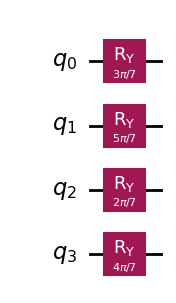


AMPLITUDE encoding circuit


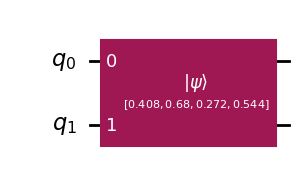


BINARY encoding circuit


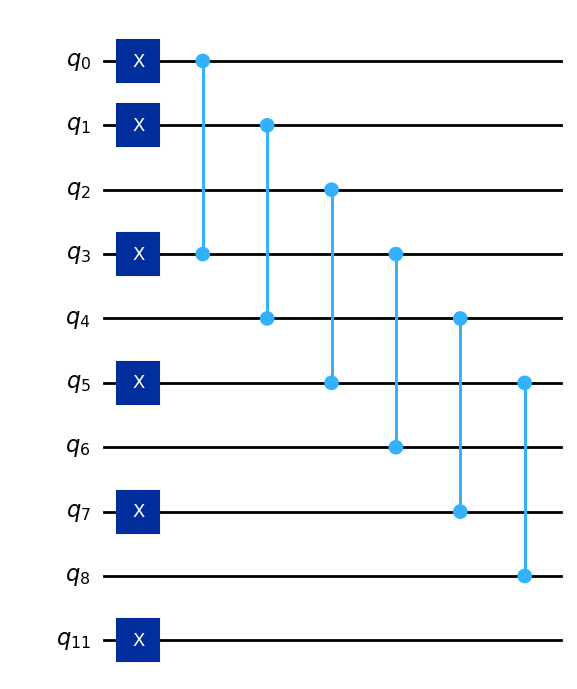

In [ ]:
for name, circuit in encoding_circuits.items():
    print(f"\n{name.upper()} encoding circuit")
    fig = circuit.draw(output="mpl", fold=-1, idle_wires=False)
    display(fig)

**Figure 4.1:** Encoding circuits for `(3, 5, 2)` with default
``include_nim_sum=True``. Angle (top) uses four independent `RY` rotations
(heap angles + Nim-sum). Amplitude (middle) is statevector initialisation on
two qubits. Binary (bottom) is twelve qubits: nine heap bits plus a Nim-sum
register, with per-bit `X` gates and three CZ chains on heap qubits.

### 4.2 Ansatz inventory

Two per-qubit ansatz families appear in the **Section 5 VQC** grid (`build_circuit`).
Section 6 (QSVM) fits SVMs on quantum kernels built from the same **encoding**
family (angle / amplitude / binary); it does **not** use these trainable ansätze.
Both VQC ansätze use the same CZ entangler schedule, so the comparison isolates
the single-qubit block:

- **`basic_block`:** $R_X(\pi/2)\!\to\!R_Z(\theta)\!\to\!R_X(\pi/2)$ per qubit,
  then a CZ entangler layer. One trainable parameter per qubit per layer.
- **`ry_rz`:** $R_Y(\theta_a)\!\to\!R_Z(\theta_b)$ per qubit, then the same
  CZ layer. Two trainable parameters per qubit per layer, so higher
  parameter density at matched depth.

CZ strategies evaluated in **Section 5** only: `"linear"` (nearest-neighbour CZ
chain) and `"all"` (all-pairs CZ). For 2-qubit amplitude circuits the two
strategies are equivalent, so the VQC grid dedupes that slice to a single
`"linear"` column.

basic_block (6 parameters):


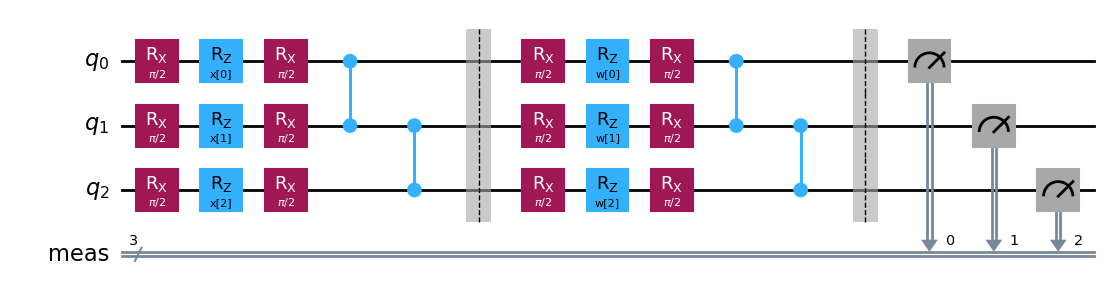


ry_rz (6 parameters):


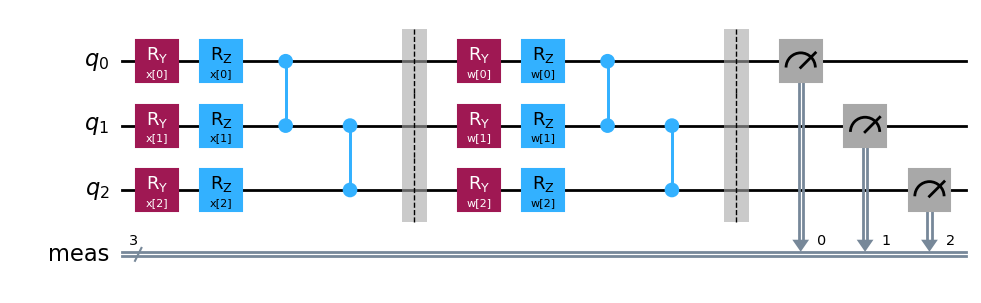

In [ ]:
ansatz_demo_n_qubits = 3
ansatz_demo_n_features = 3
ansatz_demo_n_layers = 2

vc_basic = build_circuit(
    n_qubits=ansatz_demo_n_qubits,
    n_features=ansatz_demo_n_features,
    n_classes=2,
    n_layers=ansatz_demo_n_layers,
    cz_strategy="linear",
    cz_seed=42,
    ansatz="basic_block",
)
vc_ryrz = build_circuit(
    n_qubits=ansatz_demo_n_qubits,
    n_features=ansatz_demo_n_features,
    n_classes=2,
    n_layers=ansatz_demo_n_layers,
    cz_strategy="linear",
    cz_seed=42,
    ansatz="ry_rz",
)

print(f"basic_block ({vc_basic.circuit.num_parameters} parameters):")
display(vc_basic.circuit.draw(output="mpl", fold=-1, idle_wires=False))
print(f"\nry_rz ({vc_ryrz.circuit.num_parameters} parameters):")
display(vc_ryrz.circuit.draw(output="mpl", fold=-1, idle_wires=False))

**Figure 4.2:** Ansatz circuits at `n_qubits=3, n_features=3, n_layers=2,
cz_strategy="linear"`. Visually, `ry_rz` carries more trainable parameters
per layer (two rotations per qubit vs one). Both share the same CZ
schedule, so depth differences are driven by the single-qubit block only.

### 4.3 Architecture diagnostics

Two complementary diagnostics summarise **VQC** `build_circuit` ansatz behaviour
at the qubit count each encoding induces (QSVM kernel circuits are not screened
here):

- **Expressibility** [19]: KL divergence between the fidelity distribution
  of random pairs of ansatz-induced states and the Haar distribution.
  Lower KL is more expressive.
- **Entangling capability** [19]: mean Meyer–Wallach entanglement $Q$ over
  random parameter draws. Higher $Q$ is more entangling.
- **Barren plateau screen** [13]: finite-difference gradient variance of a
  simple $\langle Z_0 \rangle$ cost as depth increases. A fast decay with
  depth warns of training instability.

We evaluate all three at every `(encoding, ansatz)` pair in the design
space, at a depth close to the Section 5 sweep midpoint (`n_layers=4`).
For the barren-plateau screen we also report a depth ladder `[2, 4, 6]`
per ansatz so the slope is visible.

In [ ]:
diag_df, grad_df, arch_diag_cache_msg = run_architecture_diagnostics_dataframes(
    encoding_profiles,
    mlflow_experiment=resolve_experiment("vqc", "pilot", variant="architecture-diagnostics"),
    use_cache=USE_CACHE,
    ansatze=["basic_block", "ry_rz"],
    diagnostic_depth_ladder=[2, 4, 6],
    diagnostic_base_depth=4,
)
if arch_diag_cache_msg:
    print(arch_diag_cache_msg)

display(diag_df.round(4))

  Architecture diagnostics: loaded 6 expressivity rows and 18 gradient rows from MLflow ('nim.vqc.pilot.architecture-diagnostics').


,encoding,n_qubits,diag_n_features,ansatz,kl_to_haar,mw_mean,mw_std
0,amplitude,2,2,basic_block,0.2356,0.3287,0.2802
1,amplitude,2,2,ry_rz,0.0310,0.3794,0.2657
2,angle,4,4,basic_block,0.1894,0.6214,0.2033
3,angle,4,4,ry_rz,0.0261,0.6379,0.1599
4,binary,12,12,basic_block,0.0000,0.7154,0.1030
5,binary,12,12,ry_rz,0.0000,0.7294,0.0774


**Table 4.2:** Expressibility and entangling capability per
`(encoding, ansatz)` at `n_layers=4`. `kl_to_haar` lower is more
expressive; `mw_mean` higher is more entangling. Values depend on qubit
count (different encoding widths) so rows are only directly comparable
within the same encoding row block.

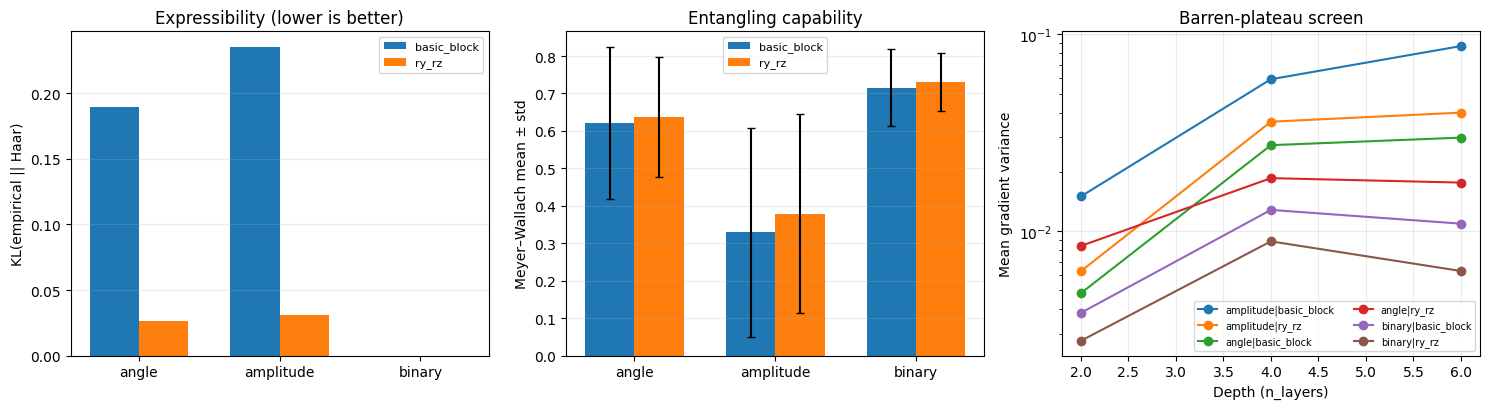

In [ ]:
_arch_diag_fig = plot_architecture_diagnostics_triptych(
    diag_df,
    grad_df,
    encodings_order=list(encoding_profiles.keys()),
    ansatze=["basic_block", "ry_rz"],
)
if _arch_diag_fig is not None:
    plt.show()

**Figure 4.3:** Architecture diagnostics across `(encoding, ansatz)` pairs.
Plotting: ``plot_architecture_diagnostics_triptych`` in ``qml_project.report_plots``.
The left panel reports KL-to-Haar expressibility at `n_layers=4`; the
middle panel reports Meyer–Wallach entangling capability; the right panel
tracks gradient variance as depth grows from 2 to 6, on a log scale, to
screen for barren plateaus. Wider encodings—**binary uses 12 qubits** here (nine
heap bits plus a three-qubit Nim-sum register at ``bits_per_heap=3``)—exaggerate
both entangling capability and potential trainability issues.

**Reading the diagnostics:**

- Expressibility (left): both ansatze approach Haar similarly at small
  widths; differences widen at larger qubit counts.
- Entangling capability (middle): `ry_rz` tends to dominate at equal
  depth due to its higher parameter density.
- Barren plateau (right): steeper downward slopes at higher qubit counts
  (binary especially) flag training risk. If binary-VQC gradients collapse
  rapidly by depth 6 we should expect optimisation difficulty in Section 5's
  binary sweep.

### 4.4 Other sweep axes and why each matters

Swept axes are deliberately limited to where we expect measurable signal. **VQC
(Section 5)** crosses encoding (with ``include_nim_sum``), ansatz, depth, and CZ strategy;
**QSVM (Section 6)** crosses encoding (with ``include_nim_sum``) inside fixed **variant**
rows that already pin $C$, symmetry, and estimator mode.

- **Depth (`n_layers`) — per encoding (Section 5).** Grids are anchored to each
  encoding's minimum viable depth so shallow vs deep is fair *within* that
  encoding: **angle** → `{2, 4}`, **amplitude** → `{4, 6}` (four features on two
  qubits require at least four layers), **binary** → `{2, 4}`. The barren-plateau
  ladder in Section 4.3 still uses `[2, 4, 6]` as a **screen**, not as an extra VQC sweep
  slice beyond Section 5.
- **CZ strategy ∈ {linear, all} (VQC only).** Linear is the minimal-cost entangler
  schedule; all-pairs probes whether full connectivity is needed on small widths.
  Equivalent at `n_qubits=2` (amplitude), so the VQC grid keeps a single strategy
  there.
- **Symmetry.** Nim exhibits $S_3$ heap-permutation symmetry (Section 2).
  `canonical` sorts heaps before encoding; `none` leaves raw heap order. **VQC
  tuning** fixes `symmetry="none"` on every config so the grid size stays
  manageable. **QSVM** varies symmetry **across variants** (e.g. one slice uses
  `canonical`, others `none`; see Section 6.1).
- **Loss × observable.** Section 5 keeps `softmax_nll + bitstring_probs + argmax`
  as the primary pairing and only revisits `cross_entropy_expectation +
  z_expectation + expectation_threshold` if the primary pairing fails the
  balanced-accuracy threshold. Keeping the pairing fixed reduces the grid.
- **Shot budget.** Main sweeps use `test_shots=300` (inference-only;
  training uses statevector gradients). The robustness sub-sweep uses
  `shot_budgets ∈ {512, 1024, 2048}` to probe the shots-vs-bias trade-off
  for the top-ranked tuning config.
- **Noise model × mitigation.** Section 5 attaches a robustness grid with
  depolarising rates `{0, 0.005, 0.01, 0.02}` and optional readout
  correction + zero-noise extrapolation. Purpose is to forecast how the
  winner config degrades under device-like noise before Section 10's live
  submission.
- **QSVM-specific axes** (Section 6): `c_svc` (SVC regularisation),
  `include_nim_sum`, `iqp_reps`, `bits_per_heap`, and estimator mode
  (analytic statevector vs shot-binomial). These are standard quantum
  kernel knobs for an angle / amplitude / binary feature map.

Axes **excluded by design** on this dataset:

- Depths beyond each encoding's Section 5 pair (e.g. >6 after amplitude's `{4, 6}`, or >4 on angle/binary after `{2, 4}`): the Section 4.3 screen flags barren-plateau risk if we extended the VQC grid further.
- Full encoding sub-grids beyond three candidates (e.g. `ZZFeatureMap`,
  `PauliFeatureMap`): out of scope; Sections 4–6 use angle, amplitude, and
  binary encodings only.
- Optimisers beyond Adam-style: matches the course reference
  implementation; swapping optimiser is orthogonal to the design
  questions this section answers.

### 4.5 Expectations

From the diagnostics and the dataset properties established in Sections 2–3:

- **Angle encoding** is the natural fit for continuous heap sizes. The
  barren-plateau screen should show stable gradients at 3–4 qubits through
  depth 6, so we expect VQC training to converge cleanly.
- **Amplitude encoding** is compact (2 qubits) and its similarity metric
  is a cosine measure — this is ideal for QSVM (kernel methods thrive on
  smooth similarities) and should be **QSVM's strongest encoding**, as the
  course kernel tutorial ([quantum-kernels-qiskit] skill) anticipates.
  For VQC, 2 qubits caps expressibility; expect a tighter accuracy
  ceiling even at depth 4.
- **Binary encoding** is the most expressive (12 qubits with Nim-sum
  register, Nim-sum CZ structure on heap bits) but also the most fragile:
  gradient variance should decay fastest here. Expect slower training, higher seed variance, and the
  highest noise sensitivity in the robustness sub-sweep.

Section 5 expands the Cartesian **VQC** grid (encoding × ``include_nim_sum`` ×
ansatz × ``n_layers`` × ``cz_strategy``). Section 6 runs one
``run_quantum_kernel_sweep`` per **variant** (each variant fixes $C$, symmetry,
and estimator; the sweep expands encoding × ``include_nim_sum`` × train size ×
seed, plus shot-binomial settings where declared). Both pick winners
on balanced accuracy + win rate + circuit cost, with Pareto selection
handled in Section 7.

## 5. VQC Workflow — Encoding, Ansatz, Depth, CZ, Noise

This is the single VQC chapter. It sweeps the full design space laid out
in Section 4:

- **Encoding** ∈ {angle, amplitude, binary}
- **Ansatz** ∈ {basic_block, ry_rz}
- **Depth** (`n_layers`) — per-encoding shallow vs deep, anchored to each
  encoding's minimum viable depth `2 * ceil(n_features / n_qubits)`
  (required so every feature parameter is placed in the circuit).
  Concretely: angle → {2, 4}, amplitude → {4, 6}, binary → {2, 4} (twelve
  qubits for the binary map including the Nim-sum register slice).
- **CZ strategy** ∈ {linear, all} — collapsed to a single slice when
  `n_qubits=2` (amplitude) because the two strategies are equivalent.

Every point is evaluated on the OOD protocol (train sizes `25, 50, 100, 150, full`
× 10 seeds), matching the protocol used by Sections 3 (classical) and 6
(QSVM) so cross-pipeline comparisons in Section 7 are like-for-like.

### 5.1 Feature transformation per encoding

VQC classifiers consume angle-feature vectors. The three encodings follow the
same ``include_nim_sum`` ablation as Section 6 (QSVM): each encoding gets two
circuit slices (``True`` / ``False``) via distinct ``config_id`` suffixes
``|ns=T`` / ``|ns=F``.

- **angle:** 3 or 4 features (heap ``RY`` angles ± optional ``nim_sum`` angle),
  same width as qubits.
- **amplitude:** 4 features (L2-normalised amplitude vector, with or without the
  Nim-sum coordinate) scaled by π, 2 qubits.
- **binary:** 12 features and 12 qubits — heap bits plus a fixed-width Nim-sum
  register as ``{0,π}`` angles (register zeros when ``include_nim_sum`` is false).

In [ ]:
print("Per-encoding VQC circuit profiles (× include_nim_sum):")
display(pd.DataFrame(build_vqc_profile_summary_rows()))

Per-encoding VQC circuit profiles (× include_nim_sum):


,encoding,include_nim_sum,n_qubits,n_features,min_layers,depths,cz_strategies
0,angle,True,4,4,2,"2,4","linear,all"
1,angle,False,3,3,2,"2,4","linear,all"
2,amplitude,True,2,4,4,"4,6",linear
3,amplitude,False,2,4,4,"4,6",linear
4,binary,True,12,12,2,"2,4","linear,all"
5,binary,False,12,12,2,"2,4","linear,all"


### 5.2 Configuration grid

The grid is the Cartesian product `encoding × ansatz × n_layers ×
cz_strategy`, with amplitude's CZ axis collapsed to a single point and
each encoding's depth grid anchored to its minimum viable depth (see
Section 5.1 — amplitude needs `n_layers >= 4` to fit all four features on two
qubits). `loss_name`, `observable`, `decision_rule`, and `symmetry` are
fixed to the pairing motivated in Section 4.

In [ ]:
vqc_config_grid = build_vqc_tuning_config_grid()
display(vqc_config_grid_preview_dataframe(vqc_config_grid))
print(f"Grid size: {len(vqc_config_grid)} configurations")

,config_id,encoding,include_nim_sum,ansatz,n_qubits,n_features,n_layers,cz_strategy
0,angle|basic_block|d=2|cz=linear|ns=T,angle,True,basic_block,4,4,2,linear
1,angle|basic_block|d=2|cz=all|ns=T,angle,True,basic_block,4,4,2,all
2,angle|basic_block|d=4|cz=linear|ns=T,angle,True,basic_block,4,4,4,linear
3,angle|basic_block|d=4|cz=all|ns=T,angle,True,basic_block,4,4,4,all
4,angle|ry_rz|d=2|cz=linear|ns=T,angle,True,ry_rz,4,4,2,linear
5,angle|ry_rz|d=2|cz=all|ns=T,angle,True,ry_rz,4,4,2,all
6,angle|ry_rz|d=4|cz=linear|ns=T,angle,True,ry_rz,4,4,4,linear
7,angle|ry_rz|d=4|cz=all|ns=T,angle,True,ry_rz,4,4,4,all
8,angle|basic_block|d=2|cz=linear|ns=F,angle,False,basic_block,3,3,2,linear
9,angle|basic_block|d=2|cz=all|ns=F,angle,False,basic_block,3,3,2,all


Grid size: 40 configurations


**Table 5.1:** VQC configuration grid. `n_qubits` and `n_features` follow
the encoding profile from Section 5.1; each encoding's depth pair is anchored
to its minimum viable depth (shallow = `min_layers`, deep = `min_layers + 2`) so "shallow vs deep" is a fair comparison *within* each encoding.
`symmetry` is fixed to `none` so all encodings see raw heap order.
``include_nim_sum`` is crossed with every encoding so VQC matches Section 6's
Nim-sum ablation (``|ns=T`` / ``|ns=F`` in ``config_id``).
Train size × seed expansion happens inside `run_simulated_vqc_ood_sweep`
(`run_vqc_tuning_workflow_dataframe` in Section 5.3).

### 5.3 Tuning sweep

Every configuration in Table 5.1 is evaluated under the OOD protocol shared
with Sections 3 (classical) and 6 (QSVM): five train sizes
(25, 50, 100, 150, plus the full training set) crossed with ten seeds, each
fit optimised for at most 200 iterations and scored at 300 shots per test
prediction on a statevector sampler. Every fit additionally plays 200 games
against the perfect Nim-sum opponent so each circuit is ranked on both
calibration (balanced accuracy, MCC) and downstream play (win rate).

In [ ]:
vqc_tuning_exp = resolve_experiment("vqc", "tuning")
vqc_workflow_df = run_vqc_tuning_workflow_dataframe(
    split.X_train,
    split.y_train,
    split.X_test,
    split.y_test,
    vqc_config_grid,
    mlflow_experiment=vqc_tuning_exp,
    use_cache=USE_CACHE,
    max_workers=SWEEP_WORKERS,
)
print(
    f"vqc_workflow_df: {len(vqc_workflow_df)} tuning runs across "
    f"{len(VQC_ENCODINGS)} encodings × Nim-sum variants"
)
_nim_demo_p = export_nim_demo_vqc_workflow_df(vqc_workflow_df)
print(f"nim_demo: wrote `{_nim_demo_p.name}` under notebooks/.workflow_cache/")

vqc_tuning (all configs):   0%|          | 0/40 [00:00<?, ?it/s]

vqc_workflow_df: 1500 tuning runs across 3 encodings × Nim-sum variants
nim_demo: wrote `vqc_workflow_df.parquet` under notebooks/.workflow_cache/


### 5.4 Tuning summary per configuration

Mean / std balanced accuracy per `(config_id, train_size)` — this is the
ranking table Section 7's Pareto selection consumes.

In [ ]:
vqc_summary = (
    vqc_workflow_df.groupby(["config_id", "encoding", "ansatz", "train_size"], dropna=False)
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        mcc_mean=("mcc", "mean"),
        win_rate_mean=("win_rate", "mean"),
        training_time_mean=("training_time", "mean"),
        n_runs=("balanced_accuracy", "count"),
    )
    .reset_index()
)
display(vqc_summary.round(3))

,config_id,encoding,ansatz,train_size,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,win_rate_mean,training_time_mean,n_runs
0,amplitude|basic_block|d=4|cz=linear|ns=F,amplitude,basic_block,25,0.481,0.020,-0.045,0.606,4.484,10
1,amplitude|basic_block|d=4|cz=linear|ns=F,amplitude,basic_block,50,0.485,0.032,-0.037,0.644,6.942,10
2,amplitude|basic_block|d=4|cz=linear|ns=F,amplitude,basic_block,100,0.486,0.021,-0.047,0.665,13.218,10
3,amplitude|basic_block|d=4|cz=linear|ns=F,amplitude,basic_block,150,0.475,0.012,-0.073,0.615,17.407,10
4,amplitude|basic_block|d=4|cz=linear|ns=F,amplitude,basic_block,215,0.483,0.014,-0.049,0.744,24.437,10
...,...,...,...,...,...,...,...,...,...,...
145,binary|ry_rz|d=2|cz=linear|ns=T,binary,ry_rz,25,0.734,0.123,0.306,0.484,123.851,10
146,binary|ry_rz|d=2|cz=linear|ns=T,binary,ry_rz,50,0.734,0.123,0.306,0.486,186.645,10
147,binary|ry_rz|d=2|cz=linear|ns=T,binary,ry_rz,100,0.792,0.000,0.382,0.481,311.685,10
148,binary|ry_rz|d=2|cz=linear|ns=T,binary,ry_rz,150,0.792,0.000,0.382,0.481,468.439,10


**Figure 5.1:** VQC tuning learning curves grouped by encoding, one line
per `config_id`.

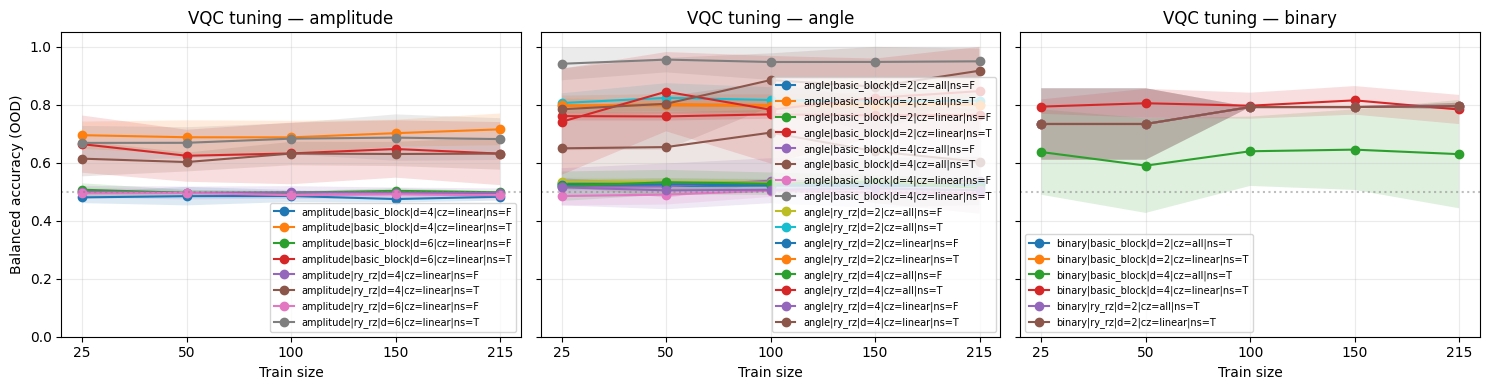

In [ ]:
_vqc_tune_fig = plot_vqc_tuning_curves_by_encoding(vqc_summary)
if _vqc_tune_fig is not None:
    plt.show()

### 5.5 Robustness snapshot on top config

We first identify the top-ranked `config_id` at the **full** tuning train size
(highest mean balanced accuracy across seeds), then run a bounded **noise ×
shots × mitigation** sub-sweep on that single circuit via Aer simulation. Restricting to one winner keeps cost manageable
while still contrasting raw counts, readout correction, ZNE, and the combined
path—the columns Figure 5.2 reads below.

We use the following snapshot settings: depolarising rates
``0.0, 0.005, 0.01, 0.02`` (zero as a noiseless anchor), shot budgets
``512, 1024, 2048`` (Figure 5.2 uses the middle value), seeds ``0 … 4``,
``max_iter=100`` per noisy fit (below Section 5.3's 200 to bound cost), readout and ZNE
mitigation both enabled, and ZNE scale factors ``(1.0, 2.0, 3.0)``.

In [ ]:
vqc_robustness_df, vqc_robustness_meta = run_vqc_robustness_snapshot_dataframe(
    vqc_workflow_df,
    vqc_config_grid,
    split.X_train,
    split.y_train,
    split.X_test,
    split.y_test,
    depolarizing_rates=(0.0, 0.005, 0.01, 0.02),
    shot_budgets=(512, 1024, 2048),
    seeds=tuple(range(5)),
    max_iter=100,
    apply_readout_correction=True,
    apply_zne=True,
    zne_scales=(1.0, 2.0, 3.0),
    mlflow_experiment=resolve_experiment("vqc", "robustness"),
    use_cache=USE_CACHE,
    verbose=False,
    max_workers=SWEEP_WORKERS,
)
if vqc_robustness_meta:
    print(
        f"Top VQC config for robustness: {vqc_robustness_meta['top_config_id']} "
        f"(mean bal_acc={vqc_robustness_meta['mean_balanced_accuracy']:.3f})"
    )
print(f"vqc_robustness_df: {len(vqc_robustness_df)} robustness rows")

Top VQC config for robustness: angle|basic_block|d=4|cz=linear|ns=T (mean bal_acc=0.950)
vqc_robustness_df: 60 robustness rows


**Figure 5.2:** Balanced accuracy of the top VQC config vs depolarising
noise level, at the mid shot budget, comparing raw / readout / ZNE /
readout+ZNE mitigation. Implementation:
``plot_vqc_robustness_balanced_accuracy_vs_noise`` in ``qml_project.report_plots``.

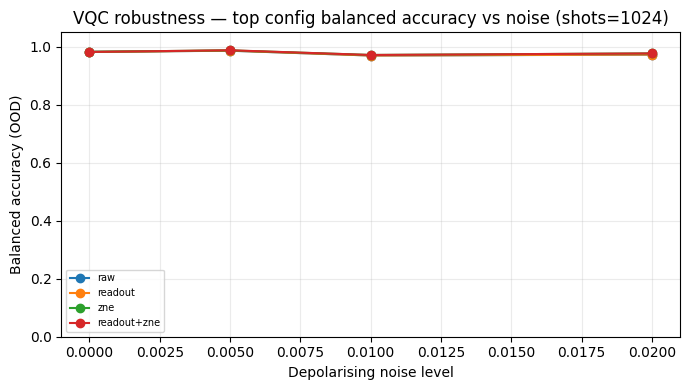

In [ ]:
_vqc_robust_fig = plot_vqc_robustness_balanced_accuracy_vs_noise(vqc_robustness_df)
if _vqc_robust_fig is not None:
    plt.show()
else:
    print("No robustness rows recorded.")

## 6. QSVM workflow — encodings, kernel hyperparameters, $C$, shots

This section fits **quantum-kernel SVMs** on the same Nim heap features as the VQC track. The sweep follows the same train-size ladder as Section 5 ($25, 50, 100, 150$, then the full training set) with ten seeds so `qsvm_workflow_df` lines up with `vqc_workflow_df` for Section 7. **Section 6 compares QSVM variants only** (encoding, Nim-sum, $C$, symmetry, estimator); classical raw/parity baselines are in Section 3, and cross-pipeline classical–quantum comparison is in Section 11.

**What varies:** feature map (`angle`, `amplitude`, `binary`), Nim-sum `(True, False)` on **each** grid row, $C$, symmetry (`none` vs `canonical`), and exact statevector vs finite-shot kernel estimation. **Table 2 (experimental design):** the variant grid below is the deliberate search space. **Table 2 (evaluation):** balanced accuracy, MCC, win rate, and wall times for sample-efficiency and cost plots.

### 6.1 Variant grid

Each row is one $(C, \text{symmetry}, \text{estimator})$ slice. `run_quantum_kernel_sweep` expands encodings, train sizes, and seeds inside that slice.

In [ ]:
qsvm_variants = [
    {
        "variant_id": "sv|C=1|sym=none|ns=(T,F)",
        "c_svc": 1.0,
        "symmetry": "none",
        "estimator_mode": "exact_statevector",
        "kernel_backend": "manual",
        "bits_per_heap": 3,
        "iqp_reps": 2,
        "include_nim_sum": (True, False),
    },
    {
        "variant_id": "sv|C=10|sym=canonical|ns=(T,F)",
        "c_svc": 10.0,
        "symmetry": "canonical",
        "estimator_mode": "exact_statevector",
        "kernel_backend": "manual",
        "bits_per_heap": 3,
        "iqp_reps": 2,
        "include_nim_sum": (True, False),
    },
    {
        "variant_id": "shots=1024|C=1|sym=none|ns=(T,F)",
        "c_svc": 1.0,
        "symmetry": "none",
        "estimator_mode": "shot_binomial",
        "kernel_backend": "manual",
        "shots": 1024,
        "bits_per_heap": 3,
        "iqp_reps": 2,
        "include_nim_sum": (True, False),
    },
]

display(pd.DataFrame(qsvm_variants))

,variant_id,c_svc,symmetry,estimator_mode,kernel_backend,bits_per_heap,iqp_reps,include_nim_sum,shots
0,"sv|C=1|sym=none|ns=(T,F)",1.0,none,exact_statevector,manual,3,2,"(True, False)",NaN
1,"sv|C=10|sym=canonical|ns=(T,F)",10.0,canonical,exact_statevector,manual,3,2,"(True, False)",NaN
2,"shots=1024|C=1|sym=none|ns=(T,F)",1.0,none,shot_binomial,manual,3,2,"(True, False)",1024.0


**Table 6.1:** QSVM variant grid (one row per slice; encoding × train_size × seed lives inside the sweep).

### 6.2 Workflow sweep

``run_qsvm_tuning_workflow_dataframe`` (``qml_project.qsvm.tuning``) loops over ``qsvm_variants``, calls ``run_quantum_kernel_sweep`` per row, copies ``variant_id`` / estimator metadata onto rows for Section 7, concatenates, and adds ``encoding_label``. Explicit arguments below match Section 5’s train ladder and ten seeds; module defaults stay in sync if you omit them elsewhere.

In [ ]:
qsvm_workflow_df = run_qsvm_tuning_workflow_dataframe(
    split.X_train,
    split.y_train,
    split.X_test,
    split.y_test,
    qsvm_variants,
    train_sizes=(25, 50, 100, 150, "full"),
    seeds=tuple(range(10)),
    class_weight="balanced",
    M=7,
    compute_win_rate=True,
    n_games_win_rate=200,
    default_encodings=("angle", "amplitude", "binary"),
    mlflow_experiment=resolve_experiment("qsvm", "tuning"),
    use_cache=USE_CACHE,
    verbose=False,
    max_workers=SWEEP_WORKERS,
)
print(f"qsvm_workflow_df: {len(qsvm_workflow_df)} rows")
_nim_demo_p = export_nim_demo_qsvm_workflow_df(qsvm_workflow_df)
print(f"nim_demo: wrote `{_nim_demo_p.name}` under notebooks/.workflow_cache/")

qsvm_tuning (all variants):   0%|          | 0/3 [00:00<?, ?it/s]

qsvm_workflow_df: 900 rows
nim_demo: wrote `qsvm_workflow_df.parquet` under notebooks/.workflow_cache/


### 6.3 Per-variant summary

Long-form aggregates (mean / std over seeds) for each $(\texttt{variant\_id}, \texttt{encoding}, \texttt{include\_nim\_sum}, \texttt{train\_size})$. The pivot table is the same information with train sizes as columns for a quick read. Aggregation lives in ``summarize_qsvm_workflow_dataframe`` / ``qsvm_balanced_accuracy_mean_pivot`` (``qml_project.qsvm.tuning``).

In [ ]:
qsvm_summary = summarize_qsvm_workflow_dataframe(qsvm_workflow_df)
display(qsvm_summary.round(3))

balanced_accuracy_pivot = qsvm_balanced_accuracy_mean_pivot(qsvm_summary)
display(balanced_accuracy_pivot.round(3))

,variant_id,encoding,include_nim_sum,train_size,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,win_rate_mean,win_rate_std,train_time_s_mean,train_time_s_std,n_runs,kernel_matrix_time_s_mean,kernel_matrix_time_s_std,estimator_mode
0,"shots=1024|C=1|sym=none|ns=(T,F)",amplitude,False,25,0.509,0.025,0.008,0.046,0.462,0.087,0.025,0.005,10,0.023,0.005,shot_binomial
1,"shots=1024|C=1|sym=none|ns=(T,F)",amplitude,False,50,0.517,0.020,0.023,0.026,0.516,0.088,0.049,0.009,10,0.047,0.009,shot_binomial
2,"shots=1024|C=1|sym=none|ns=(T,F)",amplitude,False,100,0.515,0.023,0.020,0.032,0.456,0.070,0.107,0.022,10,0.105,0.021,shot_binomial
3,"shots=1024|C=1|sym=none|ns=(T,F)",amplitude,False,150,0.514,0.014,0.019,0.019,0.494,0.066,0.168,0.038,10,0.166,0.037,shot_binomial
4,"shots=1024|C=1|sym=none|ns=(T,F)",amplitude,False,215,0.503,0.008,0.007,0.045,0.505,0.044,0.256,0.046,10,0.253,0.046,shot_binomial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,"sv|C=1|sym=none|ns=(T,F)",binary,True,25,0.500,0.000,0.000,0.000,0.550,0.087,0.038,0.005,10,0.037,0.005,exact_statevector
86,"sv|C=1|sym=none|ns=(T,F)",binary,True,50,0.500,0.000,0.000,0.000,0.586,0.066,0.087,0.032,10,0.085,0.032,exact_statevector
87,"sv|C=1|sym=none|ns=(T,F)",binary,True,100,0.500,0.000,0.000,0.000,0.666,0.085,0.193,0.040,10,0.191,0.040,exact_statevector
88,"sv|C=1|sym=none|ns=(T,F)",binary,True,150,0.500,0.000,0.000,0.000,0.749,0.054,0.358,0.049,10,0.355,0.048,exact_statevector


train_size                                                    25     50   \
variant_id                       encoding  include_nim_sum                 
shots=1024|C=1|sym=none|ns=(T,F) amplitude False            0.509  0.517   
                                           True             0.803  0.862   
                                 angle     False            0.511  0.514   
                                           True             0.635  0.741   
                                 binary    False            0.500  0.500   
                                           True             0.500  0.500   
sv|C=10|sym=canonical|ns=(T,F)   amplitude False            0.629  0.624   
                                           True             0.915  0.945   
                                 angle     False            0.609  0.586   
                                           True             0.725  0.947   
                                 binary    False            0.500  0.500   
                                           True             0.500  0.500   
sv|C=1|sym=none|ns=(T,F)         amplitude False            0.505  0.517   
                                           True             0.805  0.863   
                                 angle     False            0.508  0.516   
                                           True             0.632  0.747   
                                 binary    False            0.500  0.500   
                                           True             0.500  0.500   

train_size                                                    100    150  \
variant_id                       encoding  include_nim_sum                 
shots=1024|C=1|sym=none|ns=(T,F) amplitude False            0.515  0.514   
                                           True             0.903  0.921   
                                 angle     False            0.545  0.566   
                                           True             0.880  0.936   
                                 binary    False            0.500  0.500   
                                           True             0.500  0.500   
sv|C=10|sym=canonical|ns=(T,F)   amplitude False            0.633  0.661   
                                           True             0.971  1.000   
                                 angle     False            0.639  0.611   
                                           True             0.996  1.000   
                                 binary    False            0.500  0.500   
                                           True             0.500  0.500   
sv|C=1|sym=none|ns=(T,F)         amplitude False            0.520  0.510   
                                           True             0.913  0.928   
                                 angle     False            0.551  0.565   
                                           True             0.880  0.933   
                                 binary    False            0.500  0.500   
                                           True             0.500  0.500   

train_size                                                    215  
variant_id                       encoding  include_nim_sum         
shots=1024|C=1|sym=none|ns=(T,F) amplitude False            0.503  
                                           True             0.930  
                                 angle     False            0.575  
                                           True             0.938  
                                 binary    False            0.500  
                                           True             0.500  
sv|C=10|sym=canonical|ns=(T,F)   amplitude False            0.649  
                                           True             1.000  
                                 angle     False            0.574  
                                           True             1.000  
                                 binary    False            0.500  
                                           True             0.500  
sv|C=1

**Figure 6.1:** Balanced accuracy vs training-set size (**exact statevector** variants only; the finite-shot slice is omitted here and appears in Figures 6.4–6.5). Rows separate **Nim-sum on** and **Nim-sum off**; columns are encodings. Lines are `variant_id`.

Nim-sum rows share $y$-scale across encodings; grey line at 0.5 is chance for balanced accuracy; bands are $\pm 1$ std over seeds. Only **two** `variant_id` curves appear here: both use `exact_statevector`. The finite-shot row (`shot_binomial`) is excluded from this figure and appears in Figures 6.4–6.5. Solid vs dashed lines distinguish `variant_id` when both are present.

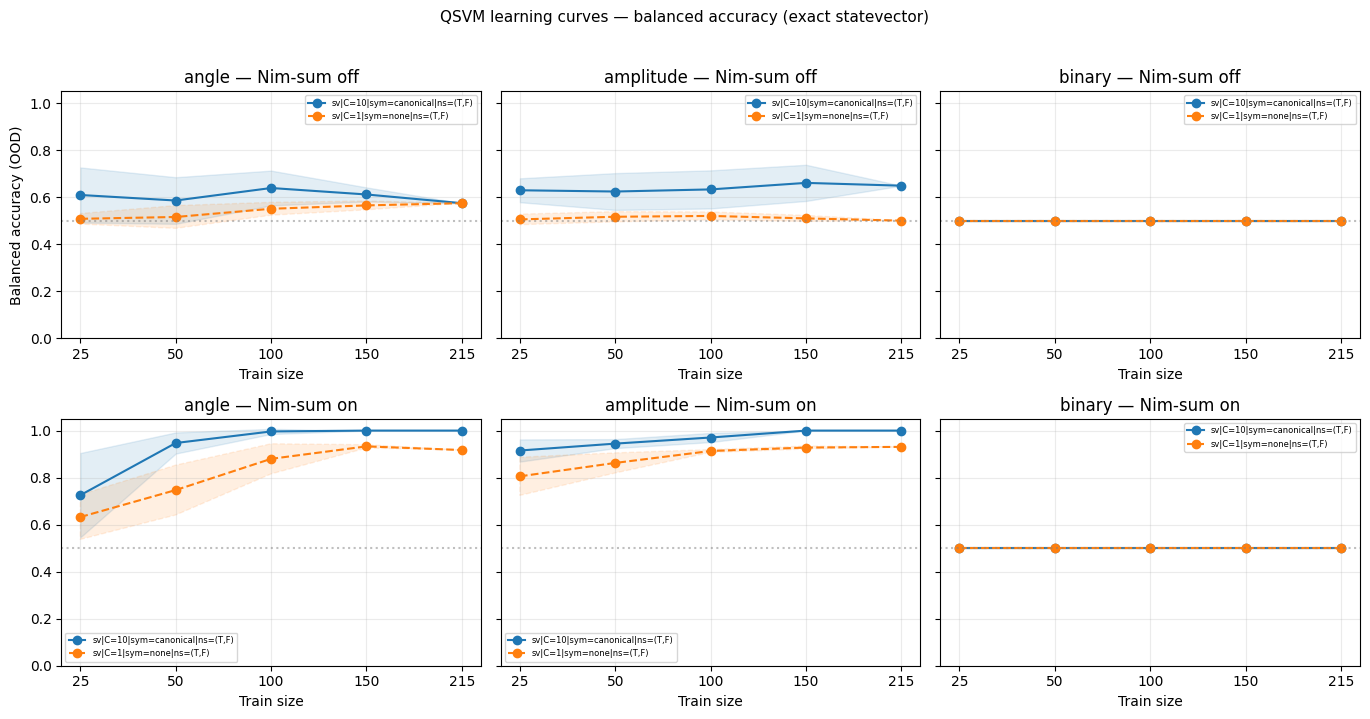

In [ ]:
plot_qsvm_faceted_metric_curves(
    filter_qsvm_summary_exact_statevector(qsvm_summary),
    metric_mean_column="balanced_accuracy_mean",
    metric_std_column="balanced_accuracy_std",
    y_axis_label="Balanced accuracy (OOD)",
    figure_suptitle="QSVM learning curves — balanced accuracy (exact statevector)",
    y_limits=(0.0, 1.05),
    chance_line_y=0.5,
)

**Figure 6.2:** Matthews correlation coefficient vs train size (same faceting and statevector filter as Figure 6.1). Chance performance is MCC $= 0$.

Same layout as Figure 6.1. MCC $\in [-1,1]$; horizontal line at 0 is no correlation.

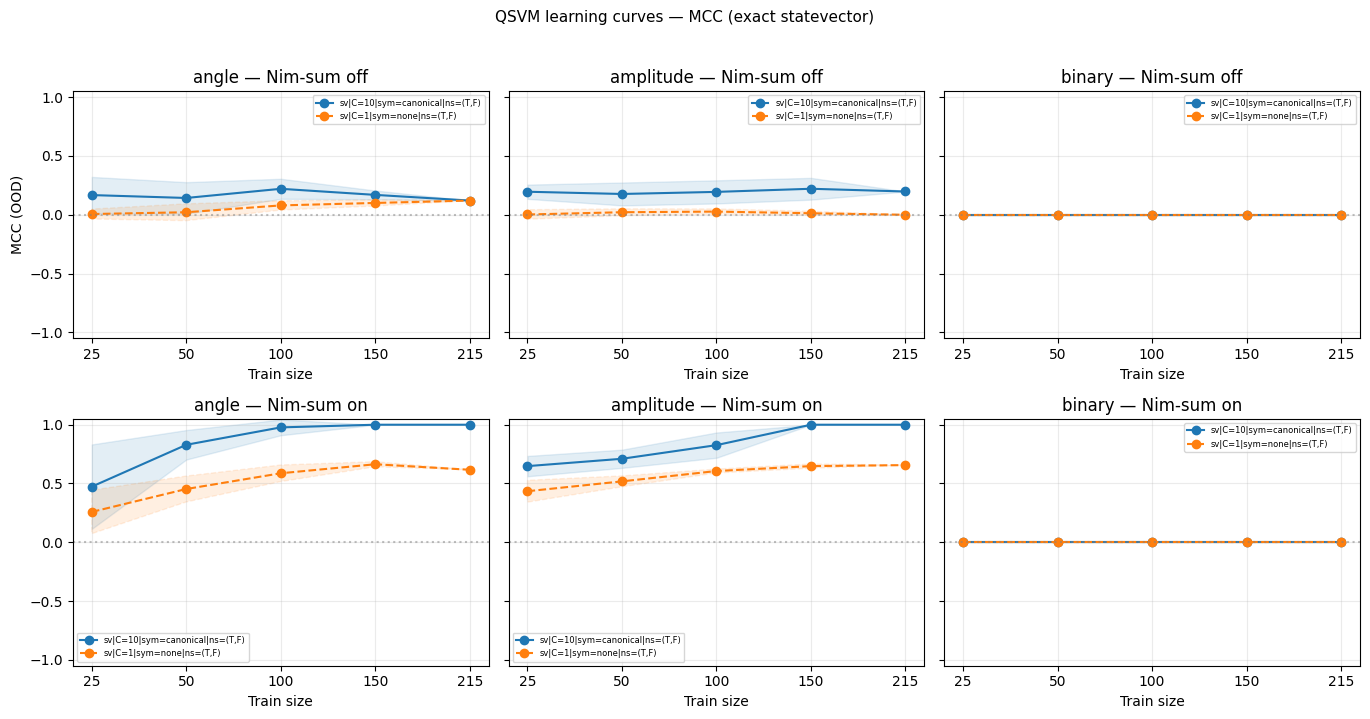

In [ ]:
plot_qsvm_faceted_metric_curves(
    filter_qsvm_summary_exact_statevector(qsvm_summary),
    metric_mean_column="mcc_mean",
    metric_std_column="mcc_std",
    y_axis_label="MCC (OOD)",
    figure_suptitle="QSVM learning curves — MCC (exact statevector)",
    y_limits=(-1.05, 1.05),
    chance_line_y=0.0,
)

**Figure 6.3:** Win rate vs train size (same layout as Figures 6.1–6.2: two exact-statevector variants). Win rate uses the same ten seeds as accuracy; the finite-play estimate can be noisier than accuracy.

Same layout as Figures 6.1–6.2; metric is win rate on the held-out game sample. Bands reflect seed spread in the win-rate estimate.

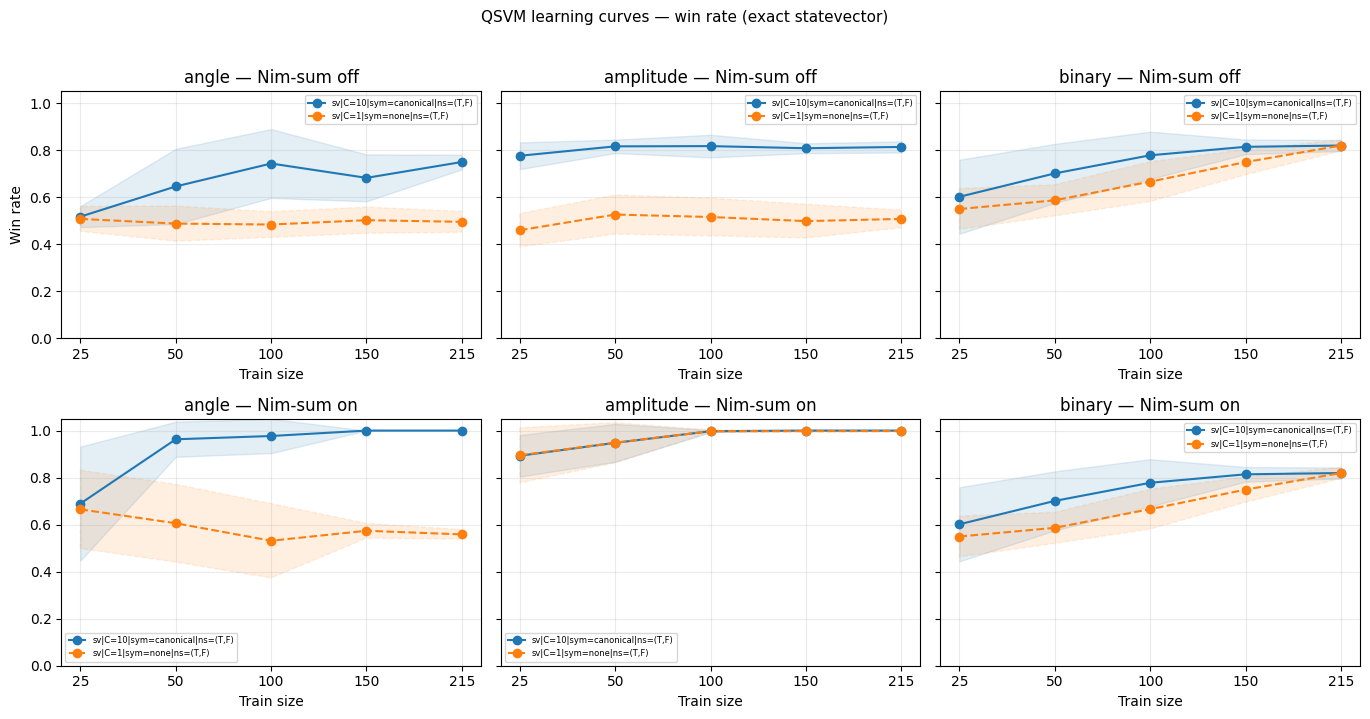

In [ ]:
plot_qsvm_faceted_metric_curves(
    filter_qsvm_summary_exact_statevector(qsvm_summary),
    metric_mean_column="win_rate_mean",
    metric_std_column="win_rate_std",
    y_axis_label="Win rate",
    figure_suptitle="QSVM learning curves — win rate (exact statevector)",
    y_limits=(0.0, 1.05),
    chance_line_y=None,
)

**Figure 6.4:** Wall time for SVC training and for building the train Gram matrix vs train size, in the **same faceted layout as Figures 6.1–6.3** (rows = Nim-sum off/on, columns = angle / amplitude / binary). The upper band of panels is SVC fit time; the lower band is Gram-matrix build time. Lines are `variant_id` (all variants, including the shot-kernel row when present). Shaded bands show mean ± std over seeds. Each panel uses a **log** $y$-axis when the max/min ratio of positive plotted means exceeds 50; otherwise $y$ is linear (see subplot titles).

Within each panel, train-size ticks use the union of ladder steps in that `(encoding, include_nim_sum)` slice so curves stay aligned. Bands reflect seed spread in the timing columns. Subplot titles record linear vs logarithmic $y$.

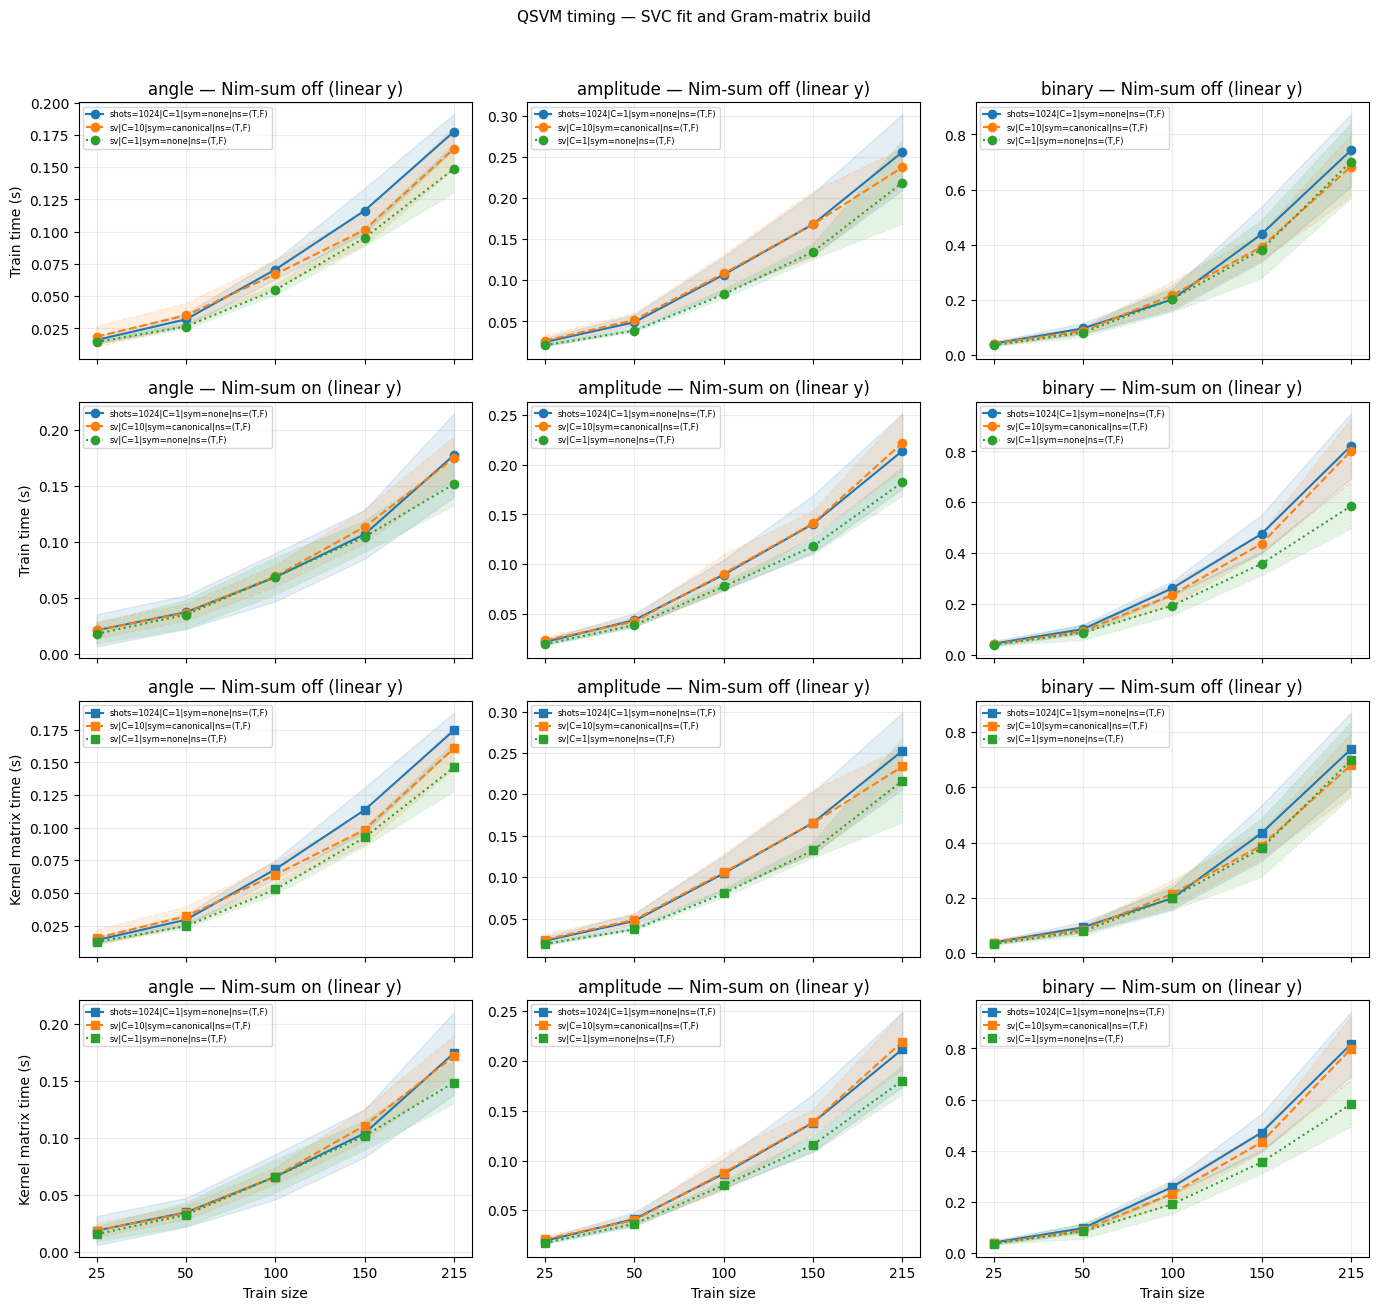

In [ ]:
plot_qsvm_train_and_kernel_time_curves(qsvm_summary)

**Figure 6.5:** Balanced accuracy at the **largest** training size in the summary, with encodings on the horizontal axis. Two panels separate Nim-sum off vs on; within each panel, grouped bars are `variant_id` (all three slices sweep both Nim-sum levels).

Largest train size only; left = Nim-sum off, right = Nim-sum on. Empty slots are missing `(variant_id, encoding, include_nim_sum)` rows at full $n$ after aggregation.

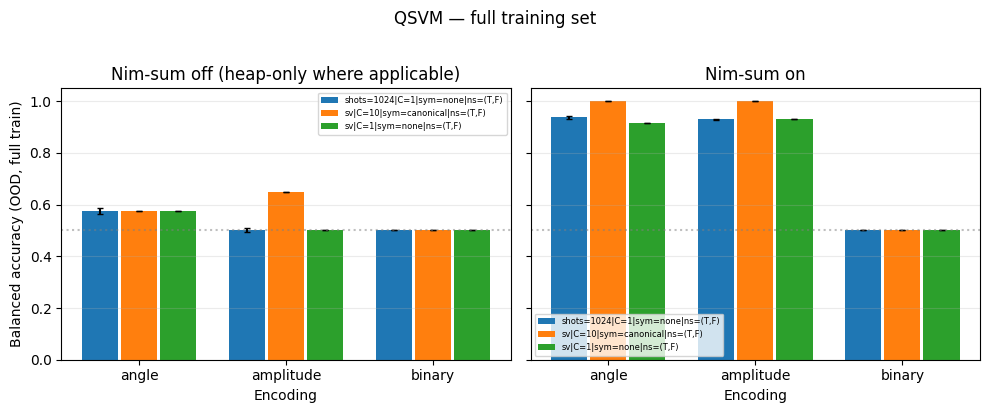

In [ ]:
plot_qsvm_full_train_balanced_accuracy_bars(qsvm_summary)

## 7. Quantum Selection

Section 7 picks **one winner per quantum pipeline** (VQC and QSVM) so both
families can be carried forward to device inference. It consumes
`vqc_workflow_df` (Section 5) and `qsvm_workflow_df` (Section 6), aligns the
grouping granularity across pipelines (encoding is a selection key for
both), runs the Pareto-accuracy-vs-cost policy at the deploy-time
`train_size`, and emits:

- `quantum_winners: dict[str, Winner]` — one winner per pipeline key.
- `quantum_winner_rows_by_pipeline: dict[str, pd.DataFrame]` — the upstream
  rows matching each winner, preserving **all** `train_size` values so
  Sections 9 and 11 can plot learning curves.
- `winner` (from Section 7.2) — the overall Pareto-top ``Winner`` across the two
  pipelines.

Rationale: VQC's `config_id` already pins encoding while QSVM's
`variant_id` did not, so the earlier single-pipeline aggregate silently
averaged QSVM's strongest encoding (amplitude) with its degenerate ones.

### 7.1 Cost annotation

Attach the canonical cost columns (`total_shots_estimate`, etc.) so the
selection policy has a cost axis.

In [ ]:
vqc_with_cost = (
    add_cost_metric_contract_columns(
        vqc_workflow_df,
        pipeline="vqc",
    )
    if not vqc_workflow_df.empty
    else vqc_workflow_df
)
qsvm_with_cost = (
    add_cost_metric_contract_columns(
        qsvm_workflow_df,
        pipeline="qsvm",
        balanced_accuracy_col="balanced_accuracy",
    )
    if not qsvm_workflow_df.empty
    else qsvm_workflow_df
)

### 7.2 Pareto selection

The selection policy is implemented in ``qml_project.pareto_selection``;
the steps are documented here for the report:

1. For each pipeline, aggregate per **full selection key**:
   - VQC: `config_id` (already encodes `encoding|ansatz|depth|cz`); ``include_nim_sum``
     is merged onto each row from the VQC workflow so ``selection_table`` exposes it.
   - QSVM: `(variant_id, encoding, include_nim_sum)` so QSVM's encoding is a selection
     dimension at parity with VQC (previously it was averaged away).
2. Filter to `train_size == max(train_size)` before aggregation — the
   **deploy-time** training budget. All `train_size` values are still kept
   in the per-run frames so Sections 9 and 11 can plot learning curves.
3. Aggregate mean/std of balanced accuracy and mean of the cost axis
   (measured `training_time_s`).
4. Compute the global Pareto front on (maximise accuracy, minimise cost);
   NaN cost is treated as "cost-unknown" and retained. This drives the
   `pareto` flag on `selection_table` and the overall ``winner`` (Pareto-top
   across all pipelines combined).
5. Pick a **per-pipeline winner** = Pareto-top within each pipeline's
   **own** per-pipeline Pareto front, sorted by mean accuracy desc then
   std accuracy asc (stability tie-break). The per-pipeline front is
   computed independently of the global front, so a pipeline that is
   globally dominated (e.g. VQC vs a much stronger QSVM) still yields a
   winner — Sections 9–11 need both families to have something to carry
   forward to device inference.

In [ ]:
_sel = build_pareto_quantum_selection(
    vqc_with_cost,
    qsvm_with_cost,
    accuracy_col="balanced_accuracy",
    cost_col="training_time_s",
    vqc_group_cols=["config_id"],
    qsvm_group_cols=["variant_id", "encoding", "include_nim_sum"],
    preferred_pipeline=None,
)
selection_table = _sel.selection_table
quantum_winners = _sel.quantum_winners
winner = _sel.winner

for _pipeline, _w in quantum_winners.items():
    print(
        f"Winner[{_pipeline}]: config_id={_w.config_id}\n"
        f"  encoding={_w.encoding} train_size_used={_w.train_size_used}\n"
        f"  mean_accuracy={_w.mean_accuracy:.4f} std={_w.std_accuracy:.4f} "
        f"mean_cost={_w.mean_cost}"
    )
print(
    f"Overall top winner: pipeline={winner.pipeline} "
    f"config_id={winner.config_id}"
)

display(
    selection_table.sort_values(
        ["pipeline", "mean_accuracy", "std_accuracy"],
        ascending=[True, False, True],
    )
    .drop(columns=["group_cols"], errors="ignore")
    .round(4)
    .reset_index(drop=True)
)

Winner[qsvm]: config_id=sv|C=10|sym=canonical|ns=(T,F)|angle|True
  encoding=angle train_size_used=215
  mean_accuracy=1.0000 std=0.0000 mean_cost=0.17445270349999192
Winner[vqc]: config_id=angle|basic_block|d=4|cz=linear|ns=T
  encoding=angle train_size_used=215
  mean_accuracy=0.9500 std=0.0574 mean_cost=157.4084964711
Overall top winner: pipeline=qsvm config_id=sv|C=10|sym=canonical|ns=(T,F)|angle|True


,config_id,mean_accuracy,std_accuracy,n_runs,mean_cost,pipeline,train_size_used,selection_id,encoding,include_nim_sum,variant_id,pareto,winner
0,NaN,1.0000,0.0000,10,0.2221,qsvm,215,"sv|C=10|sym=canonical|ns=(T,F)|amplitude|True",amplitude,True,"sv|C=10|sym=canonical|ns=(T,F)",False,False
1,NaN,1.0000,0.0000,10,0.1745,qsvm,215,"sv|C=10|sym=canonical|ns=(T,F)|angle|True",angle,True,"sv|C=10|sym=canonical|ns=(T,F)",True,True
2,NaN,0.9377,0.0071,10,0.1773,qsvm,215,"shots=1024|C=1|sym=none|ns=(T,F)|angle|True",angle,True,"shots=1024|C=1|sym=none|ns=(T,F)",False,False
3,NaN,0.9308,0.0000,10,0.1825,qsvm,215,"sv|C=1|sym=none|ns=(T,F)|amplitude|True",amplitude,True,"sv|C=1|sym=none|ns=(T,F)",False,False
4,NaN,0.9296,0.0021,10,0.2141,qsvm,215,"shots=1024|C=1|sym=none|ns=(T,F)|amplitude|True",amplitude,True,"shots=1024|C=1|sym=none|ns=(T,F)",False,False
5,NaN,0.9173,0.0000,10,0.1515,qsvm,215,"sv|C=1|sym=none|ns=(T,F)|angle|True",angle,True,"sv|C=1|sym=none|ns=(T,F)",True,False
6,NaN,0.6487,0.0000,10,0.2373,qsvm,215,"sv|C=10|sym=canonical|ns=(T,F)|amplitude|False",amplitude,False,"sv|C=10|sym=canonical|ns=(T,F)",False,False
7,NaN,0.5745,0.0118,10,0.1776,qsvm,215,"shots=1024|C=1|sym=none|ns=(T,F)|angle|False",angle,False,"shots=1024|C=1|sym=none|ns=(T,F)",False,False
8,NaN,0.5744,0.0000,10,0.1645,qsvm,215,"sv|C=10|sym=canonical|ns=(T,F)|angle|False",angle,False,"sv|C=10|sym=canonical|ns=(T,F)",False,False
9,NaN,0.5744,0.0000,10,0.1488,qsvm,215,"sv|C=1|sym=none|ns=(T,F)|angle|False",angle,False,"sv|C=1|sym=none|ns=(T,F)",True,False


**Figure 7.1:** Pareto plot — mean OOD balanced accuracy (y) vs mean
training time (x, seconds) at the deploy-time `train_size`. Dominated
configurations (grey circles), Pareto front (dark diamonds), and the
**per-pipeline winners** carried forward to Sections 08–11 are highlighted
(VQC triangle, QSVM star). Training time is the canonical cross-pipeline
cost axis; per-pipeline quantum-shot estimates are reported separately in
Sections 5/6.

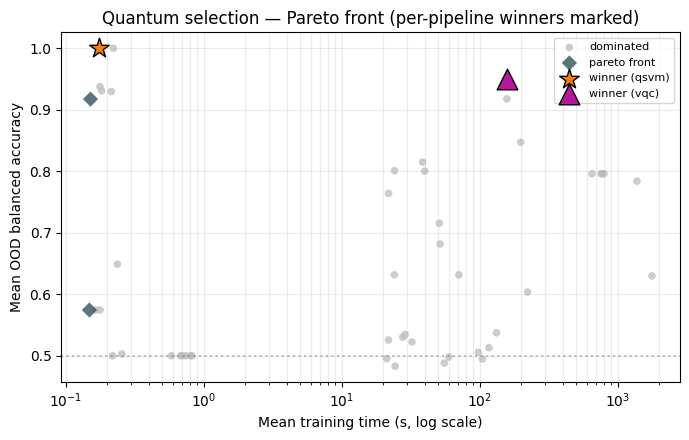

In [ ]:
_fig71 = plot_quantum_selection_pareto(selection_table, quantum_winners)
if _fig71 is not None:
    plt.show()

### 7.3 Winner artifacts

Downstream sections consume:

- `quantum_winners` — `dict[pipeline → Winner]` (one entry per pipeline).
- `quantum_winner_rows_by_pipeline` — `dict[pipeline → DataFrame]` of
  per-run rows matching each winner. **All `train_size` values are kept**
  so learning curves can be plotted in Sections 9 and 11.
- ``winner`` (from Section 7.2) — overall Pareto-top ``Winner``; row slices above are
  keyed per pipeline, not duplicated on this name.

In [ ]:
_winner_artifacts = build_quantum_winner_artifacts(
    quantum_winners,
    {"vqc": vqc_workflow_df, "qsvm": qsvm_workflow_df},
    winner,
)
quantum_winner_rows_by_pipeline = _winner_artifacts.quantum_winner_rows_by_pipeline

for _pipeline, _rows in quantum_winner_rows_by_pipeline.items():
    print(
        f"quantum_winner_rows_by_pipeline[{_pipeline!r}]: {len(_rows)} rows"
    )

_nim_demo_paths = export_nim_demo_quantum_selection_parquets(
    selection_table=selection_table,
    quantum_winner_rows_by_pipeline=quantum_winner_rows_by_pipeline,
    quantum_winners=quantum_winners,
    overall_winner=winner,
)
for _stem, _path in sorted(_nim_demo_paths.items()):
    print(f"nim_demo: wrote `{_path.name}` ({_stem})")

quantum_winner_rows_by_pipeline['qsvm']: 50 rows
quantum_winner_rows_by_pipeline['vqc']: 50 rows
nim_demo: wrote `quantum_winner_rows_qsvm.parquet` (quantum_winner_rows_qsvm)
nim_demo: wrote `quantum_winner_rows_vqc.parquet` (quantum_winner_rows_vqc)
nim_demo: wrote `quantum_winners_summary.parquet` (quantum_winners_summary)
nim_demo: wrote `selection_table.parquet` (selection_table)


### 7.4 MLflow selection log

One MLflow run per winner under `nim.selection.selection`, plus one run for
the overall Pareto-top. A `winner_scope` tag (`"vqc"`, `"qsvm"`, or
`"overall"`) lets you filter them in the MLflow UI.

In [ ]:
log_quantum_selection_winners_to_mlflow(quantum_winners, winner)

## 8. Pre-Device Validation

Section 8 runs the minimal readiness checklist on **each pipeline's winner**
chosen in Section 7 before committing to device inference in Section 10. For
every pipeline in `quantum_winners` it answers:

1. How many shots are needed to hit the target balanced accuracy?
2. Does readout-mitigation and ZNE materially improve noisy accuracy?
   (VQC only — QSVM mitigation is handled at kernel-estimator level.)
3. What is the per-sample cost snapshot (training time, inference latency,
   shot budget estimate)?

### 8.1 Winners from Section 7

Uses `quantum_winners`, `quantum_winner_rows_by_pipeline`, and overall
``winner`` from quantum selection (Section 7.2).

In [ ]:
for _pipeline, _w in quantum_winners.items():
    print(
        f"Validating winner[{_pipeline}]: config_id={_w.config_id} "
        f"encoding={_w.encoding}"
    )

winner_rows = quantum_winner_rows_by_pipeline[winner.pipeline].copy()

Validating winner[qsvm]: config_id=sv|C=10|sym=canonical|ns=(T,F)|angle|True encoding=angle
Validating winner[vqc]: config_id=angle|basic_block|d=4|cz=linear|ns=T encoding=angle


### 8.2 Shot schedule — shots to target balanced accuracy

For each winner, compute the minimum shot budget at which mean balanced
accuracy crosses a target threshold (0.8 by default). Only runs for
pipelines whose rows record a `shots` column (typically QSVM
`shot_binomial` variants).

In [ ]:
shot_target = 0.80
shots_table_by_pipeline: dict[str, pd.DataFrame] = {}

for _pipeline, _w in quantum_winners.items():
    _rows = quantum_winner_rows_by_pipeline[_pipeline].copy()
    if "shots" not in _rows.columns or _rows.empty:
        print(f"[{_pipeline}] (no 'shots' column — shot-schedule not applicable)")
        shots_table_by_pipeline[_pipeline] = pd.DataFrame()
        continue
    _group_cols = (
        ("config_id",)
        if "config_id" in _rows.columns
        else ("variant_id",)
    )
    _tbl = shots_to_target_balanced_accuracy(
        _rows,
        group_cols=_group_cols,
        target_balanced_accuracy=shot_target,
        shots_col="shots",
        balanced_accuracy_col="balanced_accuracy",
    )
    shots_table_by_pipeline[_pipeline] = _tbl
    print(f"[{_pipeline}] shots-to-target={shot_target} table:")
    display(_tbl.round(1))

[qsvm] shots-to-target=0.8 table:


,variant_id,shots_to_target_bal_acc
0,"sv|C=10|sym=canonical|ns=(T,F)",NaN


[vqc] (no 'shots' column — shot-schedule not applicable)


### 8.3 Mitigation preconditions (VQC winners only)

For VQC winners, the robustness frame from Section 5 reports raw / readout /
ZNE / readout+ZNE variants. These numbers decide which mitigation (if any)
is turned on during the device run. QSVM winners skip this section —
kernel-level mitigation lives inside the kernel estimator.

In [ ]:
robustness_df = vqc_robustness_df
mitigation_summary_by_pipeline: dict[str, pd.DataFrame] = {}

for _pipeline, _w in quantum_winners.items():
    if _pipeline != "vqc":
        print(f"[{_pipeline}] (not VQC — kernel-level mitigation only)")
        mitigation_summary_by_pipeline[_pipeline] = pd.DataFrame()
        continue
    if robustness_df.empty:
        print(f"[{_pipeline}] (vqc_robustness_df is empty)")
        mitigation_summary_by_pipeline[_pipeline] = pd.DataFrame()
        continue
    rob_winner = robustness_df.loc[
        robustness_df["config_id"] == _w.config_id
    ].copy()
    if rob_winner.empty:
        print(f"[{_pipeline}] (no robustness rows for config_id={_w.config_id})")
        mitigation_summary_by_pipeline[_pipeline] = pd.DataFrame()
        continue
    mit_summary = (
        rob_winner.groupby(["noise_level"])
        [[c for c in (
            "balanced_accuracy_raw",
            "balanced_accuracy_readout",
            "balanced_accuracy_zne",
            "balanced_accuracy_readout_zne",
        ) if c in rob_winner.columns]]
        .mean()
        .reset_index()
        .round(4)
    )
    mitigation_summary_by_pipeline[_pipeline] = mit_summary
    print(f"[{_pipeline}] mitigation summary:")
    display(mit_summary)

[qsvm] (not VQC — kernel-level mitigation only)
[vqc] mitigation summary:


,noise_level,balanced_accuracy_raw,balanced_accuracy_readout,balanced_accuracy_zne,balanced_accuracy_readout_zne
0,0.000,0.9826,0.9826,0.9826,0.9826
1,0.005,0.9867,0.9869,0.9876,0.9877
2,0.010,0.9709,0.9710,0.9723,0.9723
3,0.020,0.9723,0.9727,0.9758,0.9759


### 8.4 Cost snapshot

Canonical cost columns and mean/std summary per winner. Feeds directly
into Section 11 comparison.

In [ ]:
winner_cost_by_pipeline: dict[str, pd.DataFrame] = {}
winner_cost_summary_by_pipeline: dict[str, pd.DataFrame] = {}

for _pipeline, _w in quantum_winners.items():
    _rows = quantum_winner_rows_by_pipeline[_pipeline]
    _cost = add_cost_metric_contract_columns(
        _rows,
        pipeline=_pipeline,
        n_inference_samples=int(len(split.X_test)),
    )
    _summary = summarize_cost_performance(_cost, group_cols=("pipeline",))
    winner_cost_by_pipeline[_pipeline] = _cost
    winner_cost_summary_by_pipeline[_pipeline] = _summary
    print(f"[{_pipeline}] cost summary:")
    display(_summary.round(4))

[qsvm] cost summary:


,pipeline,balanced_accuracy_mean,balanced_accuracy_std,training_time_s_mean,training_time_s_std,per_sample_latency_ms_mean,per_sample_latency_ms_std,total_shots_estimate_mean,total_shots_estimate_std,cost_per_bal_acc_point_s_mean,cost_per_bal_acc_point_s_std
0,qsvm,0.9338,0.1334,0.0831,0.0573,0.8477,0.2091,NaN,NaN,0.0018,0.0011


[vqc] cost summary:


,pipeline,balanced_accuracy_mean,balanced_accuracy_std,training_time_s_mean,training_time_s_std,per_sample_latency_ms_mean,per_sample_latency_ms_std,total_shots_estimate_mean,total_shots_estimate_std,cost_per_bal_acc_point_s_mean,cost_per_bal_acc_point_s_std
0,vqc,0.9486,0.053,80.0298,54.8748,4.2014,0.8324,NaN,NaN,1.8055,1.2289


### 8.5 Device refit

Refit each winner at the per-pipeline train-size lists in the code cell
below so Section 10 can submit a **device learning curve** rather than a
single anchor point. Each refit is pickled to
`.workflow_cache/{pipeline}_device_payload_n{size}.pkl` so the
`.venv-device` kernel can load the whole sweep without re-training.

Budgeting (see Section 10.2 for concrete costs):

- **VQC** inference cost is train-size independent (`N_test` circuits at
  every anchor), so VQC can afford more anchors — a good shape for a
  learning curve.
- **QSVM** inference cost is `N_test × |SV|` and `|SV|` grows roughly
  linearly with `train_size`. Keep the QSVM list modest (≤4 anchors)
  anchored at low train sizes to stay within the IBM Open Plan budget.
  At the current `(C=10, symmetry=canonical, amplitude)` winner the fitted
  `|SV|` was 6 at both 25 and 50, suggesting 100/150 will not inflate
  inference cost dramatically compared to 50.

In [ ]:
device_payloads_by_pipeline = run_device_refit_sweep_and_cache(
    quantum_winners=quantum_winners,
    quantum_winner_rows_by_pipeline=quantum_winner_rows_by_pipeline,
    split=split,
    train_sizes_by_pipeline={
        "vqc": [25, 50, 100, 150, 215],
        "qsvm": [25, 50, 100, 150],
    },
    shared_fallback_sizes=[25, 50, 100],
    refit_seed=0,
)

[qsvm] refit anchors: [25, 50, 100, 150]
[qsvm@n25] device refit → train_size=25 seed=0 balanced_accuracy=0.75 → cached qsvm_device_payload_n25.pkl
  |SV|=8 / train_size=25
[qsvm@n50] device refit → train_size=50 seed=0 balanced_accuracy=0.9538461538461538 → cached qsvm_device_payload_n50.pkl
  |SV|=9 / train_size=50
[qsvm@n100] device refit → train_size=100 seed=0 balanced_accuracy=0.9653846153846154 → cached qsvm_device_payload_n100.pkl
  |SV|=12 / train_size=100
[qsvm@n150] device refit → train_size=150 seed=0 balanced_accuracy=1.0 → cached qsvm_device_payload_n150.pkl
  |SV|=12 / train_size=150
[vqc] refit anchors: [25, 50, 100, 150, 215]
[vqc@n25] device refit → train_size=25 seed=0 balanced_accuracy=1.0 → cached vqc_device_payload_n25.pkl
[vqc@n50] device refit → train_size=50 seed=0 balanced_accuracy=1.0 → cached vqc_device_payload_n50.pkl
[vqc@n100] device refit → train_size=100 seed=0 balanced_accuracy=1.0 → cached vqc_device_payload_n100.pkl
[vqc@n150] device refit → train_si

### 8.6 Device readiness checklist

One row per pipeline. Sections 10 and 11 use this table to decide whether to
gate each winner's device submission separately.

In [ ]:
(
    device_readiness_by_pipeline,
    device_readiness,
    validation_by_pipeline,
) = build_device_readiness_bundle(
    quantum_winners=quantum_winners,
    quantum_winner_rows_by_pipeline=quantum_winner_rows_by_pipeline,
    shots_table_by_pipeline=shots_table_by_pipeline,
    mitigation_summary_by_pipeline=mitigation_summary_by_pipeline,
    winner_cost_summary_by_pipeline=winner_cost_summary_by_pipeline,
    overall_winner=winner,
)
display(pd.DataFrame(list(device_readiness_by_pipeline.values())))

,winner_pipeline,winner_config_id,winner_encoding,winner_train_size_used,winner_n_rows,shots_to_target_rows,mean_balanced_accuracy,std_balanced_accuracy,mean_cost_s
0,qsvm,"sv|C=10|sym=canonical|ns=(T,F)|angle|True",angle,215,50,1,1.00,0.000000,0.174453
1,vqc,angle|basic_block|d=4|cz=linear|ns=T,angle,215,50,0,0.95,0.057385,157.408496


## 9. Simulated Deep-Dive on the Quantum Winners

Section 9 is strictly figurative / narrative: learning curves, sample-
efficiency analysis, and power-law fits for **each pipeline's winner**
(VQC and QSVM), plus an overlay figure that pits both quantum families
against the classical baseline at low training budgets. No cross-pipeline
statistical tests — those belong to Section 11.

### 9.1 Targets from Section 7

Reuses `quantum_winners`, `quantum_winner_rows_by_pipeline`, and overall
``winner`` from Section 7.2.

In [ ]:
for _pipeline, _w in quantum_winners.items():
    print(f"Deep-dive target[{_pipeline}]: {_w.config_id} (encoding={_w.encoding})")

winner_rows = quantum_winner_rows_by_pipeline[winner.pipeline].copy()

Deep-dive target[qsvm]: sv|C=10|sym=canonical|ns=(T,F)|angle|True (encoding=angle)
Deep-dive target[vqc]: angle|basic_block|d=4|cz=linear|ns=T (encoding=angle)


### 9.2 Learning curves per winner

Mean ± std of balanced accuracy, MCC, and win rate across seeds per
`train_size`, for each pipeline's winner. All `train_size` values are
preserved so the low-sample regime (the focal hypothesis) is visible.

In [ ]:
quantum_deep_dive_by_pipeline: dict[str, dict[str, Any]] = {}
for _pipeline, _w in quantum_winners.items():
    _rows = quantum_winner_rows_by_pipeline[_pipeline]
    _bal = learning_curve_mean_std_by_train_size(_rows, "balanced_accuracy")
    _mcc = learning_curve_mean_std_by_train_size(_rows, "mcc")
    _win = learning_curve_mean_std_by_train_size(_rows, "win_rate")
    quantum_deep_dive_by_pipeline[_pipeline] = {
        "winner": _w,
        "bal_curve": _bal,
        "mcc_curve": _mcc,
        "win_curve": _win,
    }
    print(f"[{_pipeline}] balanced-accuracy learning curve:")
    display(_bal.round(4))

[qsvm] balanced-accuracy learning curve:


,train_size,balanced_accuracy_mean,balanced_accuracy_std,n
0,25,0.7254,0.1793,10
1,50,0.9472,0.0449,10
2,100,0.9963,0.0109,10
3,150,1.0000,0.0000,10
4,215,1.0000,0.0000,10


[vqc] balanced-accuracy learning curve:


,train_size,balanced_accuracy_mean,balanced_accuracy_std,n
0,25,0.9415,0.0570,10
1,50,0.9560,0.0441,10
2,100,0.9477,0.0621,10
3,150,0.9479,0.0532,10
4,215,0.9500,0.0574,10


**Figure 9.1:** Balanced accuracy and win rate vs `train_size` for each
pipeline's winner.

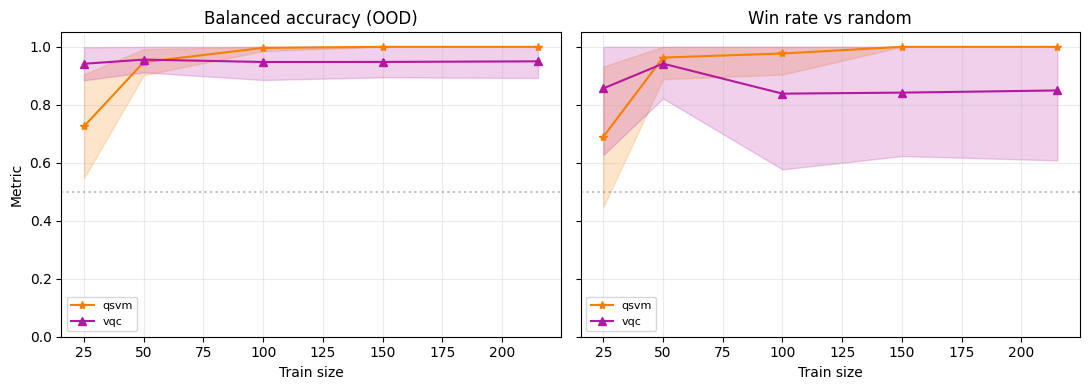

In [ ]:
if quantum_deep_dive_by_pipeline:
    _fig91 = plot_quantum_winner_two_metric_panels(
        quantum_deep_dive_by_pipeline,
        full_train_n=len(split.X_train),
    )
    if _fig91 is not None:
        plt.show()

### 9.3 Sample-efficiency overlay (hypothesis figure)

Balanced accuracy vs `train_size` for **each Section 7 quantum winner** together with
the **classical raw best** learning curve — the same `(model, symmetry)` rule
within `feature_set == "raw"` as Section 11 (`select_classical_winner_rows`), not a
mean over parity + raw + every model (which mixed incompatible baselines).

**What this figure is not:** per-pipeline quantum winners can still use
``include_nim_sum=True`` (Nim-sum feature channel in the circuit). That is more
information than three raw heaps alone, so the overlay is **not** a fully
controlled "heap-only quantum vs raw classical" comparison; Section 11 Table 2 adds
``sim_quantum_*_heap_only`` curves for that Tier A alignment.

Section 9.3 classical overlay: classical raw best → {'feature_set': 'raw', 'model': 'SVM (RBF)', 'symmetry': 'canonical', 'selection_mean_balanced_accuracy': 0.5902820512820512, 'n_rows': 50}


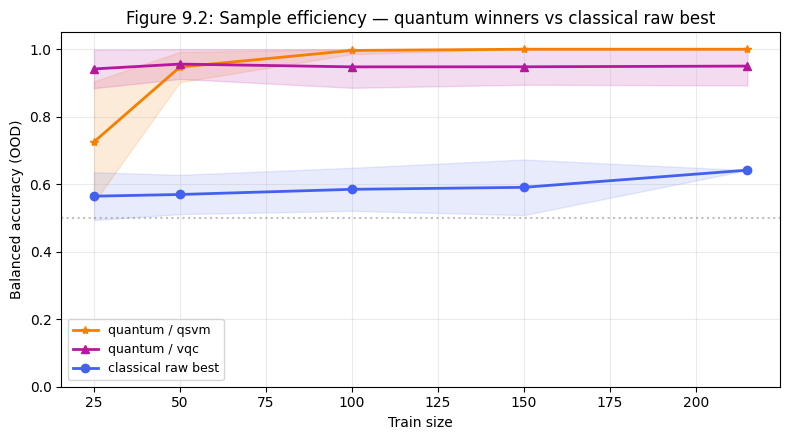

In [ ]:
_cls_main = classical_df.loc[classical_df["sub_study"] == "main"].copy()
_raw_overlay_rows, classical_overlay_raw_best_info = select_classical_winner_rows(
    _cls_main,
    feature_set="raw",
)
if not _raw_overlay_rows.empty:
    classical_curve = learning_curve_mean_std_by_train_size(
        _raw_overlay_rows,
        "balanced_accuracy",
    )
    _classical_overlay_label = "classical raw best"
else:
    classical_curve = learning_curve_mean_std_by_train_size(
        _cls_main,
        "balanced_accuracy",
    )
    _classical_overlay_label = "classical pool (fallback)"
print(f"Section 9.3 classical overlay: {_classical_overlay_label} → {classical_overlay_raw_best_info}")

if quantum_deep_dive_by_pipeline:
    _fig92 = plot_quantum_vs_classical_balanced_accuracy_overlay(
        quantum_deep_dive_by_pipeline,
        classical_curve,
        full_train_n=len(split.X_train),
        classical_label=_classical_overlay_label,
    )
    if _fig92 is not None:
        plt.show()

### 9.4 Power-law fits (sample efficiency, per pipeline)

Fits `balanced_accuracy ≈ a − b · train_size^(−c)` for each pipeline's
learning curve. Larger `c` = steeper improvement with more data.

In [ ]:
power_law_fits: dict[str, dict[str, float] | None] = {}
for _pipeline, _bundle in quantum_deep_dive_by_pipeline.items():
    curve = _bundle["bal_curve"]
    try:
        fit = power_law_fit_from_learning_curve_dataframe(
            curve,
            metric_col="balanced_accuracy_mean",
            full_train_n=len(split.X_train),
        )
        if fit is None:
            print(f"[{_pipeline}] (need ≥3 distinct train sizes for power-law fit)")
        else:
            print(f"[{_pipeline}] power-law fit:")
            display(pd.DataFrame([fit]).round(4))
        power_law_fits[_pipeline] = fit
    except Exception as exc:
        print(f"[{_pipeline}] (power-law fit skipped: {exc})")
        power_law_fits[_pipeline] = None

for _pipeline, _fit in power_law_fits.items():
    if _fit is not None:
        quantum_deep_dive_by_pipeline[_pipeline]["power_law_fit"] = _fit

[qsvm] power-law fit:


,a,b,c,r2
0,1.0521,10.0,1.0835,0.9519


[vqc] power-law fit:


,a,b,c,r2
0,0.9505,10.0,2.2389,0.4017


## 10. Quantum Device Inference

Training stays in simulation (Sections 3–9); this chapter runs **inference-only** jobs on IBM Quantum for the Section 7 winners.

**Scope:** device inference only for **each pipeline's winner** selected in
Section 7 (VQC and QSVM). This chapter does not repeat training or winner
selection from Sections 7–8, and it does not build the cross-pipeline
comparison in Section 11.

Each winner has its own `RUN_DEVICE_<pipeline>` flag so the two
submissions can be gated independently (queue times or free-tier budgets
may make it attractive to submit one, wait, then submit the other). The
per-pipeline circuit-cost estimate is always printed — so the gate is
always informed — even when submissions are disabled.

### 10.1 Winners from Section 7

Uses `quantum_winners` and overall ``winner`` from quantum selection (Section 7.2).

In [ ]:
for _pipeline, _w in quantum_winners.items():
    print(
        f"Device target[{_pipeline}]: config_id={_w.config_id} "
        f"encoding={_w.encoding}"
    )

Device target[qsvm]: config_id=sv|C=10|sym=canonical|ns=(T,F)|angle|True encoding=angle
Device target[vqc]: config_id=angle|basic_block|d=4|cz=linear|ns=T encoding=angle


### 10.2 Per-winner circuit-cost estimate

For each winner we estimate the inference-time circuit and shot budget:

- **VQC:** one parameterised circuit per test state → `N_test` circuits,
  each run with `DEVICE_SHOTS` shots → `N_test × DEVICE_SHOTS` total shots.
- **QSVM:** kernel inference requires one overlap circuit per
  `(test_state, support_vector)` pair → `N_test × |SV|` circuits. We cap
  `|SV|` optimistically at the training size; the true `|SV|` after fit
  is ≤ train_size. Check the validation table from Section 8 for the
  fitted bound.

The numbers below should be used to decide each pipeline's `RUN_DEVICE_*` gates
flag. Free-tier IBM Open Plan is generous for the VQC case; QSVM can push
into tens of thousands of circuits and may need the free-tier job cap
handled manually.

In [ ]:
DEVICE_SHOTS = 1024
DEVICE_SUBSET_TARGET = 40

n_test = int(min(len(split.X_test), DEVICE_SUBSET_TARGET))

device_cost_estimates = build_device_cost_estimates_dataframe(
    quantum_winners=quantum_winners,
    device_payloads_by_pipeline=device_payloads_by_pipeline,
    n_test_samples=n_test,
    shots_per_circuit=int(DEVICE_SHOTS),
)
display(device_cost_estimates)

if not device_cost_estimates.empty and any(
    device_cost_estimates["cost_source"].str.startswith("winner.train_size_used")
):
    print(
        "NOTE: at least one row is estimated from Winner.train_size_used "
        "(no device payload loaded from .workflow_cache/). Run Section 8 "
        "Section 8.5 (device refit) to populate "
        "{vqc,qsvm}_device_payload_n{size}.pkl, then rerun this cell for "
        "the true refit-based cost."
    )

_vqc_total_circuits, _qsvm_total_circuits = sum_device_cost_circuits_by_pipeline(
    device_cost_estimates
)
print(
    f"Summed circuit budget across all train sizes: "
    f"VQC={_vqc_total_circuits}, QSVM={_qsvm_total_circuits}."
)

,pipeline,config_id,encoding,target_train_size,n_test_samples,selection_train_size,refit_train_size,fitted_sv,shots_per_circuit,circuits,total_shots_upper_bound,cost_source
0,qsvm,"sv|C=10|sym=canonical|ns=(T,F)|angle|True",angle,25,40,215,25,8.0,1024,320,327680,payload (refit)
1,qsvm,"sv|C=10|sym=canonical|ns=(T,F)|angle|True",angle,50,40,215,50,9.0,1024,360,368640,payload (refit)
2,qsvm,"sv|C=10|sym=canonical|ns=(T,F)|angle|True",angle,100,40,215,100,12.0,1024,480,491520,payload (refit)
3,qsvm,"sv|C=10|sym=canonical|ns=(T,F)|angle|True",angle,150,40,215,150,12.0,1024,480,491520,payload (refit)
4,vqc,angle|basic_block|d=4|cz=linear|ns=T,angle,25,40,215,25,NaN,1024,40,40960,payload (refit)
5,vqc,angle|basic_block|d=4|cz=linear|ns=T,angle,50,40,215,50,NaN,1024,40,40960,payload (refit)
6,vqc,angle|basic_block|d=4|cz=linear|ns=T,angle,100,40,215,100,NaN,1024,40,40960,payload (refit)
7,vqc,angle|basic_block|d=4|cz=linear|ns=T,angle,150,40,215,150,NaN,1024,40,40960,payload (refit)
8,vqc,angle|basic_block|d=4|cz=linear|ns=T,angle,215,40,215,215,NaN,1024,40,40960,payload (refit)


Summed circuit budget across all train sizes: VQC=200, QSVM=1640.


### 10.3 Per-winner device gates

Toggle each `RUN_DEVICE_<pipeline>` independently. When a flag is `False`,
Section 10.4 does **not** submit to IBM Runtime, but it still loads **valid**
`{pipeline}_device_result_n<size>.pkl` files from `.workflow_cache/` when
present and rebuilds `device_results_by_pipeline` / `device_df` so Section 11
and the demo stay consistent. With no matching pickles, device frames are
empty and Section 11 falls back to classical × simulated quantum only.

In [ ]:
RUN_DEVICE_VQC = True
RUN_DEVICE_QSVM = True

### 10.4 Device inference per winner (train-size sweep)

Each enabled pipeline submits its winner at **every** `train_size`
present in `device_payloads_by_pipeline[pipeline]` (populated by Section 8
Section 8.5). Pub construction, Runtime submission, disk-cache IO, and aggregation
into ``device_results_by_pipeline`` / ``device_df`` are implemented in
:func:`~qml_project.device_inference.run_device_inference_result_sweep`
(see ``qml_project.device_inference.result_sweep``).

- **VQC** → one batched pub per train size (`N_test` samples ×
  `DEVICE_SHOTS` shots each).
- **QSVM** → one overlap pub per `(test_state, support_vector)` pair;
  submission is split into chunks of 100 overlap pubs per Runtime job
  (``qsvm_pubs_per_job`` in the call below) to stay inside the free-tier
  max-pubs limit.

Results are written one per `(pipeline, train_size)` to
`.workflow_cache/{pipeline}_device_result_n{size}.pkl` and aggregated
into a single per-pipeline DataFrame (`device_results_by_pipeline`) with
a `train_size` column, so Section 11 can build the device learning curve.

With ``reuse_cached_device_results=True`` (default in the call below), a
matching on-disk pickle skips new submissions. Set
``force_rerun_device_inference=True`` there to skip **reading** those pickles
only; successful device runs still write pickles under ``.workflow_cache/``.

When `RUN_DEVICE_<pipeline>` is `False`, on-disk pickles are still read
(unless ``force_rerun_device_inference`` is true) so offline runs reproduce
Section 11 without credentials.

In [ ]:
(
    device_results_by_pipeline,
    device_job_ids,
    device_runtime_summaries,
    device_job_ids_by_size,
    device_runtime_summaries_by_size,
    device_df,
) = run_device_inference_result_sweep(
    quantum_winners=quantum_winners,
    device_payloads_by_pipeline=device_payloads_by_pipeline,
    split=split,
    n_test=n_test,
    device_shots=int(DEVICE_SHOTS),
    run_device_flags={"vqc": RUN_DEVICE_VQC, "qsvm": RUN_DEVICE_QSVM},
    qsvm_pubs_per_job=100,
    reuse_cached_device_results=True,
    force_rerun_device_inference=False,
)

[disk cache] loaded vqc n=100 (40 rows) from vqc_device_result_n100.pkl (dir=/home/gelbhart/projects/school/spring/qml/notebooks/.workflow_cache)
[disk cache] loaded vqc n=150 (40 rows) from vqc_device_result_n150.pkl (dir=/home/gelbhart/projects/school/spring/qml/notebooks/.workflow_cache)
[disk cache] loaded vqc n=215 (40 rows) from vqc_device_result_n215.pkl (dir=/home/gelbhart/projects/school/spring/qml/notebooks/.workflow_cache)
[disk cache] loaded vqc n=25 (40 rows) from vqc_device_result_n25.pkl (dir=/home/gelbhart/projects/school/spring/qml/notebooks/.workflow_cache)
[disk cache] loaded vqc n=50 (40 rows) from vqc_device_result_n50.pkl (dir=/home/gelbhart/projects/school/spring/qml/notebooks/.workflow_cache)
[disk cache] loaded qsvm n=100 (40 rows) from qsvm_device_result_n100.pkl (dir=/home/gelbhart/projects/school/spring/qml/notebooks/.workflow_cache)
[disk cache] loaded qsvm n=150 (40 rows) from qsvm_device_result_n150.pkl (dir=/home/gelbhart/projects/school/spring/qml/noteb

### 10.5 MLflow device log

One MLflow run per `(pipeline, train_size)` so the device learning curve
is filterable by anchor.

In [ ]:
for _pipeline_tag, _df in device_results_by_pipeline.items():
    if _df.empty or "train_size" not in _df.columns:
        continue
    _w = quantum_winners[_pipeline_tag]
    for _size, _size_df in _df.groupby("train_size"):
        if _size_df.empty:
            continue
        try:
            import mlflow

            mlflow.set_experiment(resolve_experiment("device", "inference"))
            _size_int = int(_size)
            with mlflow.start_run(
                run_name=f"device|{_pipeline_tag}|n{_size_int}|{_w.config_id}"
            ):
                _job_id = device_job_ids_by_size.get(_pipeline_tag, {}).get(
                    _size_int
                ) or device_job_ids.get(_pipeline_tag)
                mlflow.set_tags(
                    {
                        "pipeline": "device",
                        "stage": "inference",
                        "winner_pipeline": _w.pipeline,
                        "winner_config_id": _w.config_id,
                        "winner_encoding": _w.encoding or "",
                        "train_size": str(_size_int),
                        **({"job_id": str(_job_id)} if _job_id else {}),
                    }
                )
                if "balanced_accuracy" in _size_df.columns:
                    mlflow.log_metric(
                        "device_balanced_accuracy",
                        float(
                            pd.to_numeric(
                                _size_df["balanced_accuracy"], errors="coerce"
                            ).mean()
                        ),
                    )
                if "n_test" in _size_df.columns:
                    mlflow.log_metric(
                        "device_n_test",
                        float(pd.to_numeric(_size_df["n_test"], errors="coerce").max()),
                    )
                _summary = device_runtime_summaries_by_size.get(
                    _pipeline_tag, {}
                ).get(_size_int) or {}
                if _summary.get("quantum_seconds") is not None:
                    try:
                        mlflow.log_metric(
                            "device_quantum_seconds",
                            float(_summary["quantum_seconds"]),
                        )
                    except (TypeError, ValueError):
                        pass
                if _summary.get("backend_name"):
                    mlflow.set_tag("backend_name", str(_summary["backend_name"]))
                mlflow.log_param("device_shots", int(DEVICE_SHOTS))
                mlflow.log_param("train_size", _size_int)
        except Exception as exc:
            print(
                f"(MLflow device log skipped for {_pipeline_tag}@n{_size}: {exc})"
            )

## 11. Final Comparison — Classical × Simulated-Quantum (VQC + QSVM) × Device

Device results from Section 10 are merged here with classical sweeps and simulated quantum winners.

Section 11 is the sole owner of the cross-pipeline comparison. Because the
Section 3 classical sweep enumerates `model × feature_set × symmetry × seed`,
a single pooled "classical" mean conflates three different baselines that
test **different hypotheses**. Section 11 therefore exposes **three classical
series** against the quantum winners and device runs:

- **`classical_raw_best`** — best (model, symmetry) combo selected within
  `feature_set == "raw"`, 10 seeds per `train_size`. This is the
  like-for-like baseline for a "quantum advantage on raw features" claim
  (Tier A): both sides see normalised heaps, no hand-engineered XOR.
- **`classical_parity_best`** — best (model, symmetry) combo selected
  within `feature_set == "parity"`, 10 seeds per `train_size`. This is the
  classical ceiling when the Nim-sum / XOR rule is handed to the model as
  features (Tier B). QSVM must compete with this to claim quantum is
  meaningfully better than any classical approach.
- **`classical_pool`** — the pooled `sub_study == "main"` mean used in
  earlier drafts (3 models × 2 feature sets × 3 symmetries × 10 seeds =
  180 rows per size). Kept as a context trace so readers can see what the
  pooled comparator looked like; it should **not** be read as a single
  classical baseline.

Quantum and device series are unchanged:

- `sim_quantum_vqc` / `sim_quantum_qsvm` — winner configurations from Section 7.
- `device_quantum_<pipeline>` — per-winner device frames from Section 10.

Map to hypothesis tiers (fair-comparison claims):

| Claim being tested | Fair comparison |
|---|---|
| Quantum is more sample-efficient than classical **on raw features** | QSVM / VQC vs `classical_raw_best` |
| Quantum beats classical even when classical gets hand-engineered XOR features | QSVM / VQC vs `classical_parity_best` |
| The quantum feature map *recovers* XOR structure without being told the rule | QSVM on raw inputs vs `classical_parity_best` |

Outputs: long-format comparison frame, summary tables, paired Wilcoxon
tests, and figures for the final report.

### 11.1 Input summary

Logs row counts for `classical_df` (Section 3.8), simulated-quantum winner rows
(Section 7), and the concatenated device frame (Section 10).

In [ ]:
print(
    f"classical_df: {len(classical_df)} rows; "
    + ", ".join(
        f"sim_quantum_{_p}: {len(_r)} rows"
        for _p, _r in quantum_winner_rows_by_pipeline.items()
    )
    + f"; device total: {len(device_df)} rows"
)

classical_df: 1200 rows; sim_quantum_qsvm: 50 rows, sim_quantum_vqc: 50 rows; device total: 360 rows


### 11.2 Build comparison

Implementation lives in ``qml_project.training.final_three_way_comparison``;
the classical ``sub_study == "main"`` frame is split into three series before
the union:

1. **`classical_raw_best`** — within `feature_set == "raw"`, pick the
   single (model, symmetry) configuration whose mean balanced accuracy
   across all `train_size` values is highest. Take that configuration's
   per-seed rows (10 seeds per `train_size`). This mirrors how Section 7
   selects one winner per quantum pipeline.
2. **`classical_parity_best`** — same selection rule, but within
   `feature_set == "parity"`.
3. **`classical_pool`** — the full pooled `sub_study == "main"` frame
   alongside the tier-specific classical slices for reference.

Quantum-winner and device frames are unchanged. All frames are coerced to
a common schema (`balanced_accuracy`, `win_rate`) and concatenated into
`comparison_long_df`. Missing `win_rate` columns are filled with `NaN` so
the downstream statistical tests skip them gracefully.

**Heap-only quantum (Section 12.1 Table 2):** before calling
``build_final_three_way_comparison``, merge
:func:`qml_project.training.final_three_way_comparison.build_paired_heap_only_quantum_workflow_rows`
into ``quantum_winner_rows_by_pipeline``. That adds workflow slices labelled
``qsvm_heap_only`` / ``vqc_heap_only``, which become pipelines
``sim_quantum_qsvm_heap_only`` and ``sim_quantum_vqc_heap_only`` in
``comparison_train_size_summary`` (same ``(variant_id, encoding)`` as the
QSVM winner with ``include_nim_sum=False``, and the VQC winner's ``config_id``
with ``|ns=F``). Empty slices are dropped from the long frame.

In [ ]:
_paired_heap_only_rows = build_paired_heap_only_quantum_workflow_rows(
    quantum_winners,
    qsvm_workflow_df=qsvm_workflow_df,
    vqc_workflow_df=vqc_workflow_df,
)
_quantum_winner_rows_for_comparison = {
    **quantum_winner_rows_by_pipeline,
    **_paired_heap_only_rows,
}
print(
    "quantum rows for Section 11 comparison (winner + heap-only paired slices):\n  "
    + "\n  ".join(
        f"{_k}: {len(_v)} rows" for _k, _v in sorted(_quantum_winner_rows_for_comparison.items())
    )
)
_cmp_bundle = build_final_three_way_comparison(
    classical_df,
    quantum_winner_rows_by_pipeline=_quantum_winner_rows_for_comparison,
    device_results_by_pipeline=device_results_by_pipeline,
    device_df=device_df,
    n_inference_samples_test_set=len(split.X_test),
    cmp_alpha=0.05,
)
classical_raw_best_rows = _cmp_bundle.classical_raw_best_rows
classical_raw_best_info = _cmp_bundle.classical_raw_best_info
classical_parity_best_rows = _cmp_bundle.classical_parity_best_rows
classical_parity_best_info = _cmp_bundle.classical_parity_best_info
comparison_long_df = _cmp_bundle.comparison_long_df
comparison_cost_summary = _cmp_bundle.comparison_cost_summary
comparison_stat_tests = _cmp_bundle.comparison_stat_tests
comparison_train_size_summary = _cmp_bundle.comparison_train_size_summary

print(
    "classical winners per feature_set:\n"
    f"  raw    → {classical_raw_best_info}\n"
    f"  parity → {classical_parity_best_info}"
)

quantum rows for Section 11 comparison (winner + heap-only paired slices):
  qsvm: 50 rows
  qsvm_heap_only: 50 rows
  vqc: 50 rows
  vqc_heap_only: 50 rows
classical winners per feature_set:
  raw    → {'feature_set': 'raw', 'model': 'SVM (RBF)', 'symmetry': 'canonical', 'selection_mean_balanced_accuracy': 0.5902820512820512, 'n_rows': 50}
  parity → {'feature_set': 'parity', 'model': 'Logistic Regression', 'symmetry': 'augmented', 'selection_mean_balanced_accuracy': 0.9863461538461539, 'n_rows': 50}


### 11.3 Cost summary

In [ ]:
display(comparison_cost_summary.round(4))

,pipeline,balanced_accuracy_mean,balanced_accuracy_std,training_time_s_mean,training_time_s_std,per_sample_latency_ms_mean,per_sample_latency_ms_std,total_shots_estimate_mean,total_shots_estimate_std,cost_per_bal_acc_point_s_mean,cost_per_bal_acc_point_s_std
0,classical_parity_best,0.9863,0.0731,0.0498,0.0238,0.0009,0.0008,NaN,NaN,0.0010,0.0005
1,classical_pool,0.6853,0.1978,0.0403,0.0386,0.0054,0.0061,NaN,NaN,0.0105,0.0553
2,classical_raw_best,0.5903,0.0656,0.0016,0.0004,0.0023,0.0013,NaN,NaN,0.0006,0.0025
3,device_quantum_qsvm,0.5526,0.1224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,device_quantum_vqc,0.9842,0.0129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,sim_quantum_qsvm,0.9338,0.1334,0.0831,0.0573,0.8477,0.2091,NaN,NaN,0.0018,0.0011
6,sim_quantum_qsvm_heap_only,0.6039,0.0775,0.0774,0.0537,0.7460,0.1882,NaN,NaN,0.0158,0.0401
7,sim_quantum_vqc,0.9486,0.0530,80.0298,54.8748,4.2014,0.8324,NaN,NaN,1.8055,1.2289
8,sim_quantum_vqc_heap_only,0.4943,0.0257,58.3135,34.5693,4.3314,0.5274,NaN,NaN,144.7498,171.4474


### 11.4 Per-(pipeline, train_size) summary

In [ ]:
display(comparison_train_size_summary.round(4))

,pipeline,train_size,metric,mean,std,n
0,classical_parity_best,25.0,balanced_accuracy,0.9335,0.1586,10
1,classical_parity_best,50.0,balanced_accuracy,0.9983,0.0055,10
2,classical_parity_best,100.0,balanced_accuracy,1.0000,0.0000,10
3,classical_parity_best,150.0,balanced_accuracy,1.0000,0.0000,10
4,classical_parity_best,215.0,balanced_accuracy,1.0000,0.0000,10
...,...,...,...,...,...,...
74,sim_quantum_vqc_heap_only,25.0,win_rate,0.4845,0.0388,10
75,sim_quantum_vqc_heap_only,50.0,win_rate,0.5100,0.0692,10
76,sim_quantum_vqc_heap_only,100.0,win_rate,0.4825,0.0443,10
77,sim_quantum_vqc_heap_only,150.0,win_rate,0.4855,0.0427,10


### 11.5 Simulated-vs-device delta

Device numbers come from a **single** seed (we budget one hardware
submission per anchor), while simulated numbers come from ``n_seeds=10``.
To surface the gap between noise-free simulation and noisy hardware for
each winner, this block pairs every device anchor with its matching
simulated-quantum anchor at the same ``train_size`` and tabulates the
difference. Big negative deltas (device ≪ sim) point at device-noise
degradation; deltas near zero support the "simulator matches hardware"
claim for that anchor.

In [ ]:
_sim_vs_device_rows = []
if not comparison_train_size_summary.empty:
    _bal = comparison_train_size_summary.loc[
        comparison_train_size_summary["metric"] == "balanced_accuracy"
    ]
    for _pipeline in ("vqc", "qsvm"):
        _sim_label = f"sim_quantum_{_pipeline}"
        _dev_label = f"device_quantum_{_pipeline}"
        _sim = _bal.loc[_bal["pipeline"] == _sim_label].set_index("train_size")
        _dev = _bal.loc[_bal["pipeline"] == _dev_label].set_index("train_size")
        if _sim.empty or _dev.empty:
            continue
        for _size in sorted(_dev.index.intersection(_sim.index)):
            _sim_mean = float(_sim.loc[_size, "mean"])
            _dev_mean = float(_dev.loc[_size, "mean"])
            _sim_vs_device_rows.append(
                {
                    "pipeline": _pipeline,
                    "train_size": float(_size),
                    "sim_mean": _sim_mean,
                    "sim_std": float(_sim.loc[_size, "std"]),
                    "sim_n": int(_sim.loc[_size, "n"]),
                    "device_mean": _dev_mean,
                    "device_n": int(_dev.loc[_size, "n"]),
                    "device_minus_sim": _dev_mean - _sim_mean,
                }
            )
sim_vs_device_delta = pd.DataFrame(_sim_vs_device_rows)
if not sim_vs_device_delta.empty:
    display(sim_vs_device_delta.round(4))
else:
    print("(no matching (sim, device) anchors to compare)")

,pipeline,train_size,sim_mean,sim_std,sim_n,device_mean,device_n,device_minus_sim
0,vqc,25.0,0.9415,0.0570,10,1.0000,40,0.0585
1,vqc,50.0,0.9560,0.0441,10,1.0000,40,0.0440
2,vqc,100.0,0.9477,0.0621,10,0.9737,40,0.0260
3,vqc,150.0,0.9479,0.0532,10,0.9737,40,0.0258
4,vqc,215.0,0.9500,0.0574,10,0.9737,40,0.0237
5,qsvm,25.0,0.7254,0.1793,10,0.3421,40,-0.3833
6,qsvm,50.0,0.9472,0.0449,10,0.6316,40,-0.3156
7,qsvm,100.0,0.9963,0.0109,10,0.6316,40,-0.3648
8,qsvm,150.0,1.0000,0.0000,10,0.6053,40,-0.3947


### 11.6 Paired statistical tests

In [ ]:
if not comparison_stat_tests.empty:
    display(comparison_stat_tests.round(4))
else:
    print("(no paired tests — insufficient overlap)")

,metric,family_scope,correction_method,family_id,n_tests_family,train_size,pipeline_a,pipeline_b,n_pairs,mean_a,std_a,mean_b,std_b,mean_delta_b_minus_a,wilcoxon_stat,p_value,p_value_bonferroni,reject_null_alpha,cohens_d_paired,rank_biserial
0,balanced_accuracy,cross_pipeline_fixed_train_size,bonferroni,train_size=25,21,25,classical_parity_best,classical_pool,10,0.9335,0.1505,0.6268,0.0513,-0.3066,0.0,0.0039,0.082,False,-2.6776,-1.0000
1,balanced_accuracy,cross_pipeline_fixed_train_size,bonferroni,train_size=25,21,25,classical_parity_best,classical_raw_best,10,0.9335,0.1505,0.5646,0.0672,-0.3689,0.0,0.0039,0.082,False,-2.5374,-1.0000
2,balanced_accuracy,cross_pipeline_fixed_train_size,bonferroni,train_size=25,21,25,classical_parity_best,sim_quantum_qsvm,10,0.9335,0.1505,0.7254,0.1701,-0.2081,0.0,0.0039,0.082,False,-1.3221,-1.0000
3,balanced_accuracy,cross_pipeline_fixed_train_size,bonferroni,train_size=25,21,25,classical_parity_best,sim_quantum_qsvm_heap_only,10,0.9335,0.1505,0.6092,0.1111,-0.3243,0.0,0.0039,0.082,False,-2.1409,-1.0000
4,balanced_accuracy,cross_pipeline_fixed_train_size,bonferroni,train_size=25,21,25,classical_parity_best,sim_quantum_vqc,10,0.9335,0.1505,0.9415,0.0541,0.0081,9.0,0.4375,1.000,False,0.0587,-0.4286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,win_rate,cross_pipeline_fixed_train_size,bonferroni,train_size=215,21,215,sim_quantum_qsvm,sim_quantum_vqc,10,1.0000,0.0000,0.8495,0.2288,-0.1505,0.0,0.0625,1.000,False,-0.6239,-1.0000
206,win_rate,cross_pipeline_fixed_train_size,bonferroni,train_size=215,21,215,sim_quantum_qsvm,sim_quantum_vqc_heap_only,10,1.0000,0.0000,0.4995,0.0556,-0.5005,0.0,0.0020,0.041,True,-8.5455,-1.0000
207,win_rate,cross_pipeline_fixed_train_size,bonferroni,train_size=215,21,215,sim_quantum_qsvm_heap_only,sim_quantum_vqc,10,0.7495,0.0298,0.8495,0.2288,0.1000,13.0,0.1543,1.000,False,0.4222,0.4000
208,win_rate,cross_pipeline_fixed_train_size,bonferroni,train_size=215,21,215,sim_quantum_qsvm_heap_only,sim_quantum_vqc_heap_only,10,0.7495,0.0298,0.4995,0.0556,-0.2500,0.0,0.0020,0.041,True,-4.5559,-1.0000


### 11.7 Summary figure

Balanced accuracy by train size and pipeline. Series:

- **`classical_raw_best`** (solid blue) — fair "quantum vs classical on
  raw features" comparator; this is the curve QSVM/VQC must beat to
  support the raw-feature sample-efficiency hypothesis.
- **`classical_parity_best`** (solid teal) — classical ceiling when the
  model is handed parity / bit-parity features. Close to saturation; the
  bar QSVM must clear to claim quantum beats classical *even when
  classical gets hand-engineered XOR features*.
- **`classical_pool`** (dashed grey, low alpha) — context-only pooled
  mean; hidden behind the other two and should not be read as a single
  classical baseline.
- **`sim_quantum_vqc` / `sim_quantum_qsvm`** — Section 7 winners, same
  palette as Sections 7/9.
- **`device_quantum_*`** — dashed device traces.

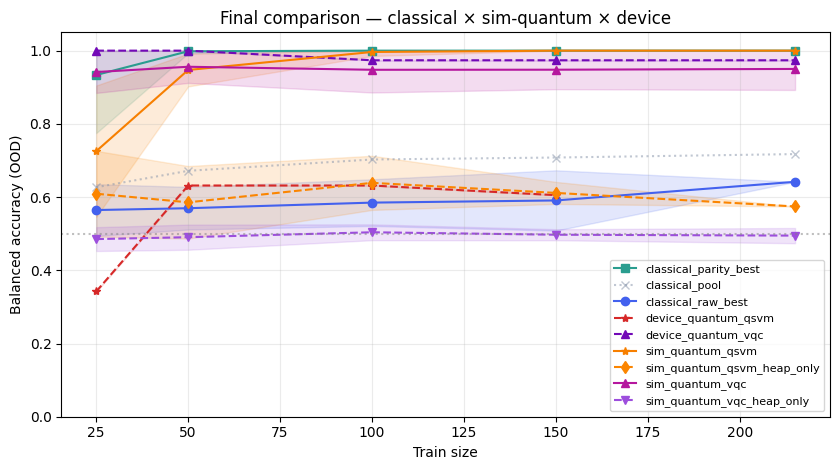

In [ ]:
if not comparison_train_size_summary.empty:
    _fig117 = plot_final_comparison_balanced_accuracy(comparison_train_size_summary)
    if _fig117 is not None:
        plt.show()

### 11.8 MLflow final log

One final-comparison run tagged with **every** winner's ids (joined with
`;`) plus per-winner metrics.

In [ ]:
try:
    import mlflow

    mlflow.set_experiment(resolve_experiment("final", "final"))
    with mlflow.start_run(run_name="final|three_way"):
        _winner_ids = {_p: _w.config_id for _p, _w in quantum_winners.items()}
        _winner_encodings = {
            _p: (_w.encoding or "") for _p, _w in quantum_winners.items()
        }
        mlflow.set_tags(
            {
                "pipeline": "final",
                "stage": "final",
                "winner_pipelines": ";".join(sorted(quantum_winners.keys())),
                "winner_config_ids": ";".join(
                    f"{_p}={_cid}" for _p, _cid in _winner_ids.items()
                ),
                "winner_encodings": ";".join(
                    f"{_p}={_enc}" for _p, _enc in _winner_encodings.items()
                ),
            }
        )
        if not comparison_train_size_summary.empty:
            agg = (
                comparison_train_size_summary.groupby("pipeline")["mean"]
                .mean()
                .to_dict()
            )
            for pipeline, val in agg.items():
                mlflow.log_metric(f"mean_balanced_accuracy_{pipeline}", float(val))
except Exception as exc:
    print(f"(MLflow final log skipped: {exc})")

## 12. Discussion

### 12.1 Hypothesis verdict

**Hypothesis (Section 2):** quantum learners carry a *sample-efficiency*
edge over classical baselines at low training sizes (`n <= 50`) on the
OOD split (`M <= 5` train / `M > 5` test), even if both families
saturate as `n` grows.

**Verdict: partly contradicted for the parity ceiling; mixed at `n = 25`.**
The tables in the next cell quote mean ± std **balanced accuracy** (10 seeds
per anchor where applicable) built directly from
``comparison_train_size_summary`` (Section 11.4, ``metric == balanced_accuracy``).

**Device vs simulator (`sim_vs_device_delta`):** hardware uses one submission per anchor; simulators use 10 seeds.

- **QSVM:** `device − sim` is strongly negative at every matched anchor in the saved run (e.g. −0.38 at `n = 25`, −0.32 at `n = 50`, −0.36 at `n = 100`, −0.39 at `n = 150`), consistent with overlap noise and finite-shot kernel estimation on hardware.
- **VQC:** the same snapshot shows **non-negative** `device − sim` for every matched anchor (up to about +0.06 at `n = 25`), so we **do not** describe this hardware run as chance-level relative to simulation; hardware point estimates can exceed simulation means when variance is dominated by a single job layout. We still treat device rows as **single-seed point estimates**, not a variance-matched comparison to simulation.

At `n >= 50`, the parity-feature classical baseline (see *Class imbalance and symmetry* above) still **matches or exceeds** both simulated quantum winners on mean balanced accuracy; the parity representation makes win/loss nearly linear, so logistic-style models saturate quickly. At `n = 25`, **QSVM** trails parity by a wide margin on mean, while **simulated VQC** sits slightly *above* parity on mean but parity has much higher seed variance (0.16 vs 0.06), so we do not treat that ordering as a clean quantum win without tighter CIs. The next cell prints **Table 1** (parity vs Section 7 winners); follow it with **Table 2** (raw vs heap-only quantum) and the short reading below.

In [ ]:
_table1_hv, _table2_hv = hypothesis_verdict_balanced_accuracy_tables(
    comparison_train_size_summary
)
print(
    "Table 1 — Parity classical vs Section 7 quantum winners "
    "(balanced accuracy, mean ± std)\n"
)
display(_table1_hv)
print(
    "\nTable 2 — Raw classical vs heap-only quantum "
    "(Tier A; N/A if Section 11 has no rows for that pipeline)\n"
)
display(_table2_hv)

Table 1 — Parity classical vs Section 7 quantum winners (balanced accuracy, mean ± std)



,n,classical_parity_best,sim_quantum_qsvm,sim_quantum_vqc
0,25,0.9335 ± 0.1586,0.7254 ± 0.1793,0.9415 ± 0.0570
1,50,0.9983 ± 0.0055,0.9472 ± 0.0449,0.9560 ± 0.0441
2,100,1.0000 ± 0.0000,0.9963 ± 0.0109,0.9477 ± 0.0621
3,150,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9479 ± 0.0532
4,215,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9500 ± 0.0574



Table 2 — Raw classical vs heap-only quantum (Tier A; N/A if Section 11 has no rows for that pipeline)



,n,classical_raw_best,sim_quantum_qsvm_heap_only,sim_quantum_vqc_heap_only
0,25,0.5646 ± 0.0708,0.6092 ± 0.1171,0.4852 ± 0.0326
1,50,0.5696 ± 0.0582,0.5856 ± 0.0991,0.4904 ± 0.0343
2,100,0.5849 ± 0.0637,0.6388 ± 0.0739,0.5038 ± 0.0216
3,150,0.5908 ± 0.0823,0.6113 ± 0.0301,0.4972 ± 0.0151
4,215,0.6417 ± 0.0000,0.5744 ± 0.0000,0.4947 ± 0.0208


**Reading Table 2 (Tier A, raw vs heap-only quantum).** In Table 2, `classical_raw_best` stays in roughly the mid-0.5s–0.64 band on balanced accuracy: raw normalised heaps do not expose the Nim-sum rule (Section 3). **`sim_quantum_qsvm_heap_only`** (same angle kernel family as the Section 7 QSVM winner but **without** the Nim-sum feature channel) lands in a **similar mean band** to `classical_raw_best` at low `n`, with overlapping seed spread—there is no obvious quantum sample-efficiency gap *versus this raw classical bar* once the explicit Nim-sum coordinate is removed. **`sim_quantum_vqc_heap_only`** (winner stem with `|ns=F`) sits near **0.49–0.50** mean balanced accuracy across anchors—close to chance on this OOD split—consistent with a heap-only angle VQC that does not recover XOR win/loss structure without the extra register. Together with Table 1, the picture is that **feature construction** (parity vs raw; Nim-sum channel on vs off) moves accuracy far more than swapping classical for quantum **within** a weak classical feature regime.


### 12.2 Interpretability

Earlier sections quantify cost, performance, and wall-clock speed; here we spell out how interpretability differs across the classical and quantum pipelines.

**Optimal rule vs representations.** Win/loss labels come from the **Nim-sum XOR rule** (Nim-sum $=0$ ⇔ losing). That rule is perfectly transparent on paper. **Parity-engineered classical features** (Section 3) expose XOR structure to linear models, so the Tier B classical ceiling is close to a *declarative* solution. **Raw normalised heaps** hide the rule: the Tier A ``classical_raw_best`` model is a standard sklearn predictor on three numbers—it is interpretable only *post hoc* via coefficients, importances, or permutation diagnostics. **QSVM** implements a margin classifier in a **quantum feature space** (Schuld & Killoran [18]): support vectors and kernel entries describe decisions as similarity weights, not as heap-wise rules—helpful for analysis, less legible than parity+LR. **VQC** exposes a **readout observable** (Pauli-$Z$ expectation or bitstring probabilities, depending on the winner config) as a continuous score; the Sections 5–7 encoding and ``include_nim_sum`` ablations are deliberate **controlled channels**—they state exactly what geometric information the circuit may use, which is the usual QML sense of interpretability when full SHAP-style attribution is too expensive.

**Cost / performance / speed / interpretability in one sentence:** cheaper classical parity features buy maximal interpretability *and* near-saturating accuracy; raw-feature classical and quantum models trade label transparency for the OOD generalisation stress test, and quantum methods pay extra circuit and wall-clock cost (Section 11) for implicit feature maps whose decisions we summarise numerically below.

Classical raw-best interpretability (model='SVM (RBF)', feature_set='raw', symmetry='canonical', train_size=215, seed=42):



,feature,importance_mean,importance_std,kind
0,h2_norm,0.155288,0.042012,permutation_importance
1,h1_norm,0.020691,0.037159,permutation_importance
2,h3_norm,-0.013640,0.007794,permutation_importance


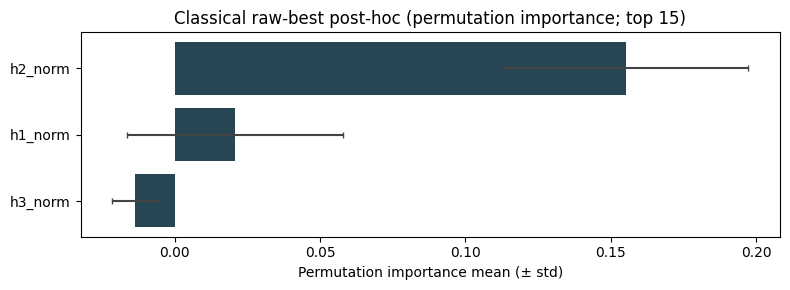

In [ ]:
# --- Classical raw-best post-hoc diagnostics (Section 11 Tier A) ---
_INTRP_SEED = 42
_intrp_train = int(
    quantum_winners["qsvm"].train_size_used
    if quantum_winners.get("qsvm") is not None
    and quantum_winners["qsvm"].train_size_used is not None
    else len(split.X_train)
)
_c_svc_intrp = (
    float(classical_raw_best_rows["c_svc"].dropna().iloc[0])
    if "c_svc" in classical_raw_best_rows.columns
    and classical_raw_best_rows["c_svc"].notna().any()
    else 1.0
)
_y_clf_intrp, _fitted_raw_best, _mn_intrp, _fs_intrp, _sym_intrp = (
    refit_classical_raw_best_predict_test(
        classical_raw_best_info,
        X_train_raw=split.X_train,
        y_train=split.y_train,
        X_test_raw=split.X_test,
        y_test=split.y_test,
        train_size=_intrp_train,
        seed=_INTRP_SEED,
        M=7,
        c_svc=_c_svc_intrp,
    )
)
if _sym_intrp == "canonical":
    _X_te_u, _ = canonical_order(np.asarray(split.X_test, dtype=np.int32))
else:
    _X_te_u = split.X_test
_X_te_feat_intrp = prepare_features(
    _X_te_u, cast(FeatureSet, _fs_intrp), M=7
)
_feat_names_intrp = classical_feature_names(
    feature_set=str(_fs_intrp), k=3, m_max=7
)
_classical_intrp_tbl = classical_posthoc_coefficients_or_importances(
    _fitted_raw_best,
    str(_mn_intrp),
    _X_te_feat_intrp,
    split.y_test,
    feature_names=_feat_names_intrp,
    random_state=_INTRP_SEED,
    perm_repeats=12,
)
print(
    "Classical raw-best interpretability "
    f"(model={_mn_intrp!r}, feature_set={_fs_intrp!r}, symmetry={_sym_intrp!r}, "
    f"train_size={_intrp_train}, seed={_INTRP_SEED}):\n"
)
display(_classical_intrp_tbl.head(20))

_intrp_top_k = 15
_intrp_plot_df = _classical_intrp_tbl.copy()
if "coefficient" in _intrp_plot_df.columns:
    _intrp_plot_df = (
        _intrp_plot_df.assign(_mag=_intrp_plot_df["coefficient"].abs())
        .nlargest(_intrp_top_k, "_mag")
        .iloc[::-1]
    )
    _intrp_vals = _intrp_plot_df["coefficient"].to_numpy(dtype=float)
    _intrp_err = None
    _intrp_xlabel = "Coefficient (signed)"
    _intrp_title_kind = "linear coefficients"
elif "importance_mean" in _intrp_plot_df.columns:
    _intrp_plot_df = _intrp_plot_df.head(_intrp_top_k).iloc[::-1]
    _intrp_vals = _intrp_plot_df["importance_mean"].to_numpy(dtype=float)
    _intrp_err = (
        _intrp_plot_df["importance_std"].to_numpy(dtype=float)
        if "importance_std" in _intrp_plot_df.columns
        else None
    )
    _intrp_xlabel = "Permutation importance mean (± std)"
    _intrp_title_kind = "permutation importance"
elif "importance" in _intrp_plot_df.columns:
    _intrp_plot_df = (
        _intrp_plot_df.nlargest(_intrp_top_k, "importance").iloc[::-1]
    )
    _intrp_vals = _intrp_plot_df["importance"].to_numpy(dtype=float)
    _intrp_err = None
    _intrp_xlabel = "Gini importance"
    _intrp_title_kind = "feature importances"
else:
    _intrp_plot_df = pd.DataFrame()
    _intrp_vals = np.array([], dtype=float)
    _intrp_err = None
    _intrp_xlabel = ""
    _intrp_title_kind = ""
if not _intrp_plot_df.empty:
    _fig_i, _ax_i = plt.subplots(figsize=(8, max(3.0, 0.35 * len(_intrp_plot_df))))
    _y_pos = np.arange(len(_intrp_plot_df))
    _ax_i.barh(
        _y_pos,
        _intrp_vals,
        xerr=_intrp_err,
        color="#264653",
        ecolor="#444444",
        capsize=2,
    )
    _ax_i.set_yticks(_y_pos)
    _ax_i.set_yticklabels(_intrp_plot_df["feature"].astype(str))
    _ax_i.set_xlabel(_intrp_xlabel)
    _ax_i.set_title(
        f"Classical raw-best post-hoc ({_intrp_title_kind}; top {_intrp_top_k})"
    )
    if "coefficient" in _classical_intrp_tbl.columns:
        _ax_i.axvline(0.0, color="#888888", linewidth=0.8, linestyle="--")
    plt.tight_layout()
    plt.show()

**Reading the post-hoc table and bar plot.** The Section 11 Tier A classical winner refits to **SVM (RBF)** on canonical raw features (`h*_norm` after sorting heaps ascending; `feature_set='raw'`, `symmetry='canonical'`) at `train_size = 215` and `seed = 42`. Because the RBF decision function is kernelised, `classical_posthoc_coefficients_or_importances` reports **permutation importance** rather than signed coefficients — only magnitudes are interpretable. The middle (canonical) slot `h2_norm` dominates at **0.155 ± 0.042**, an order of magnitude above `h1_norm` (**0.021 ± 0.037**) and `h3_norm` (**−0.014 ± 0.008**, indistinguishable from zero). A true Nim-sum classifier would treat all three slots symmetrically up to the canonical sort and would *not* concentrate predictive weight on one coordinate; the concentration on `h2_norm` is the signature of a generic RBF kernel exploiting just enough of the sorted geometry to clear the chance line without recovering XOR. *Caveat:* importance is computed post hoc on the test split with 12 permutation repeats at a single seed, so near-zero values should not be over-read.


Balanced accuracy vs test labels (labels = Nim-sum rule; train_size=215, seed=42). QSVM/VQC rows appear only if the one-shot refit succeeded.



,model,balanced_accuracy,n_test
0,classical_raw_best,0.641667,296
1,vqc,0.976923,296



Pairwise label disagreement rates on the same test rows:



,model_a,model_b,disagreement_rate,n_test
0,classical_raw_best,vqc,0.314189,296


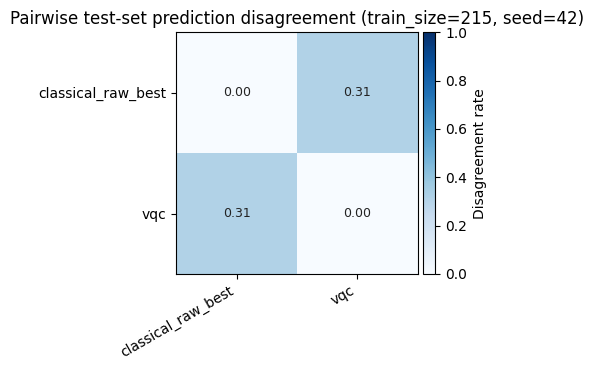

In [ ]:
# --- Test-set agreement: classical raw-best vs Section 7 quantum refits (single seed) ---
_q_intrp_preds = quantum_winners_test_predictions_interpretability(
    quantum_winners,
    qsvm_workflow_df,
    vqc_workflow_df,
    vqc_config_grid,
    X_train_raw=split.X_train,
    y_train=split.y_train,
    X_test_raw=split.X_test,
    y_test=split.y_test,
    train_size=_intrp_train,
    seed=_INTRP_SEED,
    M=7,
)
if not _q_intrp_preds:
    print(
        "(QSVM/VQC one-shot interpretability refit produced no predictions; "
        "disagreement summary is classical-only.)\n"
    )
_preds_bundle = {"classical_raw_best": _y_clf_intrp, **_q_intrp_preds}
_acc_intrp, _dis_intrp = summarize_interpretability_disagreements(
    split.y_test, _preds_bundle
)
print(
    "Balanced accuracy vs test labels (labels = Nim-sum rule; "
    f"train_size={_intrp_train}, seed={_INTRP_SEED}). "
    "QSVM/VQC rows appear only if the one-shot refit succeeded.\n"
)
display(_acc_intrp)
print("\nPairwise label disagreement rates on the same test rows:\n")
display(_dis_intrp)

if not _dis_intrp.empty and len(_acc_intrp) >= 2:
    _intrp_models = [str(m) for m in _acc_intrp["model"].tolist()]
    _n_m = len(_intrp_models)
    _intrp_dis_mat = np.zeros((_n_m, _n_m), dtype=float)
    _intrp_m_idx = {m: i for i, m in enumerate(_intrp_models)}
    for _, _r in _dis_intrp.iterrows():
        _ia = _intrp_m_idx[str(_r["model_a"])]
        _ib = _intrp_m_idx[str(_r["model_b"])]
        _v = float(_r["disagreement_rate"])
        _intrp_dis_mat[_ia, _ib] = _v
        _intrp_dis_mat[_ib, _ia] = _v
    _fig_d, _ax_d = plt.subplots(figsize=(max(4.5, 1.2 * _n_m), max(3.8, 1.0 * _n_m)))
    _im_d = _ax_d.imshow(_intrp_dis_mat, vmin=0.0, vmax=1.0, cmap="Blues")
    _ax_d.set_xticks(np.arange(_n_m))
    _ax_d.set_yticks(np.arange(_n_m))
    _ax_d.set_xticklabels(_intrp_models, rotation=30, ha="right")
    _ax_d.set_yticklabels(_intrp_models)
    for _ri in range(_n_m):
        for _ci in range(_n_m):
            _cell = _intrp_dis_mat[_ri, _ci]
            _ax_d.text(
                _ci,
                _ri,
                f"{_cell:.2f}",
                ha="center",
                va="center",
                color="white" if _cell > 0.45 else "#222222",
                fontsize=9,
            )
    plt.colorbar(_im_d, ax=_ax_d, fraction=0.046, pad=0.02, label="Disagreement rate")
    _ax_d.set_title(
        "Pairwise test-set prediction disagreement "
        f"(train_size={_intrp_train}, seed={_INTRP_SEED})"
    )
    plt.tight_layout()
    plt.show()

**Reading the agreement / disagreement tables and the heatmap.** The one-shot refit at `train_size = 215`, `seed = 42` only produced predictions for `vqc`; `qsvm` is absent from `_q_intrp_preds`. `classical_raw_best` reaches **0.642** balanced accuracy on the 296-row OOD test set — above chance but constrained by the same raw-feature ceiling that the post-hoc table exposed. `vqc` reaches **0.977** on the same rows; at full training size the Section 7 winner stem (Nim-sum channel on) tracks the rule. Pairwise disagreement is **0.314**, sitting just below the balanced-accuracy gap between the two models (0.977 − 0.642 ≈ 0.34): the two models disagree on essentially the rows where classical is wrong and VQC is right, with very little "both wrong" mass. The **interpretability** picture this paints is the asymmetry raised in the Section 12.2 intro — classical raw-best is *legibly failing* (its bar plot names a single feature doing nearly all the work, and its 0.642 ceiling follows from that), while `vqc` is *opaquely succeeding*: the ~98 % score is real, but the explanation lives in the Sections 5–7 encoding choices (Nim-sum channel on, parameter / feature-layer pattern), not in a feature-attribution panel. *Caveats:* these numbers use a single seed; the QSVM row dropping out means the three-way comparison the heatmap can support is not fully exercised here.


### 12.3 Related Work

**Combinatorial games as a QML benchmark.** Win/loss on Nim with bounded heaps is a small, fully labelled classification problem with a known optimal rule (Nim-sum). It is closer to *toy* combinatorial benchmarks in the QML literature than to industrial regression tasks, but that is deliberate: it lets us separate **representation** (raw heaps vs parity vs explicit Nim-sum channels in the quantum encoding) from **optimizer noise** and **hardware noise** without ambiguous labels. We do not claim novelty for “quantum Nim”; the contribution is empirical positioning of kernel and variational pipelines next to strong classical feature engineering on the same splits.

**Data and sample efficiency [9].** Huang *et al.* analyse when extra classical data reshapes what quantum models can learn. Our train-size anchors and OOD heap split (Section 2) are motivated by that question at small $n$, but Section 12.1 shows that **who wins at low $n$** is dominated here by whether XOR structure is exposed to the classical model (parity tier) and whether the quantum pipeline keeps the Nim-sum register—not by a blanket quantum advantage over a fairly matched classical baseline.

**Quantum kernels vs variational classifiers [18], [5].** Schuld and Killoran frame QSVMs as margin classifiers in a quantum feature space; that matches our overlap-kernel QSVM track and the interpretation notes in Section 12.2. Cerezo *et al.* review variational quantum algorithms as the umbrella for VQC-style training; our depth, entanglement pattern, and readout choices sit in that family. Survey papers [8], [10] stress that reported “quantum vs classical” comparisons hinge on **data encoding, preprocessing, and wall-clock cost**; Sections 11–12 are written with that caveat in mind when contrasting Tier A raw features, parity classical, and the Pareto-selected quantum configs.

**Noise, symmetries, and shallow circuits [7], [20].** Fontana *et al.* connect landscape symmetries to trainability under noise—relevant background for our $S_3$ augmentation and canonical ordering choices alongside hardware stochasticity. Selig *et al.* argue for noisy shallow circuits as a realistic QML regime; our device chapter is consistent with that picture (overlap-based QSVM degrading sharply on hardware, while the submitted VQC snapshot can remain usable but remains topology- and depth-sensitive). Together with [5], this motivates treating simulator means and single-job device rows as **different evidence types**, not interchangeable replicates.

### 12.4 Limitations

Small state space (511 states), deterministic game, limited qubits
(3–9), optimiser convergence, shot noise, class imbalance at small
sample sizes, and no claim of quantum computational advantage.

**Device-specific limitations surfaced by the multi-anchor sweep.**

- *Device VQC remains depth- and topology-sensitive.* The Section 7 winner uses amplitude encoding on seven qubits with a deep `basic_block` ansatz; compiled CX count on heavy-hex is a practical risk factor even when a given hardware snapshot reports high balanced accuracy. A shallower ansatz or narrower encoding was not exhaustively explored on device within the submission budget.
- *QSVM device curve is single-seed.* Each `(pipeline, train_size)` device submission is one job's worth of shots — the free-tier quantum minutes don't allow 10-seed replicates on hardware. On hardware, QSVM balanced accuracy moved roughly **0.34 → 0.63 → 0.63 → 0.61** across `n = 25, 50, 100, 150`, which is **non-monotonic** and should be read as hardware noise on the overlap estimates rather than a reliable train-size trend.
- *Classical device-sim parity column is aspirational.* Classical
  baselines have no device counterpart; any "device" row for them
  implicitly repeats their simulator value.


### 12.5 Future work

**Full move prediction.** An alternative would supervise a model on *which* legal move to play (or a fixed-size move alphabet), closer to imitation of the Nim-sum policy. We leave this out of scope: legal moves vary by state, optimal winning moves are non-unique, labels would be high-cardinality and imbalanced, and symmetry pipelines would need permutation-aware move supervision beyond what the binary task requires. The win/loss + one-ply lookahead design already exercises generalisation to the OOD heap regime while keeping evaluation and circuit budgets tractable.

## 13. References

**[5]** M. Cerezo *et al.*, "Variational quantum algorithms," *Nat. Rev. Phys.*, vol. 3, pp. 625–644, 2021. <https://doi.org/10.1038/s42254-021-00348-9>

**[7]** E. Fontana, M. Cerezo, A. Arrasmith, I. Rungger, and P. J. Coles, "Non-trivial symmetries in quantum landscapes and their resilience to quantum noise," *Quantum*, vol. 6, p. 804, 2022. <https://doi.org/10.22331/q-2022-09-15-804>

**[8]** E. H. Houssein, Z. Abohashima, M. Elhoseny, and W. M. Mohamed, "Machine learning in the quantum realm: The state-of-the-art, challenges, and future vision," *Expert Syst. Appl.*, vol. 194, Art. no. 116512, 2022. <https://doi.org/10.1016/j.eswa.2022.116512>

**[9]** H.-Y. Huang *et al.*, "Power of data in quantum machine learning," *Nat. Commun.*, vol. 12, p. 2631, 2021. <https://doi.org/10.1038/s41467-021-22539-9>

**[10]** T. M. Khan and A. Robles-Kelly, "Machine learning: Quantum vs classical," *IEEE Access*, vol. 8, pp. 219275–219292, 2020. <https://doi.org/10.1109/ACCESS.2020.3041719>

**[13]** J. R. McClean, S. Boixo, V. N. Smelyanskiy, R. Babbush, and H. Neven, "Barren plateaus in quantum neural network training landscapes," *Nat. Commun.*, vol. 9, p. 4812, 2018. <https://doi.org/10.1038/s41467-018-07090-4>

**[18]** M. Schuld and N. Killoran, "Quantum machine learning in feature Hilbert spaces," *Phys. Rev. Lett.*, vol. 122, no. 4, Art. no. 040504, 2019. <https://doi.org/10.1103/PhysRevLett.122.040504>

**[19]** S. Sim, P. D. Johnson, and A. Aspuru-Guzik, "Expressibility and entangling capability of parameterized quantum circuits for hybrid quantum-classical algorithms," *Adv. Quantum Technol.*, vol. 2, no. 12, p. 1900070, 2019. <https://doi.org/10.1002/qute.201900070>

**[20]** P. Selig *et al.*, "A case for noisy shallow gate-based circuits in quantum machine learning," arXiv:2112.06712 [quant-ph], 2021. <https://doi.org/10.48550/arXiv.2112.06712>